In [2]:
!pip install -q timm grad-cam
!pip install openpyxl

In [2]:
from pathlib import Path
import zipfile

# Change this if your uploaded zip is in a different folder.
ZIP_PATH = Path("/teamspace/studios/this_studio/deepfake_project.zip")

# Folder where the zip will be extracted
EXTRACT_ROOT = Path("/teamspace/studios/this_studio")

print("ZIP exists:", ZIP_PATH.exists())
with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
    zip_ref.extractall(EXTRACT_ROOT)
print("Extraction completed.")

ZIP exists: True
Extraction completed.


In [1]:
from pathlib import Path

candidate_paths = list(Path("/teamspace/studios/this_studio").rglob("deepfake_project"))
print("Found these matching folders:")
for p in candidate_paths[:20]:
    print(p)

Found these matching folders:
/teamspace/studios/this_studio/deepfake_project


In [2]:
from pathlib import Path
import os
import torch

BASE_PATH = Path("/teamspace/studios/this_studio/deepfake_project")
REAL_PATH = BASE_PATH / "raw_dataset" / "real"
FAKE_PATH = BASE_PATH / "raw_dataset" / "fake"

# Persistent storage inside the Lightning workspace
DRIVE_DATASET_PATH    = BASE_PATH / "dataset"
DRIVE_COMPRESSED_PATH = BASE_PATH / "compressed"
MODELS_PATH           = BASE_PATH / "models"
REPORTS_PATH          = BASE_PATH / "reports"

# Local runtime storage for faster training/execution
LOCAL_ROOT             = BASE_PATH / "runtime"
LOCAL_DATASET_PATH     = LOCAL_ROOT / "dataset"
LOCAL_COMPRESSED_PATH  = LOCAL_ROOT / "compressed"

# ── Hyperparameters ──────────────────────────────────────────────────────────
IMAGE_SIZE   = 224
BATCH_SIZE   = 16
LEARNING_RATE = 1e-4
COMPRESSION_LEVELS = [90, 70, 50, 30]

FAKE_METHODS = ["Deepfakes", "Face2Face", "FaceShifter", "FaceSwap", "NeuralTextures"]

# ── All model names (ResNet18, ResNet50, Xception, EfficientNet-B0,
#    MobileNetV2, MesoNet, ViT) ────────────────────────────────────────────────
MODEL_NAMES = [
    "resnet18",
    "resnet50",
    "xception",
    "efficientnet_b0",
    "mobilenetv2",       # Lightweight model added
    "mesonet",           # Deepfake-specific model added
    "vit",               # Transformer-based model added
]

TRAIN_IMAGES_PER_CLASS = 1400
VAL_IMAGES_PER_CLASS   = 200
TEST_IMAGES_PER_CLASS  = 400

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Safe CPU thread setting
torch.set_num_threads(os.cpu_count())

MODELS_PATH.mkdir(parents=True, exist_ok=True)
REPORTS_PATH.mkdir(parents=True, exist_ok=True)
LOCAL_ROOT.mkdir(parents=True, exist_ok=True)

print("BASE_PATH exists:", BASE_PATH.exists())
print("REAL_PATH exists:", REAL_PATH.exists())
print("FAKE_PATH exists:", FAKE_PATH.exists())

Using device: cuda
BASE_PATH exists: True
REAL_PATH exists: True
FAKE_PATH exists: True


In [3]:
import os
import json
import random
import shutil
from pathlib import Path
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# PyTorch modules for model training and data loading
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import models, transforms
from torchvision.datasets import ImageFolder

# Evaluation metrics for quantitative performance analysis
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [4]:
import copy                          # for multi-seed model copies
from scipy.stats import entropy      # for Grad-CAM spatial entropy
import warnings
warnings.filterwarnings("ignore")

In [5]:
import timm

# Grad-CAM utilities for qualitative attention analysis
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

In [6]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [7]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png"}

def list_images(folder):
    """Recursively list all image files in a folder."""
    return sorted([
        p for p in Path(folder).rglob("*")
        if p.suffix.lower() in IMAGE_EXTENSIONS
    ])

def get_source_id_from_real_folder(folder_path):
    """Extract source identity from a real-image folder name."""
    return Path(folder_path).name

def get_source_id_from_fake_folder(folder_path):
    """Extract source identity from a fake-image folder name (e.g. '000_003' → '000')."""
    return Path(folder_path).name.split("_")[0]

def collect_real_by_source(real_root):
    """Collect all real images grouped by source identity."""
    real_by_source = defaultdict(list)
    for subfolder in sorted([p for p in Path(real_root).iterdir() if p.is_dir()]):
        source_id = get_source_id_from_real_folder(subfolder)
        real_by_source[source_id].extend(list_images(subfolder))
    return real_by_source

def collect_fake_by_source(fake_root, selected_method):
    """Collect fake images for one manipulation method grouped by source identity."""
    fake_by_source = defaultdict(list)
    method_folder = Path(fake_root) / selected_method
    if not method_folder.exists():
        return fake_by_source
    for subfolder in sorted([p for p in method_folder.iterdir() if p.is_dir()]):
        source_id = get_source_id_from_fake_folder(subfolder)
        fake_by_source[source_id].extend(list_images(subfolder))
    return fake_by_source

def build_source_splits(common_source_ids, train_ratio=0.7, val_ratio=0.1,
                         test_ratio=0.2, seed=42):
    """Create source-aware train, validation, and test splits."""
    rng = random.Random(seed)
    source_ids = sorted(list(common_source_ids))
    rng.shuffle(source_ids)
    n = len(source_ids)
    train_end = int(n * train_ratio)
    val_end   = train_end + int(n * val_ratio)
    train_ids = source_ids[:train_end]
    val_ids   = source_ids[train_end:val_end]
    test_ids  = source_ids[val_end:]
    return train_ids, val_ids, test_ids

def sample_images_from_sources(source_to_images, source_ids, max_total, seed=42):
    """Sample images from the selected source identities up to a maximum count."""
    collected = []
    for source_id in source_ids:
        collected.extend(source_to_images[source_id])
    rng = random.Random(seed)
    rng.shuffle(collected)
    return collected[:max_total]

def save_images_preserve_format(image_list, destination_folder, prefix):
    """
    Copy images while preserving original file encoding and format.
    This avoids unintentional re-encoding artifacts before the compression study.
    """
    destination_folder.mkdir(parents=True, exist_ok=True)
    for i, src_path in enumerate(image_list):
        try:
            suffix = src_path.suffix.lower()
            if suffix not in [".jpg", ".jpeg", ".png"]:
                suffix = ".jpg"
            target_path = destination_folder / f"{prefix}_{i:05d}{suffix}"
            shutil.copy2(src_path, target_path)
        except Exception as e:
            print(f"Skipping {src_path}: {e}")

In [8]:
def build_method_dataset(selected_method):
    """
    Build a clean source-aware train/val/test dataset for one fake method.
    The persistent copy is stored under DRIVE_DATASET_PATH.
    Each method is handled separately for controlled comparative analysis.
    """
    method_dataset_path = DRIVE_DATASET_PATH / selected_method

    if method_dataset_path.exists():
        shutil.rmtree(method_dataset_path)

    real_by_source = collect_real_by_source(REAL_PATH)
    fake_by_source = collect_fake_by_source(FAKE_PATH, selected_method=selected_method)
    common_source_ids = set(real_by_source.keys()).intersection(set(fake_by_source.keys()))

    print(f"\nPreparing dataset for method: {selected_method}")
    print("Number of real source ids       :", len(real_by_source))
    print("Number of fake source ids       :", len(fake_by_source))
    print("Number of common source ids used:", len(common_source_ids))

    train_ids, val_ids, test_ids = build_source_splits(
        common_source_ids,
        train_ratio=0.7, val_ratio=0.1, test_ratio=0.2, seed=SEED
    )

    print("Train source ids:", len(train_ids))
    print("Val source ids  :", len(val_ids))
    print("Test source ids :", len(test_ids))

    real_train = sample_images_from_sources(real_by_source, train_ids, TRAIN_IMAGES_PER_CLASS, SEED)
    real_val   = sample_images_from_sources(real_by_source, val_ids,   VAL_IMAGES_PER_CLASS,   SEED)
    real_test  = sample_images_from_sources(real_by_source, test_ids,  TEST_IMAGES_PER_CLASS,  SEED)

    fake_train = sample_images_from_sources(fake_by_source, train_ids, TRAIN_IMAGES_PER_CLASS, SEED)
    fake_val   = sample_images_from_sources(fake_by_source, val_ids,   VAL_IMAGES_PER_CLASS,   SEED)
    fake_test  = sample_images_from_sources(fake_by_source, test_ids,  TEST_IMAGES_PER_CLASS,  SEED)

    save_images_preserve_format(real_train, method_dataset_path / "train" / "real", "real")
    save_images_preserve_format(fake_train, method_dataset_path / "train" / "fake", "fake")
    save_images_preserve_format(real_val,   method_dataset_path / "val"   / "real", "real")
    save_images_preserve_format(fake_val,   method_dataset_path / "val"   / "fake", "fake")
    save_images_preserve_format(real_test,  method_dataset_path / "test"  / "real", "real")
    save_images_preserve_format(fake_test,  method_dataset_path / "test"  / "fake", "fake")

    print("Dataset prepared successfully.")
    print("Train real:", len(list_images(method_dataset_path / "train" / "real")))
    print("Train fake:", len(list_images(method_dataset_path / "train" / "fake")))
    print("Val real  :", len(list_images(method_dataset_path / "val"   / "real")))
    print("Val fake  :", len(list_images(method_dataset_path / "val"   / "fake")))
    print("Test real :", len(list_images(method_dataset_path / "test"  / "real")))
    print("Test fake :", len(list_images(method_dataset_path / "test"  / "fake")))
    print("Train-Val overlap :", len(set(train_ids).intersection(set(val_ids))))
    print("Train-Test overlap:", len(set(train_ids).intersection(set(test_ids))))
    print("Val-Test overlap  :", len(set(val_ids).intersection(set(test_ids))))

    return method_dataset_path

In [9]:
def create_compressed_versions(method_dataset_path, selected_method):
    """
    Generate compressed variants of train/val/test sets at multiple JPEG quality levels.
    """
    method_compressed_path = DRIVE_COMPRESSED_PATH / selected_method

    if method_compressed_path.exists():
        shutil.rmtree(method_compressed_path)

    def compress_folder(src_folder, dst_folder, quality):
        dst_folder.mkdir(parents=True, exist_ok=True)
        for img_path in list_images(src_folder):
            try:
                img = Image.open(img_path).convert("RGB")
                img.save(dst_folder / img_path.name, format="JPEG", quality=quality)
            except Exception as e:
                print(f"Compression failed for {img_path}: {e}")

    for q in COMPRESSION_LEVELS:
        print(f"Creating compressed dataset for {selected_method} at JPEG quality {q}")
        for split in ["train", "val", "test"]:
            for cls in ["real", "fake"]:
                src = method_dataset_path / split / cls
                dst = method_compressed_path / f"q{q}" / split / cls
                compress_folder(src, dst, q)

    print(f"Compressed datasets created successfully for {selected_method}.")
    return method_compressed_path

In [10]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# Training transform with random horizontal flip for augmentation
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# Evaluation transform without augmentation
eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

def create_dataloaders(method_dataset_path):
    """Create train and validation DataLoaders from a method dataset folder."""
    train_dataset = ImageFolder(method_dataset_path / "train", transform=train_transform)
    val_dataset   = ImageFolder(method_dataset_path / "val",   transform=eval_transform)

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
    val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    print("Train class mapping:", train_dataset.class_to_idx)
    print("Validation class mapping:", val_dataset.class_to_idx)
    print("Training samples:", len(train_dataset))
    print("Validation samples:", len(val_dataset))
    return train_loader, val_loader

In [11]:
class MesoNet(nn.Module):
    """
    MesoNet (Meso-4 variant) — a deepfake-specific CNN.
    Architecture from: Afchar et al., 2018.
    Uses mesoscopic features (intermediate-level) for forgery detection.
    """
    def __init__(self, num_classes=2):
        super(MesoNet, self).__init__()

        # Block 1: Conv → BN → ReLU → MaxPool
        self.conv1 = nn.Conv2d(3, 8, kernel_size=3, padding=1)
        self.bn1   = nn.BatchNorm2d(8)

        # Block 2: Conv → BN → ReLU → MaxPool
        self.conv2 = nn.Conv2d(8, 8, kernel_size=5, padding=2)
        self.bn2   = nn.BatchNorm2d(8)

        # Block 3: Conv → BN → ReLU → MaxPool
        self.conv3 = nn.Conv2d(8, 16, kernel_size=5, padding=2)
        self.bn3   = nn.BatchNorm2d(16)

        # Block 4: Conv → BN → ReLU → MaxPool
        self.conv4 = nn.Conv2d(16, 16, kernel_size=5, padding=2)
        self.bn4   = nn.BatchNorm2d(16)

        self.pool    = nn.MaxPool2d(2, 2)
        self.relu    = nn.ReLU()
        self.dropout = nn.Dropout(0.5)

        # After 4 max-pool operations: 224 → 112 → 56 → 28 → 14
        # Feature map size: 16 channels × 14 × 14 = 3136
        self.fc1 = nn.Linear(16 * 14 * 14, 16)
        self.fc2 = nn.Linear(16, num_classes)

    def forward(self, x):
        x = self.pool(self.relu(self.bn1(self.conv1(x))))
        x = self.pool(self.relu(self.bn2(self.conv2(x))))
        x = self.pool(self.relu(self.bn3(self.conv3(x))))
        x = self.pool(self.relu(self.bn4(self.conv4(x))))
        x = x.view(x.size(0), -1)           # flatten
        x = self.dropout(self.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

In [12]:
def build_model(model_name):
    """
    Construct a CNN/Transformer backbone for binary (real/fake) classification.

    Supported model_name values:
      - "resnet18"        : CNN (standard)
      - "resnet50"        : CNN (standard, deeper)
      - "xception"        : CNN (depthwise separable, from TIMM)
      - "efficientnet_b0" : Efficient CNN (compound scaling, from TIMM)
      - "mobilenetv2"     : Lightweight CNN (depthwise separable)
      - "mesonet"         : Deepfake-specific lightweight CNN
      - "vit"             : Vision Transformer (ViT-Base/16, from TIMM)
      - "vit_b8"          : Vision Transformer (ViT-Base/8, patch-size ablation)
    """
    if model_name == "resnet18":
        model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        model.fc = nn.Linear(model.fc.in_features, 2)

    elif model_name == "resnet50":
        model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
        model.fc = nn.Linear(model.fc.in_features, 2)

    elif model_name == "xception":
        model = timm.create_model("xception", pretrained=True, num_classes=2)

    elif model_name == "efficientnet_b0":
        model = timm.create_model("efficientnet_b0", pretrained=True, num_classes=2)

    elif model_name == "mobilenetv2":
        model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, 2)

    elif model_name == "mesonet":
        model = MesoNet(num_classes=2)

    elif model_name == "vit":
        model = timm.create_model("vit_base_patch16_224", pretrained=True, num_classes=2)

    elif model_name == "vit_b8":
        # ViT-B/8: 8×8 patches — aligned with JPEG DCT blocks
        model = timm.create_model("vit_base_patch8_224", pretrained=True, num_classes=2)

    else:
        raise ValueError(f"Unsupported model: {model_name}")

    return model.to(device)

In [13]:
def evaluate_loader(model, data_loader):
    """
    Evaluate a model on a DataLoader.
    Returns accuracy, precision, recall, and F1 score.
    """
    y_true = []
    y_pred = []
    model.eval()
    with torch.no_grad():
        for images, labels in data_loader:
            images  = images.to(device)
            labels  = labels.to(device)
            outputs = model(images)
            probs   = torch.softmax(outputs, dim=1)
            preds   = torch.argmax(probs, dim=1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
    return {
        "accuracy":  accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall":    recall_score(y_true, y_pred, zero_division=0),
        "f1":        f1_score(y_true, y_pred, zero_division=0),
    }

In [14]:
def freeze_backbone(model, model_name):
    """
    Freeze all backbone parameters; keep only the classification head trainable.
    For MesoNet (trained from scratch) all parameters remain trainable.
    """
    if model_name == "mesonet":
        # MesoNet has no pretrained backbone — train all parameters from epoch 1
        return

    # Freeze all layers first
    for param in model.parameters():
        param.requires_grad = False

    # Unfreeze only the final classification head
    if model_name in ["resnet18", "resnet50"]:
        for param in model.fc.parameters():
            param.requires_grad = True
    elif model_name == "mobilenetv2":
        for param in model.classifier.parameters():
            param.requires_grad = True
    elif model_name in ["xception", "efficientnet_b0", "vit", "vit_b8"]:
        for param in model.get_classifier().parameters():
            param.requires_grad = True


def unfreeze_all(model):
    """Unfreeze all model parameters for full fine-tuning."""
    for param in model.parameters():
        param.requires_grad = True

In [15]:
def train_model(model, model_name, train_loader, val_loader,
                head_epochs=3, finetune_epochs=7, lr=LEARNING_RATE,
                curve_save_path=None):
    """
    Two-phase training with classifier-head warm-up then full fine-tuning.
    Now also saves per-epoch train loss and val F1 to a JSON file when
    curve_save_path is provided.
    """
    criterion   = nn.CrossEntropyLoss()
    best_val_f1 = 0.0
    best_state  = None

    # ── Training-curve storage (journal upgrade) ─────────────────────────────
    history = {"train_loss": [], "val_f1": [], "val_acc": []}
    # ─────────────────────────────────────────────────────────────────────────

    freeze_backbone(model, model_name)
    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()), lr=lr
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", patience=2, factor=0.5
    )

    print(f"\nPhase 1: Training classifier head for {head_epochs} epochs")
    for epoch in range(head_epochs):
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss    = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)

        train_loss  = running_loss / len(train_loader.dataset)
        val_metrics = evaluate_loader(model, val_loader)
        scheduler.step(val_metrics["f1"])

        # Save to history
        history["train_loss"].append(round(train_loss, 6))
        history["val_f1"].append(round(val_metrics["f1"], 6))
        history["val_acc"].append(round(val_metrics["accuracy"], 6))

        print(f"Epoch {epoch+1}/{head_epochs} - "
              f"Train Loss: {train_loss:.4f} - "
              f"Val Acc: {val_metrics['accuracy']:.4f} - "
              f"Val F1: {val_metrics['f1']:.4f}")

        if val_metrics["f1"] > best_val_f1:
            best_val_f1 = val_metrics["f1"]
            best_state  = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    unfreeze_all(model)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr / 10)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", patience=2, factor=0.5
    )

    print(f"\nPhase 2: Fine-tuning full model for {finetune_epochs} epochs")
    for epoch in range(finetune_epochs):
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss    = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)

        train_loss  = running_loss / len(train_loader.dataset)
        val_metrics = evaluate_loader(model, val_loader)
        scheduler.step(val_metrics["f1"])

        # Save to history
        history["train_loss"].append(round(train_loss, 6))
        history["val_f1"].append(round(val_metrics["f1"], 6))
        history["val_acc"].append(round(val_metrics["accuracy"], 6))

        print(f"Epoch {epoch+1}/{finetune_epochs} - "
              f"Train Loss: {train_loss:.4f} - "
              f"Val Acc: {val_metrics['accuracy']:.4f} - "
              f"Val F1: {val_metrics['f1']:.4f}")

        if val_metrics["f1"] > best_val_f1:
            best_val_f1 = val_metrics["f1"]
            best_state  = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    if best_state is not None:
        model.load_state_dict(best_state)

    print(f"\nBest validation F1-score: {best_val_f1:.4f}")

    # ── Save training curve (journal upgrade) ────────────────────────────────
    if curve_save_path is not None:
        Path(curve_save_path).parent.mkdir(parents=True, exist_ok=True)
        with open(curve_save_path, "w") as f:
            json.dump(history, f, indent=2)
        print(f"Training curve saved: {curve_save_path}")
    # ─────────────────────────────────────────────────────────────────────────

    return model

In [16]:
def evaluate_model(model, test_folder):
    test_dataset = ImageFolder(test_folder, transform=eval_transform)
    test_loader  = DataLoader(
        test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0
    )

    y_true, y_pred, y_score = [], [], []
    model.eval()

    with torch.no_grad():
        for images, labels in test_loader:
            images  = images.to(device)
            outputs = model(images)
            probs   = torch.softmax(outputs, dim=1)
            preds   = torch.argmax(probs, dim=1)

            y_true.extend(labels.numpy())
            y_pred.extend(preds.cpu().numpy())
            y_score.extend(probs[:, 1].cpu().numpy())

    acc        = accuracy_score(y_true, y_pred)
    precision  = precision_score(y_true, y_pred, average='binary', pos_label=1, zero_division=0)
    recall     = recall_score(y_true, y_pred, average='binary', pos_label=1, zero_division=0)
    f1         = f1_score(y_true, y_pred, average='binary', pos_label=1, zero_division=0)
    auc        = roc_auc_score(y_true, y_score) if len(set(y_true)) > 1 else None
    cm         = confusion_matrix(y_true, y_pred, labels=[0, 1])

    false_negatives = int(cm[0][1])
    false_positives = int(cm[1][0])

    print("Accuracy :", round(acc, 4))
    print("Precision:", round(precision, 4))
    print("Recall   :", round(recall, 4))
    print("F1-score :", round(f1, 4))
    print("ROC-AUC  :", None if auc is None else round(auc, 4))
    print("False Positives:", false_positives)
    print("False Negatives:", false_negatives)
    print("Confusion Matrix:\n", cm)

    return {
        "accuracy":        float(acc),
        "precision":       float(precision),
        "recall":          float(recall),
        "f1":              float(f1),
        "roc_auc":         None if auc is None else float(auc),
        "false_positives": false_positives,
        "false_negatives": false_negatives,
        "confusion_matrix": cm.tolist(),
        "class_mapping":   test_dataset.class_to_idx
    }

In [17]:
def sync_method_to_local(selected_method):
    drive_method_dataset = DRIVE_DATASET_PATH / selected_method
    local_method_dataset = LOCAL_DATASET_PATH / selected_method

    if local_method_dataset.exists():
        shutil.rmtree(local_method_dataset)

    # Also clean up the entire local dataset root to avoid stale partial copies
    if local_method_dataset.parent.exists():
        shutil.rmtree(local_method_dataset.parent)

    local_method_dataset.parent.mkdir(parents=True, exist_ok=True)
    print(f"Copying dataset for {selected_method} from Drive to local runtime...")
    shutil.copytree(drive_method_dataset, local_method_dataset)
    return local_method_dataset

def create_local_compressed_versions(local_method_dataset_path, selected_method):
    """Create JPEG compressed variants locally for faster CPU execution."""
    local_method_compressed_path = LOCAL_COMPRESSED_PATH / selected_method

    if local_method_compressed_path.exists():
        shutil.rmtree(local_method_compressed_path)

    def compress_folder(src_folder, dst_folder, quality):
        dst_folder.mkdir(parents=True, exist_ok=True)
        for img_path in list_images(src_folder):
            try:
                img = Image.open(img_path).convert("RGB")
                img.save(dst_folder / img_path.name, format="JPEG", quality=quality)
            except Exception as e:
                print(f"Compression failed for {img_path}: {e}")

    for q in COMPRESSION_LEVELS:
        print(f"Creating local compressed dataset for {selected_method} at JPEG quality {q}")
        for split in ["train", "val", "test"]:
            for cls in ["real", "fake"]:
                src = local_method_dataset_path / split / cls
                dst = local_method_compressed_path / f"q{q}" / split / cls
                compress_folder(src, dst, q)

    print(f"Local compressed datasets created successfully for {selected_method}.")
    return local_method_compressed_path

In [18]:
MODELS_PATH.mkdir(parents=True, exist_ok=True)
REPORTS_PATH.mkdir(parents=True, exist_ok=True)
LOCAL_ROOT.mkdir(parents=True, exist_ok=True)

MASTER_RESULTS_PATH = REPORTS_PATH / "multi_method_comparative_results.json"

def load_master_results():
    """Load master results JSON or return empty dict if not found."""
    if MASTER_RESULTS_PATH.exists():
        with open(MASTER_RESULTS_PATH, "r") as f:
            return json.load(f)
    return {}

def save_master_results(final_results):
    """Save master results dict to JSON."""
    with open(MASTER_RESULTS_PATH, "w") as f:
        json.dump(final_results, f, indent=2)

def ensure_method_entry(final_results, fake_method):
    """Ensure the given fake method key exists in the results dict."""
    if fake_method not in final_results:
        final_results[fake_method] = {}

In [19]:
def prepare_method_runtime(fake_method):
    """
    Prepare all local runtime data for one fake method:
      1. Build persistent dataset if it doesn't exist
      2. Sync to local runtime storage
      3. Create local compressed versions
      4. Return dataloaders
    """
    drive_method_dataset = DRIVE_DATASET_PATH / fake_method
    if not drive_method_dataset.exists():
        build_method_dataset(fake_method)

    local_method_dataset     = sync_method_to_local(fake_method)
    local_method_compressed  = create_local_compressed_versions(local_method_dataset, fake_method)
    train_loader, val_loader = create_dataloaders(local_method_dataset)

    print("Prepared runtime for method:", fake_method)
    return local_method_dataset, local_method_compressed, train_loader, val_loader


def cleanup_method_runtime(local_method_dataset, local_method_compressed):
    """Remove local runtime copies of dataset and compressed images to free disk space."""
    if local_method_dataset.exists():
        shutil.rmtree(local_method_dataset)
    if local_method_compressed.exists():
        shutil.rmtree(local_method_compressed)
    print("Cleaned local runtime data.")

In [20]:
def run_one_model_for_method(fake_method, model_name,
                              local_method_dataset, local_method_compressed,
                              train_loader, val_loader):
    """
    Train and evaluate one model for one fake method.
    Saves model weights (.pth) and per-quality results (.json).
    Skips if results already exist.
    """
    final_results = load_master_results()
    ensure_method_entry(final_results, fake_method)

    result_file = REPORTS_PATH / f"{fake_method}_{model_name}_results.json"
    model_file  = MODELS_PATH  / f"{fake_method}_{model_name}.pth"

    if result_file.exists():
        print(f"Results already exist for {fake_method} - {model_name}. Skipping.")
        return

    print("\n" + "=" * 60)
    print(f"Training model: {model_name} | Method: {fake_method}")
    print("=" * 60)

    current_model = build_model(model_name)

    # Pass curve_save_path so training history is persisted (journal upgrade)
    curve_path = REPORTS_PATH / "training_curves" / f"{fake_method}_{model_name}_seed42_curve.json"
    current_model = train_model(
        current_model, model_name,
        train_loader, val_loader,
        head_epochs=3, finetune_epochs=7,
        lr=LEARNING_RATE,
        curve_save_path=str(curve_path)
    )

    torch.save(current_model.state_dict(), model_file)

    # Evaluate on original test set and all compressed versions
    model_results = {}
    print(f"\nEvaluating {model_name} on original test set")
    model_results["original"] = evaluate_model(current_model, local_method_dataset / "test")

    for q in COMPRESSION_LEVELS:
        print(f"\nEvaluating {model_name} on Q{q}")
        model_results[f"q{q}"] = evaluate_model(
            current_model, local_method_compressed / f"q{q}" / "test"
        )

    with open(result_file, "w") as f:
        json.dump(model_results, f, indent=2)

    final_results[fake_method][model_name] = model_results
    save_master_results(final_results)
    print(f"Saved results for {fake_method} - {model_name}")

In [21]:
def rebuild_master_results():
    """
    Rebuild the master results JSON from all individual per-model result files.
    Useful if the master file was lost or corrupted.
    """
    final_results = {}
    for fake_method in FAKE_METHODS:
        final_results[fake_method] = {}
        for model_name in MODEL_NAMES:
            result_file = REPORTS_PATH / f"{fake_method}_{model_name}_results.json"
            if result_file.exists():
                with open(result_file, "r") as f:
                    final_results[fake_method][model_name] = json.load(f)
    save_master_results(final_results)
    print("Rebuilt master results file successfully.")

In [22]:
# ── UPGRADE 1: Multi-seed stability runner ───────────────────────────────────
MULTI_SEED_LIST         = [42, 123, 7]          # three independent runs
CURVES_PATH             = REPORTS_PATH / "training_curves"
CURVES_PATH.mkdir(parents=True, exist_ok=True)
MULTI_SEED_RESULTS_PATH = REPORTS_PATH / "multi_seed_results.json"


def load_multi_seed_results():
    """Load multi-seed results JSON or return empty dict."""
    if MULTI_SEED_RESULTS_PATH.exists():
        with open(MULTI_SEED_RESULTS_PATH, "r") as f:
            return json.load(f)
    return {}


def save_multi_seed_results(results):
    """Save multi-seed results to JSON."""
    with open(MULTI_SEED_RESULTS_PATH, "w") as f:
        json.dump(results, f, indent=2)


def set_seed(seed):
    """Re-seed all RNGs for a fresh independent run."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def run_one_model_one_seed(fake_method, model_name, seed,
                            local_method_dataset, local_method_compressed):
    """
    Train and evaluate one model for one method under one random seed.
    Returns the results dict (original + compressed quality levels).
    Saves training curve to CURVES_PATH.
    Skips if already done.
    """
    ms_results = load_multi_seed_results()
    key = f"{fake_method}__{model_name}__seed{seed}"

    if key in ms_results:
        print(f"Already done: {key}. Skipping.")
        return ms_results[key]

    print("\n" + "=" * 60)
    print(f"  Seed {seed} | Model: {model_name} | Method: {fake_method}")
    print("=" * 60)

    set_seed(seed)
    current_model = build_model(model_name)

    curve_path = CURVES_PATH / f"{fake_method}_{model_name}_seed{seed}_curve.json"

    # Re-create dataloaders with this seed's shuffling
    train_loader, val_loader = create_dataloaders(local_method_dataset)

    current_model = train_model(
        current_model, model_name,
        train_loader, val_loader,
        head_epochs=3, finetune_epochs=7,
        lr=LEARNING_RATE,
        curve_save_path=str(curve_path)   # journal upgrade: save training curve
    )

    model_results = {}
    print("  Evaluating on original test set")
    model_results["original"] = evaluate_model(
        current_model, local_method_dataset / "test"
    )
    for q in COMPRESSION_LEVELS:
        print(f"  Evaluating on Q{q}")
        model_results[f"q{q}"] = evaluate_model(
            current_model, local_method_compressed / f"q{q}" / "test"
        )

    ms_results[key] = model_results
    save_multi_seed_results(ms_results)
    print(f"  Saved multi-seed result: {key}")
    return model_results


def run_multi_seed_for_method(fake_method,
                               local_method_dataset,
                               local_method_compressed):
    """
    Run all three seeds for all models for one fake method.
    Call this immediately after prepare_method_runtime() for each method,
    before cleanup_method_runtime().
    """
    for model_name in MODEL_NAMES:
        for seed in MULTI_SEED_LIST:
            run_one_model_one_seed(
                fake_method, model_name, seed,
                local_method_dataset, local_method_compressed
            )


# ── UPGRADE 2: Compression Robustness Score (CRS) ────────────────────────────
def compute_crs(method_name, model_name, results_dict=None):
    """
    CRS = mean accuracy across Q90, Q70, Q50, Q30 divided by original accuracy.
    Range 0–1; higher means more robust to compression.
    Uses the single-seed master results by default.
    Pass results_dict to use a custom results source.
    """
    if results_dict is None:
        with open(MASTER_RESULTS_PATH, "r") as f:
            results_dict = json.load(f)

    original_acc     = results_dict[method_name][model_name]["original"]["accuracy"]
    compressed_accs  = [
        results_dict[method_name][model_name][f"q{q}"]["accuracy"]
        for q in COMPRESSION_LEVELS
    ]
    crs = np.mean(compressed_accs) / original_acc if original_acc > 0 else 0.0
    return round(float(crs), 4)


def build_crs_table(save_path=None):
    """
    Build a CRS table: rows = methods, columns = models.
    Saves to CSV and returns a DataFrame.
    """
    import pandas as pd
    with open(MASTER_RESULTS_PATH, "r") as f:
        final_results = json.load(f)

    rows = []
    for method_name in FAKE_METHODS:
        row = {"Method": method_name}
        for model_name in MODEL_NAMES:
            row[model_name] = compute_crs(method_name, model_name, final_results)
        rows.append(row)

    df = pd.DataFrame(rows)
    if save_path:
        df.to_csv(save_path, index=False)
        print(f"CRS table saved: {save_path}")
    return df


def build_mean_std_table(metric="accuracy", save_path=None):
    """
    Build mean ± std table across three seeds.
    Rows = method + compression, columns = models.
    Requires multi_seed_results.json to exist.
    """
    import pandas as pd
    ms_results = load_multi_seed_results()
    qualities  = ["original", "q90", "q70", "q50", "q30"]
    q_labels   = {"original": "Original", "q90": "Q90",
                  "q70": "Q70", "q50": "Q50", "q30": "Q30"}
    rows = []
    for method_name in FAKE_METHODS:
        for q in qualities:
            row = {"Method": method_name, "Compression": q_labels[q]}
            for model_name in MODEL_NAMES:
                values = []
                for seed in MULTI_SEED_LIST:
                    key = f"{method_name}__{model_name}__seed{seed}"
                    if key in ms_results and q in ms_results[key]:
                        values.append(ms_results[key][q][metric])
                if values:
                    mu  = round(float(np.mean(values)), 4)
                    std = round(float(np.std(values)),  4)
                    row[model_name] = f"{mu} ± {std}"
                else:
                    row[model_name] = "n/a"
            rows.append(row)

    df = pd.DataFrame(rows)
    if save_path:
        df.to_csv(save_path, index=False)
        print(f"Mean±Std table saved: {save_path}")
    return df

In [23]:
import subprocess
result = subprocess.run(
    ["grep", "-n", "local_method_compressed", "/teamspace/studios/this_studio/your_notebook.py"],
    capture_output=True, text=True
)
print(result.stdout)

In [26]:
deepfakes_dataset, deepfakes_compressed, deepfakes_train_loader, deepfakes_val_loader = \
    prepare_method_runtime("Deepfakes")

for _model_name in MODEL_NAMES:
    run_one_model_for_method(
        "Deepfakes", _model_name,
        deepfakes_dataset, deepfakes_compressed,
        deepfakes_train_loader, deepfakes_val_loader
    )

# ── NEW: Multi-seed stability runs for Deepfakes ─────────────────────────────
run_multi_seed_for_method("Deepfakes", deepfakes_dataset, deepfakes_compressed)



Copying dataset for Deepfakes from Drive to local runtime...
Creating local compressed dataset for Deepfakes at JPEG quality 90
Creating local compressed dataset for Deepfakes at JPEG quality 70
Creating local compressed dataset for Deepfakes at JPEG quality 50
Creating local compressed dataset for Deepfakes at JPEG quality 30
Local compressed datasets created successfully for Deepfakes.
Train class mapping: {'fake': 0, 'real': 1}
Validation class mapping: {'fake': 0, 'real': 1}
Training samples: 2800
Validation samples: 400
Prepared runtime for method: Deepfakes
Results already exist for Deepfakes - resnet18. Skipping.
Results already exist for Deepfakes - resnet50. Skipping.
Results already exist for Deepfakes - xception. Skipping.
Results already exist for Deepfakes - efficientnet_b0. Skipping.
Results already exist for Deepfakes - mobilenetv2. Skipping.
Results already exist for Deepfakes - mesonet. Skipping.
Results already exist for Deepfakes - vit. Skipping.
Already done: Deepfa

In [27]:
face2face_dataset, face2face_compressed, face2face_train_loader, face2face_val_loader = \
    prepare_method_runtime("Face2Face")

for _model_name in MODEL_NAMES:
    run_one_model_for_method(
        "Face2Face", _model_name,
        face2face_dataset, face2face_compressed,
        face2face_train_loader, face2face_val_loader
    )

# ── NEW: Multi-seed stability runs for Face2Face ──────────────────────────────
run_multi_seed_for_method("Face2Face", face2face_dataset, face2face_compressed)



Copying dataset for Face2Face from Drive to local runtime...
Creating local compressed dataset for Face2Face at JPEG quality 90
Creating local compressed dataset for Face2Face at JPEG quality 70
Creating local compressed dataset for Face2Face at JPEG quality 50
Creating local compressed dataset for Face2Face at JPEG quality 30
Local compressed datasets created successfully for Face2Face.
Train class mapping: {'fake': 0, 'real': 1}
Validation class mapping: {'fake': 0, 'real': 1}
Training samples: 2800
Validation samples: 400
Prepared runtime for method: Face2Face
Results already exist for Face2Face - resnet18. Skipping.
Results already exist for Face2Face - resnet50. Skipping.
Results already exist for Face2Face - xception. Skipping.
Results already exist for Face2Face - efficientnet_b0. Skipping.
Results already exist for Face2Face - mobilenetv2. Skipping.
Results already exist for Face2Face - mesonet. Skipping.
Results already exist for Face2Face - vit. Skipping.
Already done: Face2F

In [28]:
faceshifter_dataset, faceshifter_compressed, faceshifter_train_loader, faceshifter_val_loader = \
    prepare_method_runtime("FaceShifter")

for _model_name in MODEL_NAMES:
    run_one_model_for_method(
        "FaceShifter", _model_name,
        faceshifter_dataset, faceshifter_compressed,
        faceshifter_train_loader, faceshifter_val_loader
    )

# ── NEW: Multi-seed stability runs for FaceShifter ────────────────────────────
run_multi_seed_for_method("FaceShifter", faceshifter_dataset, faceshifter_compressed)



Copying dataset for FaceShifter from Drive to local runtime...
Creating local compressed dataset for FaceShifter at JPEG quality 90
Creating local compressed dataset for FaceShifter at JPEG quality 70
Creating local compressed dataset for FaceShifter at JPEG quality 50
Creating local compressed dataset for FaceShifter at JPEG quality 30
Local compressed datasets created successfully for FaceShifter.
Train class mapping: {'fake': 0, 'real': 1}
Validation class mapping: {'fake': 0, 'real': 1}
Training samples: 2800
Validation samples: 400
Prepared runtime for method: FaceShifter
Results already exist for FaceShifter - resnet18. Skipping.
Results already exist for FaceShifter - resnet50. Skipping.
Results already exist for FaceShifter - xception. Skipping.
Results already exist for FaceShifter - efficientnet_b0. Skipping.
Results already exist for FaceShifter - mobilenetv2. Skipping.
Results already exist for FaceShifter - mesonet. Skipping.
Results already exist for FaceShifter - vit. Sk

In [29]:
faceswap_dataset, faceswap_compressed, faceswap_train_loader, faceswap_val_loader = \
    prepare_method_runtime("FaceSwap")

for _model_name in MODEL_NAMES:
    run_one_model_for_method(
        "FaceSwap", _model_name,
        faceswap_dataset, faceswap_compressed,
        faceswap_train_loader, faceswap_val_loader
    )

# ── NEW: Multi-seed stability runs for FaceSwap ───────────────────────────────
run_multi_seed_for_method("FaceSwap", faceswap_dataset, faceswap_compressed)



Copying dataset for FaceSwap from Drive to local runtime...
Creating local compressed dataset for FaceSwap at JPEG quality 90
Creating local compressed dataset for FaceSwap at JPEG quality 70
Creating local compressed dataset for FaceSwap at JPEG quality 50
Creating local compressed dataset for FaceSwap at JPEG quality 30
Local compressed datasets created successfully for FaceSwap.
Train class mapping: {'fake': 0, 'real': 1}
Validation class mapping: {'fake': 0, 'real': 1}
Training samples: 2800
Validation samples: 400
Prepared runtime for method: FaceSwap
Results already exist for FaceSwap - resnet18. Skipping.
Results already exist for FaceSwap - resnet50. Skipping.
Results already exist for FaceSwap - xception. Skipping.
Results already exist for FaceSwap - efficientnet_b0. Skipping.
Results already exist for FaceSwap - mobilenetv2. Skipping.
Results already exist for FaceSwap - mesonet. Skipping.
Results already exist for FaceSwap - vit. Skipping.
Already done: FaceSwap__resnet18__

In [30]:
neuraltextures_dataset, neuraltextures_compressed, neuraltextures_train_loader, \
    neuraltextures_val_loader = prepare_method_runtime("NeuralTextures")

for _model_name in MODEL_NAMES:
    run_one_model_for_method(
        "NeuralTextures", _model_name,
        neuraltextures_dataset, neuraltextures_compressed,
        neuraltextures_train_loader, neuraltextures_val_loader
    )

# ── NEW: Multi-seed stability runs for NeuralTextures ─────────────────────────
run_multi_seed_for_method("NeuralTextures", neuraltextures_dataset, neuraltextures_compressed)



Copying dataset for NeuralTextures from Drive to local runtime...
Creating local compressed dataset for NeuralTextures at JPEG quality 90
Creating local compressed dataset for NeuralTextures at JPEG quality 70
Creating local compressed dataset for NeuralTextures at JPEG quality 50
Creating local compressed dataset for NeuralTextures at JPEG quality 30
Local compressed datasets created successfully for NeuralTextures.
Train class mapping: {'fake': 0, 'real': 1}
Validation class mapping: {'fake': 0, 'real': 1}
Training samples: 2800
Validation samples: 400
Prepared runtime for method: NeuralTextures
Results already exist for NeuralTextures - resnet18. Skipping.
Results already exist for NeuralTextures - resnet50. Skipping.
Results already exist for NeuralTextures - xception. Skipping.
Results already exist for NeuralTextures - efficientnet_b0. Skipping.
Results already exist for NeuralTextures - mobilenetv2. Skipping.
Results already exist for NeuralTextures - mesonet. Skipping.
Results 

In [31]:
# =============================================================================
# --- CELL W4: ViT patch-size ablation (vit_b8 vs vit_b16) ---
# =============================================================================
VIT_ABLATION_MODELS = ["vit", "vit_b8"]
VIT_ABLATION_RESULTS_PATH = REPORTS_PATH / "vit_ablation_results.json"

def load_vit_ablation_results():
    if VIT_ABLATION_RESULTS_PATH.exists():
        with open(VIT_ABLATION_RESULTS_PATH) as f:
            return json.load(f)
    return {}

def save_vit_ablation_results(results):
    with open(VIT_ABLATION_RESULTS_PATH, "w") as f:
        json.dump(results, f, indent=2)

ablation_results = load_vit_ablation_results()

for method in FAKE_METHODS:
    local_ds, local_comp, tr_loader, val_loader = prepare_method_runtime(method)

    for model_name in VIT_ABLATION_MODELS:
        key = f"{method}__{model_name}"

        # ✅ NEW: Skip if already stored in JSON OR file exists
        if key in ablation_results:
            print(f"Already done (in memory): {key}. Skipping.")
            continue

        if VIT_ABLATION_RESULTS_PATH.exists():
            # reload to ensure latest state
            ablation_results = load_vit_ablation_results()
            if key in ablation_results:
                print(f"Already done (from file): {key}. Skipping.")
                continue

        print(f"\nAblation: {method} | {model_name}")

        model = build_model(model_name)
        model = train_model(
            model, model_name,
            tr_loader, val_loader,
            head_epochs=3, finetune_epochs=7,
            lr=LEARNING_RATE
        )

        model_results = {}
        model_results["original"] = evaluate_model(model, local_ds / "test")

        for q in COMPRESSION_LEVELS:
            model_results[f"q{q}"] = evaluate_model(
                model, local_comp / f"q{q}" / "test"
            )

        ablation_results[key] = model_results
        save_vit_ablation_results(ablation_results)

    cleanup_method_runtime(local_ds, local_comp)


# --- Compute and display CRS for both ViT variants ---
print("\n── ViT Patch-Size Ablation: CRS Comparison ──")
print(f"{'Method':<20} {'vit_b16 CRS':>14} {'vit_b8 CRS':>12} {'Difference':>12}")
print("-" * 60)

for method in FAKE_METHODS:
    for variant in ["vit", "vit_b8"]:
        key = f"{method}__{variant}"
        if key not in ablation_results:
            continue

        orig = ablation_results[key]["original"]["accuracy"]
        ratios = [
            ablation_results[key][f"q{q}"]["accuracy"] / orig
            for q in COMPRESSION_LEVELS if f"q{q}" in ablation_results[key]
        ]

        crs = round(float(np.mean(ratios)), 4) if ratios else None
        ablation_results[key]["crs"] = crs


for method in FAKE_METHODS:
    b16_crs = ablation_results.get(f"{method}__vit", {}).get("crs", "n/a")
    b8_crs  = ablation_results.get(f"{method}__vit_b8", {}).get("crs", "n/a")

    if isinstance(b16_crs, float) and isinstance(b8_crs, float):
        diff = round(b16_crs - b8_crs, 4)
        print(f"{method:<20} {b16_crs:>14.4f} {b8_crs:>12.4f} {diff:>12.4f}")
    else:
        print(f"{method:<20} {'n/a':>14} {'n/a':>12}")

save_vit_ablation_results(ablation_results)
print("\nAblation results saved:", VIT_ABLATION_RESULTS_PATH)

Copying dataset for Deepfakes from Drive to local runtime...
Creating local compressed dataset for Deepfakes at JPEG quality 90
Creating local compressed dataset for Deepfakes at JPEG quality 70
Creating local compressed dataset for Deepfakes at JPEG quality 50
Creating local compressed dataset for Deepfakes at JPEG quality 30
Local compressed datasets created successfully for Deepfakes.
Train class mapping: {'fake': 0, 'real': 1}
Validation class mapping: {'fake': 0, 'real': 1}
Training samples: 2800
Validation samples: 400
Prepared runtime for method: Deepfakes
Already done (in memory): Deepfakes__vit. Skipping.
Already done (in memory): Deepfakes__vit_b8. Skipping.
Cleaned local runtime data.
Copying dataset for Face2Face from Drive to local runtime...
Creating local compressed dataset for Face2Face at JPEG quality 90
Creating local compressed dataset for Face2Face at JPEG quality 70
Creating local compressed dataset for Face2Face at JPEG quality 50
Creating local compressed dataset

In [32]:
rebuild_master_results()

from pathlib import Path
print("Reports:")
for p in sorted(REPORTS_PATH.glob("*")):
    print(p.name)
print("\nModels:")
for p in sorted(MODELS_PATH.glob("*")):
    print(p.name)

Rebuilt master results file successfully.
Reports:
Deepfakes_efficientnet_b0_results.json
Deepfakes_mesonet_results.json
Deepfakes_mobilenetv2_results.json
Deepfakes_resnet18_results.json
Deepfakes_resnet50_results.json
Deepfakes_vit_results.json
Deepfakes_xception_results.json
Face2Face_efficientnet_b0_results.json
Face2Face_mesonet_results.json
Face2Face_mobilenetv2_results.json
Face2Face_resnet18_results.json
Face2Face_resnet50_results.json
Face2Face_vit_results.json
Face2Face_xception_results.json
FaceShifter_efficientnet_b0_results.json
FaceShifter_mesonet_results.json
FaceShifter_mobilenetv2_results.json
FaceShifter_resnet18_results.json
FaceShifter_resnet50_results.json
FaceShifter_vit_results.json
FaceShifter_xception_results.json
FaceSwap_efficientnet_b0_results.json
FaceSwap_mesonet_results.json
FaceSwap_mobilenetv2_results.json
FaceSwap_resnet18_results.json
FaceSwap_resnet50_results.json
FaceSwap_vit_results.json
FaceSwap_xception_results.json
NeuralTextures_efficientnet_b0

In [33]:
import json
from pathlib import Path

master_file = REPORTS_PATH / "multi_method_comparative_results.json"
print("Master file exists:", master_file.exists())
print("Path:", master_file)

if master_file.exists():
    with open(master_file, "r") as f:
        final_results = json.load(f)

    print("\nSummary of completed results:\n")
    for method_name, method_results in final_results.items():
        print(f"Method: {method_name}")
        if not method_results:
            print("  No model results saved yet.\n")
            continue
        for model_name, metrics in method_results.items():
            if "original" in metrics:
                original_acc = metrics["original"].get("accuracy", None)
                original_f1  = metrics["original"].get("f1", None)
                q30_acc      = metrics.get("q30", {}).get("accuracy", None)
                q30_f1       = metrics.get("q30", {}).get("f1", None)
                print(f"  Model: {model_name}")
                print(f"    Original Accuracy: {original_acc}")
                print(f"    Original F1      : {original_f1}")
                print(f"    Q30 Accuracy     : {q30_acc}")
                print(f"    Q30 F1           : {q30_f1}")
                print()
else:
    print("No master results file found.")

Master file exists: True
Path: /teamspace/studios/this_studio/deepfake_project/reports/multi_method_comparative_results.json

Summary of completed results:

Method: Deepfakes
  Model: resnet18
    Original Accuracy: 0.95625
    Original F1      : 0.9570552147239264
    Q30 Accuracy     : 0.59375
    Q30 F1           : 0.7111111111111111

  Model: resnet50
    Original Accuracy: 0.9525
    Original F1      : 0.9530864197530864
    Q30 Accuracy     : 0.555
    Q30 F1           : 0.6920415224913494

  Model: xception
    Original Accuracy: 0.925
    Original F1      : 0.927710843373494
    Q30 Accuracy     : 0.72625
    Q30 F1           : 0.7842364532019704

  Model: efficientnet_b0
    Original Accuracy: 0.81875
    Original F1      : 0.8220858895705521
    Q30 Accuracy     : 0.62875
    Q30 F1           : 0.6830309498399146

  Model: mobilenetv2
    Original Accuracy: 0.94375
    Original F1      : 0.9443757725587144
    Q30 Accuracy     : 0.50625
    Q30 F1           : 0.66945606694560

In [34]:
# =============================================================================
# --- CELL 32: Grad-CAM setup — target layer selector + model loader ---
# =============================================================================
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
import torch
from torchvision.datasets import ImageFolder
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

# Directory for saving Grad-CAM figures
GRADCAM_OUTPUT_DIR = REPORTS_PATH / "gradcam_figures"
GRADCAM_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def get_target_layer(model_name, model):
    """
    Select the correct target layer for Grad-CAM visualisation.
    Each architecture exposes its deepest convolutional feature map differently.
    """
    if model_name in ["resnet18", "resnet50"]:
        return model.layer4[-1]
    elif model_name == "xception":
        return model.conv4
    elif model_name == "efficientnet_b0":
        return model.blocks[-1]
    elif model_name == "mobilenetv2":
        return model.features[-1]
    elif model_name == "mesonet":
        return model.conv4
    elif model_name == "vit":
        return model.blocks[-1].norm1
    elif model_name == "vit_b8":
        return model.blocks[-1].norm1
    else:
        raise ValueError(f"Unsupported model for Grad-CAM: {model_name}")


def get_reshape_transform(model_name):
    """
    Return a reshape transform for models that need it (e.g. ViT).
    Converts token sequence output back into a spatial 2D feature map.
    Returns None for CNN-based models.
    """
    if model_name == "vit":
        def reshape_transform(tensor, height=14, width=14):
            # Strip CLS token, reshape patch tokens → (B, C, H, W)
            result = tensor[:, 1:, :].reshape(
                tensor.size(0), height, width, tensor.size(2)
            )
            result = result.transpose(2, 3).transpose(1, 2)
            return result
        return reshape_transform
    elif model_name == "vit_b8":
        # vit_b8 → 224 / 8 = 28 → 28×28 patch grid
        def reshape_transform_b8(tensor, height=28, width=28):
            result = tensor[:, 1:, :].reshape(
                tensor.size(0), height, width, tensor.size(2)
            )
            result = result.transpose(2, 3).transpose(1, 2)
            return result
        return reshape_transform_b8
    return None


def load_trained_model(method_name, model_name):
    """Load a trained model from saved weights file."""
    model       = build_model(model_name)
    weight_path = MODELS_PATH / f"{method_name}_{model_name}.pth"
    model.load_state_dict(torch.load(weight_path, map_location=device))
    model.eval()
    return model


def find_failure_examples(model, test_folder, max_per_case=400):
    """
    Collect ALL examples from the test set for each case (up to max_per_case).
    Returns dict of lists instead of single images, for full-test-set entropy.
      - correct_real   : real images correctly classified as real
      - correct_fake   : fake images correctly classified as fake
      - false_positive : real images wrongly classified as fake
      - false_negative : fake images wrongly classified as real
    """
    dataset  = ImageFolder(test_folder, transform=eval_transform)
    examples = {
        "correct_real":   [],
        "correct_fake":   [],
        "false_positive": [],
        "false_negative": [],
    }
    model.eval()
    with torch.no_grad():
        for img_path, label in dataset.samples:
            img    = Image.open(img_path).convert("RGB")
            tensor = eval_transform(img).unsqueeze(0).to(device)
            output = model(tensor)
            pred   = int(torch.argmax(output, dim=1).item())

            if   label == 1 and pred == 1:
                if len(examples["correct_real"]) < max_per_case:
                    examples["correct_real"].append(img_path)
            elif label == 0 and pred == 0:
                if len(examples["correct_fake"]) < max_per_case:
                    examples["correct_fake"].append(img_path)
            elif label == 1 and pred == 0:
                if len(examples["false_positive"]) < max_per_case:
                    examples["false_positive"].append(img_path)
            elif label == 0 and pred == 1:
                if len(examples["false_negative"]) < max_per_case:
                    examples["false_negative"].append(img_path)
    return examples


def get_matching_paths_across_compression(method_name, base_filename,
                                           class_name, prefer_local=True):
    """
    Build matching image paths across original and all compressed quality levels.
    Prefers local runtime compressed data if available.
    """
    method_dataset   = DRIVE_DATASET_PATH / method_name
    local_compressed = LOCAL_COMPRESSED_PATH / method_name
    drive_compressed = DRIVE_COMPRESSED_PATH / method_name

    if prefer_local and local_compressed.exists():
        compressed_base = local_compressed
    elif drive_compressed.exists():
        compressed_base = drive_compressed
    else:
        compressed_base = local_compressed

    paths = {"original": method_dataset / "test" / class_name / base_filename}
    for q in COMPRESSION_LEVELS:
        paths[f"q{q}"] = compressed_base / f"q{q}" / "test" / class_name / base_filename
    return paths


def generate_gradcam_image(model, model_name, image_path):
    """
    Generate a Grad-CAM overlay for one image.
    Handles ViT via reshape_transform; falls back to a blank heatmap on failure.
    Returns an RGB numpy array.
    """
    target_layer      = get_target_layer(model_name, model)
    reshape_transform = get_reshape_transform(model_name)
    original          = Image.open(image_path).convert("RGB").resize((IMAGE_SIZE, IMAGE_SIZE))
    rgb_img           = np.array(original).astype(np.float32) / 255.0
    input_tensor      = eval_transform(original).unsqueeze(0).to(device)

    try:
        cam = GradCAM(
            model=model,
            target_layers=[target_layer],
            reshape_transform=reshape_transform
        )
        grayscale_cam = cam(input_tensor=input_tensor)[0]

        # If heatmap is all zeros (no gradient signal), fall back to raw image
        if grayscale_cam.max() == 0:
            print(f"  Warning: empty heatmap for {model_name}, showing raw image.")
            return (rgb_img * 255).astype(np.uint8)

        visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)
        return visualization

    except Exception as e:
        print(f"  GradCAM failed for {model_name} on {Path(image_path).name}: {e}")
        # Return raw image so the grid still renders
        return (rgb_img * 255).astype(np.uint8)


def save_gradcam_grid(method_name, model_name, case_label, image_path):
    """
    Create and save a Grad-CAM grid for one representative case
    across all compression levels (Original, Q90, Q70, Q50, Q30).
    """
    model         = load_trained_model(method_name, model_name)
    base_filename = Path(image_path).name
    class_name    = Path(image_path).parent.name

    matched_paths = get_matching_paths_across_compression(
        method_name=method_name,
        base_filename=base_filename,
        class_name=class_name,
        prefer_local=True
    )

    qualities = ["original"] + [f"q{q}" for q in COMPRESSION_LEVELS]
    fig, axes = plt.subplots(1, len(qualities), figsize=(20, 5))

    for i, key in enumerate(qualities):
        current_path = matched_paths[key]
        if Path(current_path).exists():
            vis = generate_gradcam_image(model, model_name, current_path)
            axes[i].imshow(vis)
            axes[i].set_title(key.upper(), fontsize=12)
            axes[i].axis("off")
        else:
            axes[i].text(0.5, 0.5, f"Missing\n{key.upper()}",
                         ha="center", va="center", fontsize=10)
            axes[i].set_title(key.upper(), fontsize=12)
            axes[i].axis("off")

    fig.suptitle(
        f"Grad-CAM Across Compression Levels\n"
        f"Method: {method_name} | Model: {model_name} | Case: {case_label}",
        fontsize=14
    )
    plt.tight_layout()

    output_file = GRADCAM_OUTPUT_DIR / f"{method_name}_{model_name}_{case_label}_gradcam.png"
    plt.savefig(output_file, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print("Saved:", output_file)


def ensure_gradcam_runtime(method_name):
    """
    Prepare local runtime data automatically if compressed files are missing.
    Required before running Grad-CAM or entropy analysis.
    """
    local_method_dataset    = LOCAL_DATASET_PATH / method_name
    local_method_compressed = LOCAL_COMPRESSED_PATH / method_name

    if not local_method_dataset.exists():
        print(f"Local dataset for {method_name} not found. Preparing runtime data...")
        local_method_dataset, local_method_compressed, _, _ = prepare_method_runtime(method_name)
    elif not local_method_compressed.exists():
        print(f"Local compressed data for {method_name} not found. Recreating...")
        local_method_compressed = create_local_compressed_versions(
            local_method_dataset, method_name
        )
    return local_method_dataset, local_method_compressed


def generate_gradcam_report_for_method_model(method_name, model_name):
    """
    Generate and save Grad-CAM figures for all four representative case types
    (correct_real, correct_fake, false_positive, false_negative).
    """
    ensure_gradcam_runtime(method_name)
    method_dataset   = DRIVE_DATASET_PATH / method_name
    model            = load_trained_model(method_name, model_name)
    failure_examples = find_failure_examples(model, method_dataset / "test")

    print("Selected examples for Grad-CAM:")
    print(failure_examples)

    for case_label, image_path in failure_examples.items():
        if image_path is not None:
            save_gradcam_grid(method_name, model_name, case_label, image_path)
        else:
            print(f"No example found for case: {case_label}")


# ── Run Grad-CAM for all 35 method/model combinations ────────────────────────
# ── Run Grad-CAM for all 35 method/model combinations (skip if already saved) ─
FAKE_METHODS = ["Deepfakes", "Face2Face", "FaceShifter", "FaceSwap", "NeuralTextures"]
MODEL_NAMES  = ["resnet18", "resnet50", "xception", "efficientnet_b0", "mobilenetv2", "mesonet", "vit"]
CASE_LABELS  = ["correct_real", "correct_fake", "false_positive", "false_negative"]

for method in FAKE_METHODS:
    for model_name in MODEL_NAMES:
        # Check if all 4 output files already exist — skip the whole combo if so
        all_exist = all(
            (GRADCAM_OUTPUT_DIR / f"{method}_{model_name}_{case}_gradcam.png").exists()
            for case in CASE_LABELS
        )
        if all_exist:
            print(f"  [SKIP] All Grad-CAM figures exist: {method} | {model_name}")
            continue

        print(f"\n{'='*60}")
        print(f"Running Grad-CAM: {method} | {model_name}")
        print('='*60)
        try:
            ensure_gradcam_runtime(method)
            method_dataset   = DRIVE_DATASET_PATH / method
            model            = load_trained_model(method, model_name)
            failure_examples = find_failure_examples(model, method_dataset / "test")

            print("Selected examples for Grad-CAM:")
            print(failure_examples)

            for case_label, image_path in failure_examples.items():
                if image_path is None:
                    print(f"  No example found for case: {case_label}")
                    continue

                output_file = GRADCAM_OUTPUT_DIR / f"{method}_{model_name}_{case_label}_gradcam.png"
                if output_file.exists():
                    print(f"  [SKIP] Already exists: {output_file.name}")
                    continue

                save_gradcam_grid(method, model_name, case_label, image_path)

        except Exception as e:
            print(f"FAILED — {method} | {model_name} | Error: {e}")
            continue

  [SKIP] All Grad-CAM figures exist: Deepfakes | resnet18
  [SKIP] All Grad-CAM figures exist: Deepfakes | resnet50
  [SKIP] All Grad-CAM figures exist: Deepfakes | xception
  [SKIP] All Grad-CAM figures exist: Deepfakes | efficientnet_b0
  [SKIP] All Grad-CAM figures exist: Deepfakes | mobilenetv2
  [SKIP] All Grad-CAM figures exist: Deepfakes | mesonet
  [SKIP] All Grad-CAM figures exist: Deepfakes | vit
  [SKIP] All Grad-CAM figures exist: Face2Face | resnet18
  [SKIP] All Grad-CAM figures exist: Face2Face | resnet50
  [SKIP] All Grad-CAM figures exist: Face2Face | xception
  [SKIP] All Grad-CAM figures exist: Face2Face | efficientnet_b0
  [SKIP] All Grad-CAM figures exist: Face2Face | mobilenetv2
  [SKIP] All Grad-CAM figures exist: Face2Face | mesonet
  [SKIP] All Grad-CAM figures exist: Face2Face | vit
  [SKIP] All Grad-CAM figures exist: FaceShifter | resnet18
  [SKIP] All Grad-CAM figures exist: FaceShifter | resnet50
  [SKIP] All Grad-CAM figures exist: FaceShifter | xception


In [35]:
# =============================================================================
# --- CELL 33: Grad-CAM spatial entropy helpers (FINAL WITH CHECKPOINTING) ---
# =============================================================================
import json
import pandas as pd
import numpy as np
from scipy.stats import entropy as scipy_entropy

def gradcam_spatial_entropy(model, model_name, image_path):
    target_layer      = get_target_layer(model_name, model)
    reshape_transform = get_reshape_transform(model_name)
    original          = Image.open(image_path).convert("RGB").resize((IMAGE_SIZE, IMAGE_SIZE))
    input_tensor      = eval_transform(original).unsqueeze(0).to(device)

    try:
        cam = GradCAM(
            model=model,
            target_layers=[target_layer],
            reshape_transform=reshape_transform
        )
        grayscale_cam = cam(input_tensor=input_tensor)[0]

        if grayscale_cam.max() == 0:
            return None

        flat = grayscale_cam.flatten().astype(np.float64)
        flat = flat / (flat.sum() + 1e-12)
        return float(scipy_entropy(flat))

    except Exception:
        return None


def compute_entropy_across_compression(method_name, model_name,
                                        case_label, image_path):
    model         = load_trained_model(method_name, model_name)
    base_filename = Path(image_path).name
    class_name    = Path(image_path).parent.name

    matched_paths = get_matching_paths_across_compression(
        method_name=method_name,
        base_filename=base_filename,
        class_name=class_name,
        prefer_local=True
    )

    entropy_results = {}
    qualities = ["original"] + [f"q{q}" for q in COMPRESSION_LEVELS]

    for key in qualities:
        current_path = matched_paths[key]
        if Path(current_path).exists():
            h = gradcam_spatial_entropy(model, model_name, current_path)
            entropy_results[key] = round(h, 6) if h is not None else None
        else:
            entropy_results[key] = None

    return entropy_results


def run_entropy_analysis_all(selected_cases=None):

    if selected_cases is None:
        selected_cases = ["correct_real", "correct_fake",
                          "false_positive", "false_negative"]

    ENTROPY_DIR = REPORTS_PATH / "gradcam_entropy"
    ENTROPY_DIR.mkdir(parents=True, exist_ok=True)

    # 🔥 CHECKPOINT LOAD
    checkpoint_path = ENTROPY_DIR / "entropy_summary_checkpoint.csv"

    if checkpoint_path.exists():
        print("🔄 Resuming from checkpoint...")
        summary_df = pd.read_csv(checkpoint_path)
        summary_rows = summary_df.to_dict("records")
    else:
        summary_rows = []

    qualities = ["original", "q90", "q70", "q50", "q30"]

    for method_name in FAKE_METHODS:
        for model_name in MODEL_NAMES:

            print(f"\n{'='*60}")
            print(f"Entropy analysis: {method_name} | {model_name}")
            print("="*60)

            try:
                ensure_gradcam_runtime(method_name)
                method_dataset = DRIVE_DATASET_PATH / method_name
                model          = load_trained_model(method_name, model_name)
                failure_cases  = find_failure_examples(model, method_dataset / "test")

                for case_label in selected_cases:

                    # 🔥 SKIP IF ALREADY DONE
                    already_done = any(
                        (r["Method"] == method_name and
                         r["Model"] == model_name and
                         r["Case"] == case_label)
                        for r in summary_rows
                    )

                    if already_done:
                        print(f"  [SKIP] Already computed: {method_name} | {model_name} | {case_label}")
                        continue

                    image_paths = failure_cases.get(case_label)

                    if not image_paths:
                        print(f"  No examples for case: {case_label}")
                        continue

                    print(f"  Case: {case_label} | Samples: {len(image_paths)}")

                    all_entropy = {q: [] for q in qualities}

                    for img_path in image_paths:
                        ent = compute_entropy_across_compression(
                            method_name, model_name,
                            case_label, img_path
                        )

                        for q in qualities:
                            if ent.get(q) is not None:
                                all_entropy[q].append(ent[q])

                    # Compute mean entropy
                    mean_entropy = {}
                    for q in qualities:
                        vals = all_entropy[q]
                        mean_entropy[q] = round(float(np.mean(vals)), 6) if vals else None

                    # Save JSON (mean entropy)
                    save_path = ENTROPY_DIR / f"{method_name}_{model_name}_{case_label}_entropy.json"
                    with open(save_path, "w") as f:
                        json.dump(mean_entropy, f, indent=2)

                    # Build row
                    row = {
                        "Method": method_name,
                        "Model": model_name,
                        "Case": case_label,
                        "N": len(image_paths)
                    }

                    for q in qualities:
                        row[q] = mean_entropy.get(q, None)

                    if mean_entropy.get("original") and mean_entropy.get("q30"):
                        row["entropy_increase_orig_to_q30"] = round(
                            mean_entropy["q30"] - mean_entropy["original"], 6
                        )
                    else:
                        row["entropy_increase_orig_to_q30"] = None

                    summary_rows.append(row)

                    # 🔥 CHECKPOINT SAVE AFTER EVERY CASE
                    temp_df = pd.DataFrame(summary_rows)
                    temp_df.to_csv(checkpoint_path, index=False)
                    print(f"  ✔ Checkpoint saved")

            except Exception as e:
                print(f"  FAILED — {method_name} | {model_name} | Error: {e}")
                continue

    summary_df   = pd.DataFrame(summary_rows)
    summary_path = ENTROPY_DIR / "entropy_summary.csv"
    summary_df.to_csv(summary_path, index=False)

    print(f"\nEntropy summary saved: {summary_path}")
    print(summary_df.to_string(index=False))

    # 🔥 REPORT SAMPLE SIZES
    print("\n── Sample sizes (N) per model-method-case ──")
    if "N" in summary_df.columns:
        print(summary_df.groupby(["Model", "Case"])["N"].describe().to_string())
    else:
        print("N column not found – check implementation.")

    return summary_df


# ── Run entropy analysis ─────────────────────────────────────────────
entropy_df = run_entropy_analysis_all(
    selected_cases=["correct_real", "correct_fake", "false_positive", "false_negative"]
)

🔄 Resuming from checkpoint...

Entropy analysis: Deepfakes | resnet18
Local dataset for Deepfakes not found. Preparing runtime data...
Copying dataset for Deepfakes from Drive to local runtime...
Creating local compressed dataset for Deepfakes at JPEG quality 90
Creating local compressed dataset for Deepfakes at JPEG quality 70
Creating local compressed dataset for Deepfakes at JPEG quality 50
Creating local compressed dataset for Deepfakes at JPEG quality 30
Local compressed datasets created successfully for Deepfakes.
Train class mapping: {'fake': 0, 'real': 1}
Validation class mapping: {'fake': 0, 'real': 1}
Training samples: 2800
Validation samples: 400
Prepared runtime for method: Deepfakes
  [SKIP] Already computed: Deepfakes | resnet18 | correct_real
  [SKIP] Already computed: Deepfakes | resnet18 | correct_fake
  [SKIP] Already computed: Deepfakes | resnet18 | false_positive
  [SKIP] Already computed: Deepfakes | resnet18 | false_negative

Entropy analysis: Deepfakes | resnet50

  [SKIP] Already computed: Deepfakes | vit | correct_real
  [SKIP] Already computed: Deepfakes | vit | correct_fake
  [SKIP] Already computed: Deepfakes | vit | false_positive
  [SKIP] Already computed: Deepfakes | vit | false_negative

Entropy analysis: Face2Face | resnet18
Local dataset for Face2Face not found. Preparing runtime data...
Copying dataset for Face2Face from Drive to local runtime...
Creating local compressed dataset for Face2Face at JPEG quality 90
Creating local compressed dataset for Face2Face at JPEG quality 70
Creating local compressed dataset for Face2Face at JPEG quality 50
Creating local compressed dataset for Face2Face at JPEG quality 30
Local compressed datasets created successfully for Face2Face.
Train class mapping: {'fake': 0, 'real': 1}
Validation class mapping: {'fake': 0, 'real': 1}
Training samples: 2800
Validation samples: 400
Prepared runtime for method: Face2Face
  [SKIP] Already computed: Face2Face | resnet18 | correct_real
  [SKIP] Already computed:

In [36]:
# =============================================================================
# --- CELL 34: Verify all Grad-CAM files are saved ---
# =============================================================================
from pathlib import Path

gradcam_dir = REPORTS_PATH / "gradcam_figures"
methods     = ["Deepfakes", "Face2Face", "FaceShifter", "FaceSwap", "NeuralTextures"]
cases       = ["correct_real", "correct_fake", "false_positive", "false_negative"]

missing_files = []
found_files   = []

for method in methods:
    for model in MODEL_NAMES:
        for case in cases:
            filename = f"{method}_{model}_{case}_gradcam.png"
            filepath = gradcam_dir / filename
            if filepath.exists():
                found_files.append(filename)
            else:
                missing_files.append(filename)

print("Grad-CAM directory exists:", gradcam_dir.exists())
print("Total expected files:", len(methods) * len(MODEL_NAMES) * len(cases))
print("Found files:", len(found_files))
print("Missing files:", len(missing_files))

if missing_files:
    print("\nMissing files:")
    for f in missing_files:
        print(f)
else:
    print("\nAll expected Grad-CAM PNG files are saved correctly.")


Grad-CAM directory exists: True
Total expected files: 140
Found files: 140
Missing files: 0

All expected Grad-CAM PNG files are saved correctly.



Generating graphs for method: Deepfakes


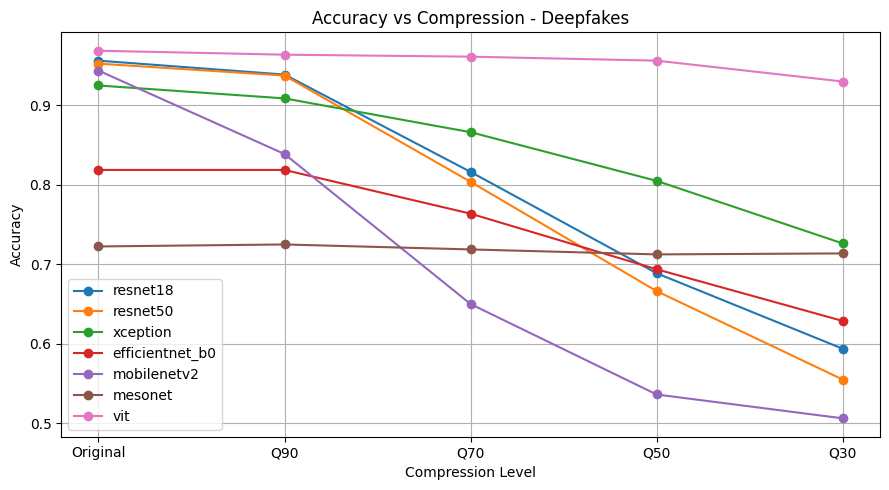

Saved: /teamspace/studios/this_studio/deepfake_project/reports/graph_figures/Deepfakes_accuracy_vs_compression.png


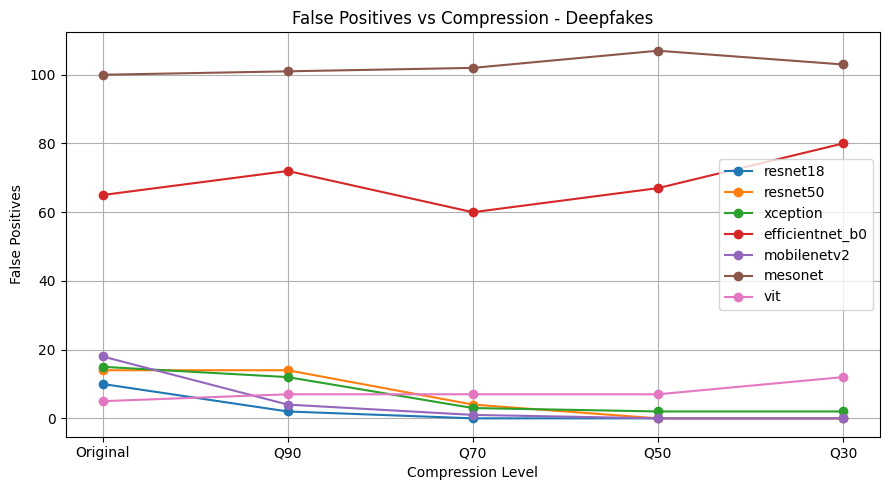

Saved: /teamspace/studios/this_studio/deepfake_project/reports/graph_figures/Deepfakes_false_positives_vs_compression.png


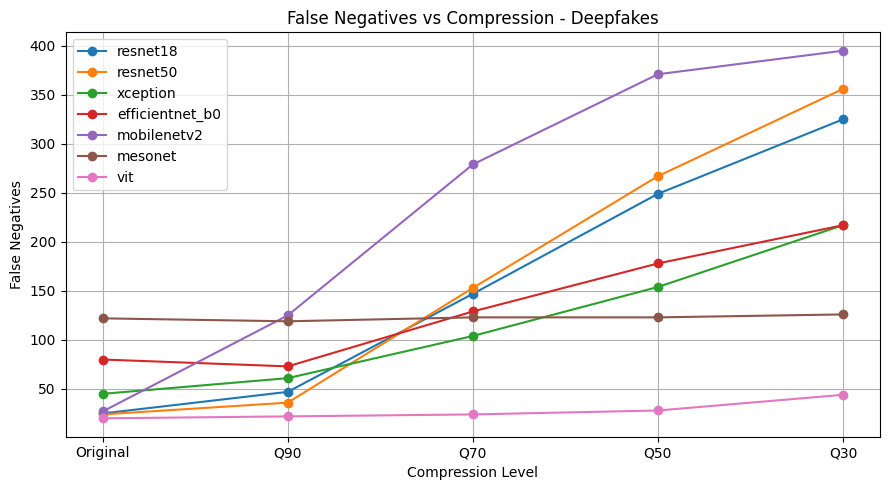

Saved: /teamspace/studios/this_studio/deepfake_project/reports/graph_figures/Deepfakes_false_negatives_vs_compression.png

Generating graphs for method: Face2Face


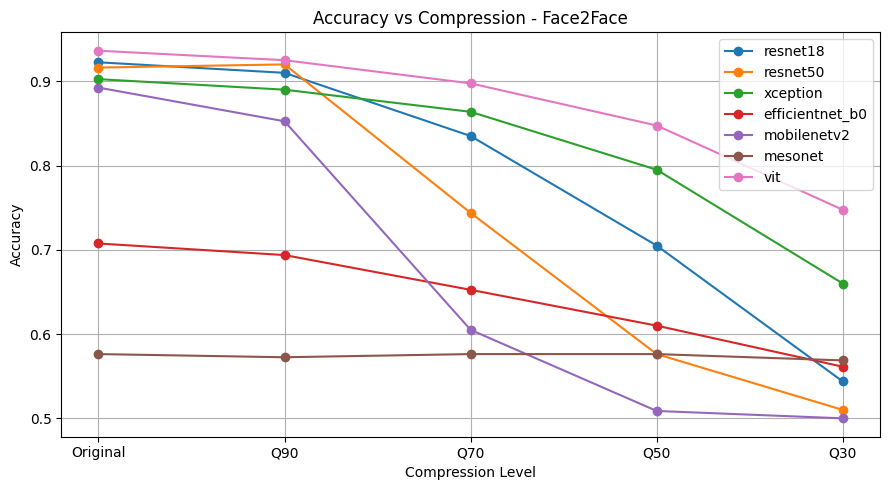

Saved: /teamspace/studios/this_studio/deepfake_project/reports/graph_figures/Face2Face_accuracy_vs_compression.png


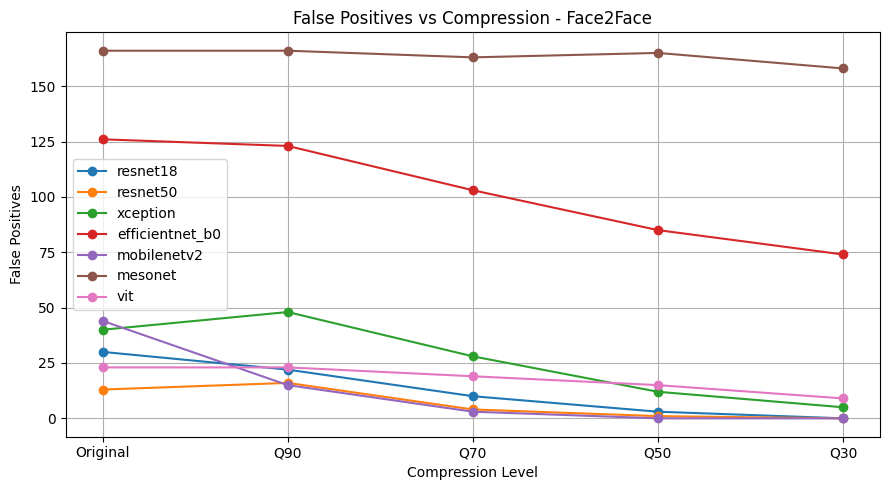

Saved: /teamspace/studios/this_studio/deepfake_project/reports/graph_figures/Face2Face_false_positives_vs_compression.png


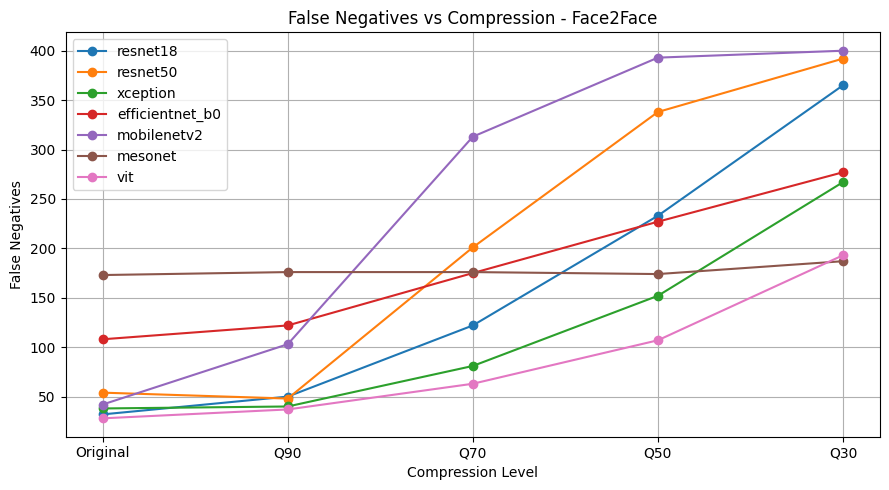

Saved: /teamspace/studios/this_studio/deepfake_project/reports/graph_figures/Face2Face_false_negatives_vs_compression.png

Generating graphs for method: FaceShifter


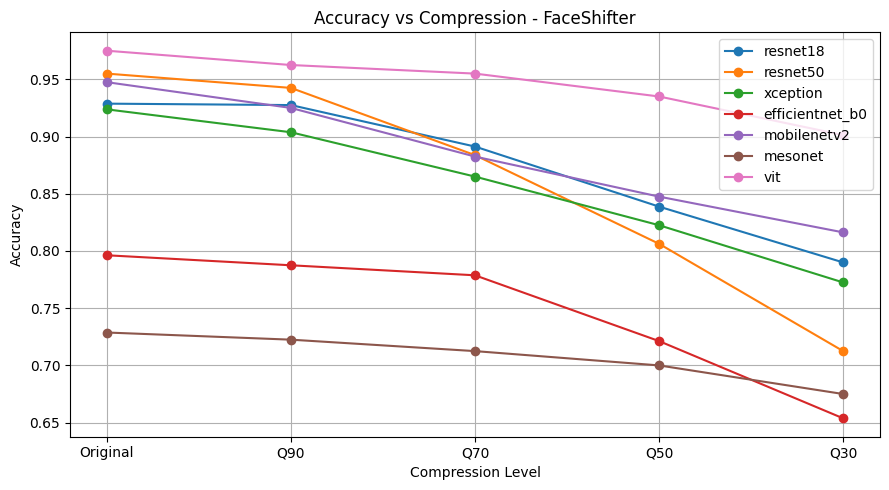

Saved: /teamspace/studios/this_studio/deepfake_project/reports/graph_figures/FaceShifter_accuracy_vs_compression.png


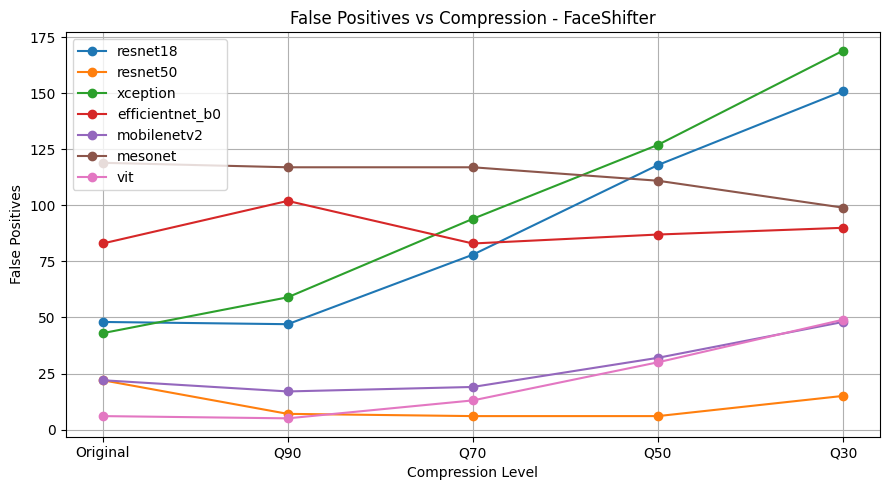

Saved: /teamspace/studios/this_studio/deepfake_project/reports/graph_figures/FaceShifter_false_positives_vs_compression.png


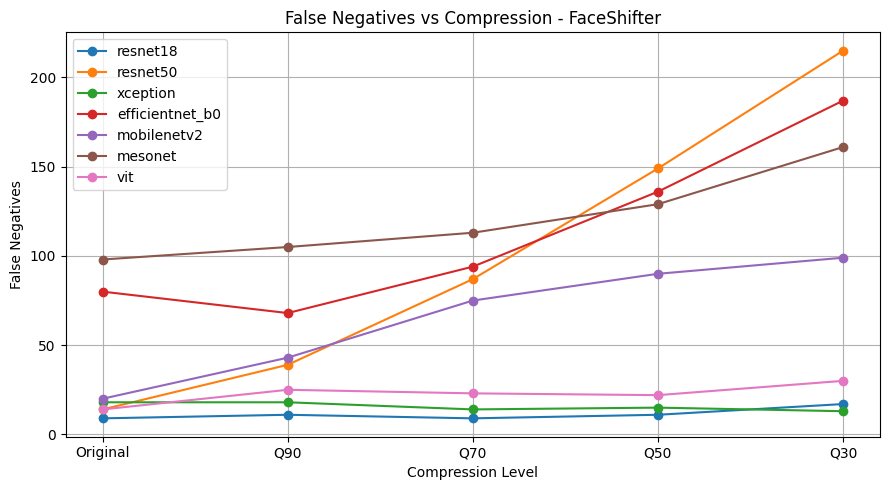

Saved: /teamspace/studios/this_studio/deepfake_project/reports/graph_figures/FaceShifter_false_negatives_vs_compression.png

Generating graphs for method: FaceSwap


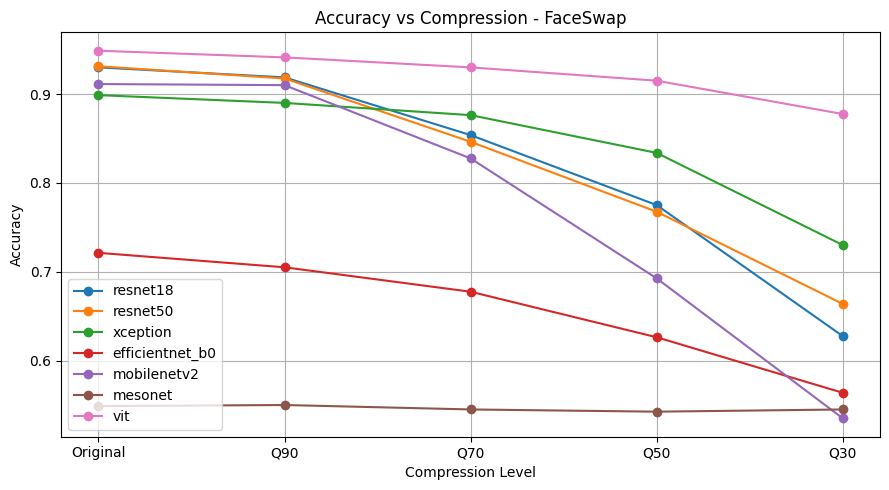

Saved: /teamspace/studios/this_studio/deepfake_project/reports/graph_figures/FaceSwap_accuracy_vs_compression.png


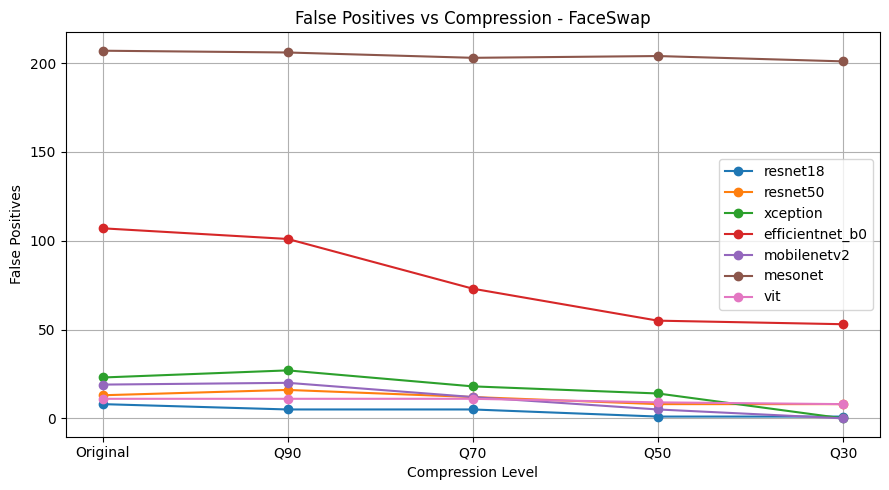

Saved: /teamspace/studios/this_studio/deepfake_project/reports/graph_figures/FaceSwap_false_positives_vs_compression.png


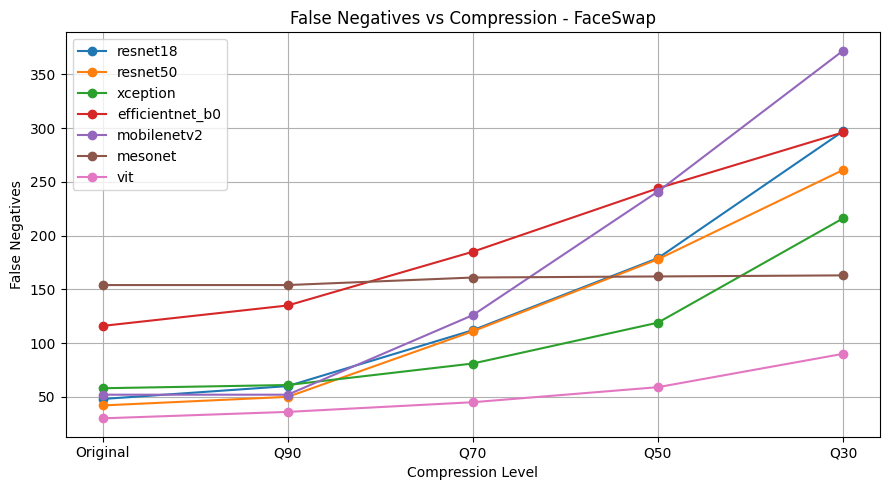

Saved: /teamspace/studios/this_studio/deepfake_project/reports/graph_figures/FaceSwap_false_negatives_vs_compression.png

Generating graphs for method: NeuralTextures


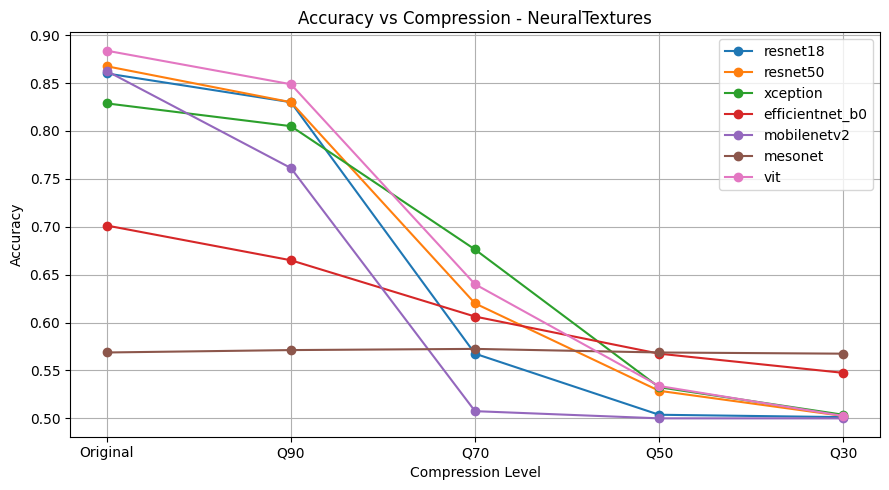

Saved: /teamspace/studios/this_studio/deepfake_project/reports/graph_figures/NeuralTextures_accuracy_vs_compression.png


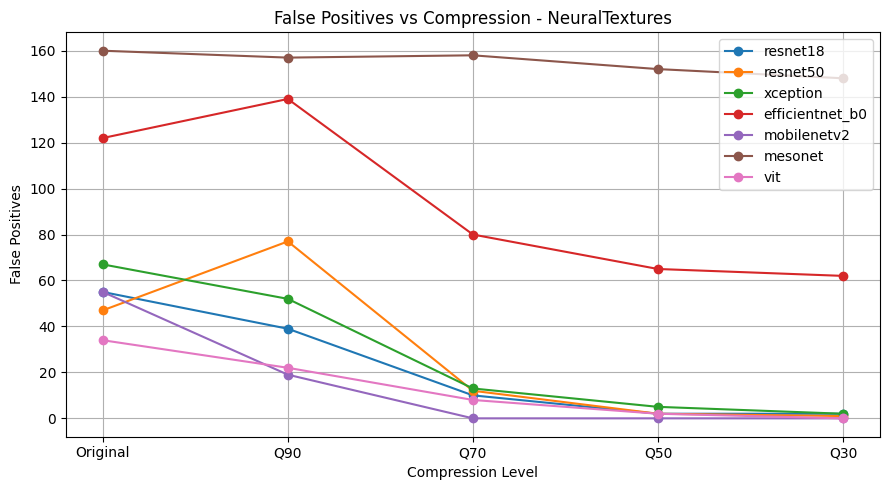

Saved: /teamspace/studios/this_studio/deepfake_project/reports/graph_figures/NeuralTextures_false_positives_vs_compression.png


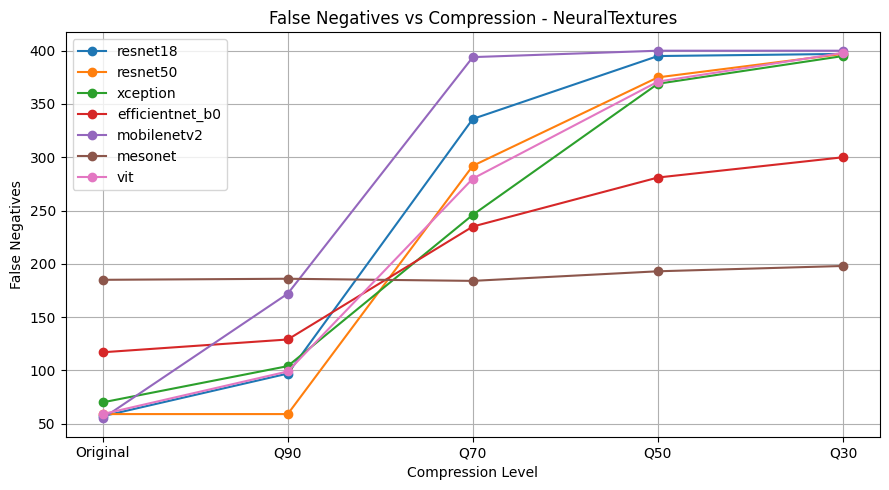

Saved: /teamspace/studios/this_studio/deepfake_project/reports/graph_figures/NeuralTextures_false_negatives_vs_compression.png


In [37]:
# =============================================================================
# --- CELL 35: Per-method accuracy/FP/FN graphs ---
# For each fake method: plot all models across compression levels
# =============================================================================
import json
import matplotlib.pyplot as plt
from pathlib import Path

GRAPH_OUTPUT_DIR = REPORTS_PATH / "graph_figures"
GRAPH_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MASTER_RESULTS_PATH = REPORTS_PATH / "multi_method_comparative_results.json"
with open(MASTER_RESULTS_PATH, "r") as f:
    final_results = json.load(f)

qualities      = ["original", "q90", "q70", "q50", "q30"]
quality_labels = ["Original", "Q90", "Q70", "Q50", "Q30"]


def save_method_comparison_graphs(method_name):
    """
    Plot all models for a selected fake method across compression levels.
    Saves Accuracy, False Positives, and False Negatives graphs.
    """
    # ── Accuracy graph ────────────────────────────────────────────────────────
    plt.figure(figsize=(9, 5))
    for model_name in MODEL_NAMES:
        values = [final_results[method_name][model_name][q]["accuracy"] for q in qualities]
        plt.plot(quality_labels, values, marker="o", label=model_name)
    plt.title(f"Accuracy vs Compression - {method_name}")
    plt.xlabel("Compression Level")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    acc_path = GRAPH_OUTPUT_DIR / f"{method_name}_accuracy_vs_compression.png"
    plt.savefig(acc_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()
    print("Saved:", acc_path)

    # ── False Positives graph ─────────────────────────────────────────────────
    plt.figure(figsize=(9, 5))
    for model_name in MODEL_NAMES:
        values = [final_results[method_name][model_name][q]["false_positives"] for q in qualities]
        plt.plot(quality_labels, values, marker="o", label=model_name)
    plt.title(f"False Positives vs Compression - {method_name}")
    plt.xlabel("Compression Level")
    plt.ylabel("False Positives")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    fp_path = GRAPH_OUTPUT_DIR / f"{method_name}_false_positives_vs_compression.png"
    plt.savefig(fp_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()
    print("Saved:", fp_path)

    # ── False Negatives graph ─────────────────────────────────────────────────
    plt.figure(figsize=(9, 5))
    for model_name in MODEL_NAMES:
        values = [final_results[method_name][model_name][q]["false_negatives"] for q in qualities]
        plt.plot(quality_labels, values, marker="o", label=model_name)
    plt.title(f"False Negatives vs Compression - {method_name}")
    plt.xlabel("Compression Level")
    plt.ylabel("False Negatives")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    fn_path = GRAPH_OUTPUT_DIR / f"{method_name}_false_negatives_vs_compression.png"
    plt.savefig(fn_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()
    print("Saved:", fn_path)


all_methods = ["Deepfakes", "Face2Face", "FaceShifter", "FaceSwap", "NeuralTextures"]
for method_name in all_methods:
    print("\n" + "=" * 80)
    print("Generating graphs for method:", method_name)
    print("=" * 80)
    save_method_comparison_graphs(method_name)



Generating graphs for model: resnet18


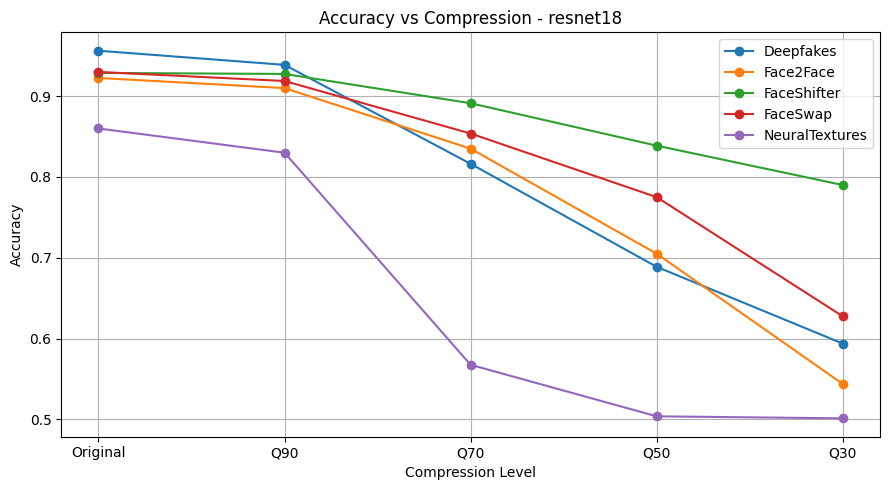

Saved: /teamspace/studios/this_studio/deepfake_project/reports/graph_figures/resnet18_accuracy_vs_compression.png


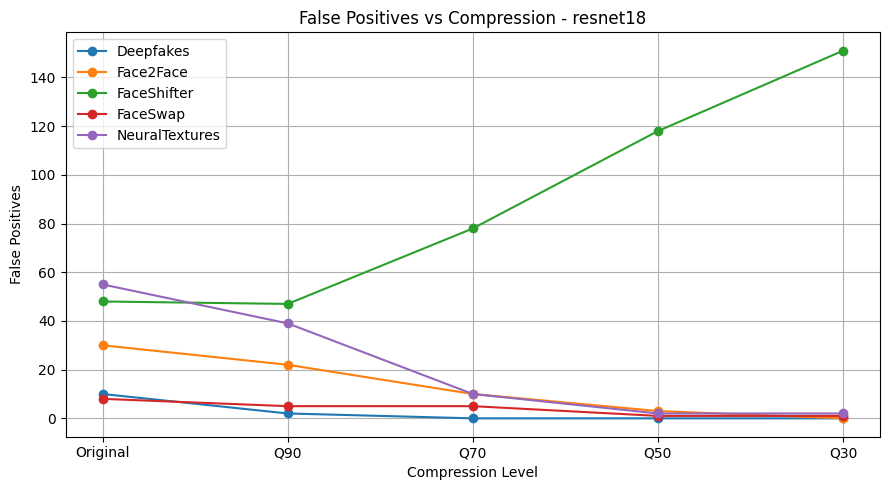

Saved: /teamspace/studios/this_studio/deepfake_project/reports/graph_figures/resnet18_false_positives_vs_compression.png


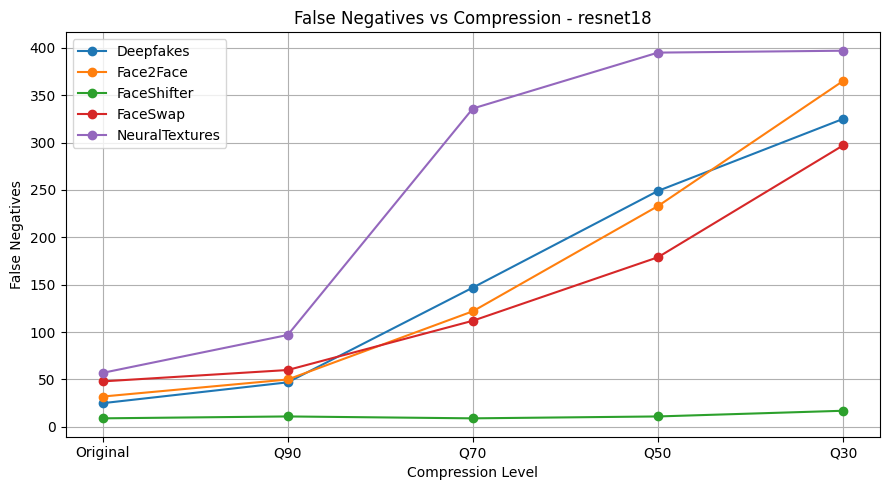

Saved: /teamspace/studios/this_studio/deepfake_project/reports/graph_figures/resnet18_false_negatives_vs_compression.png

Generating graphs for model: resnet50


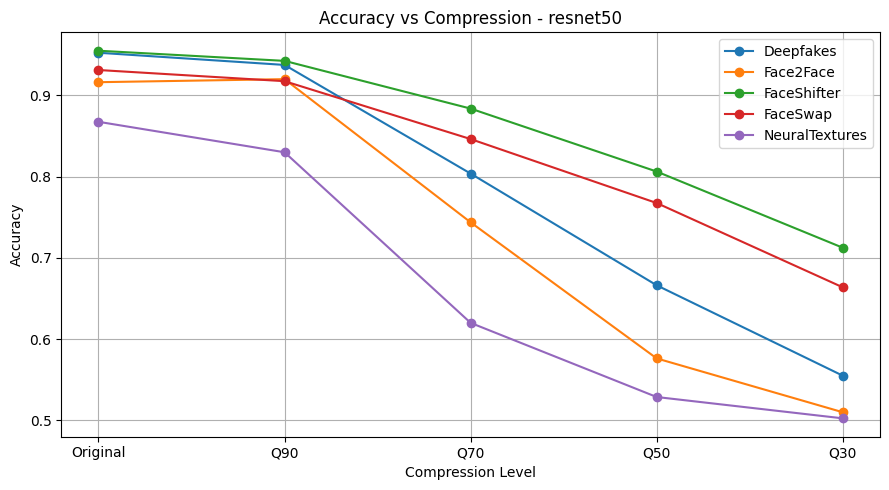

Saved: /teamspace/studios/this_studio/deepfake_project/reports/graph_figures/resnet50_accuracy_vs_compression.png


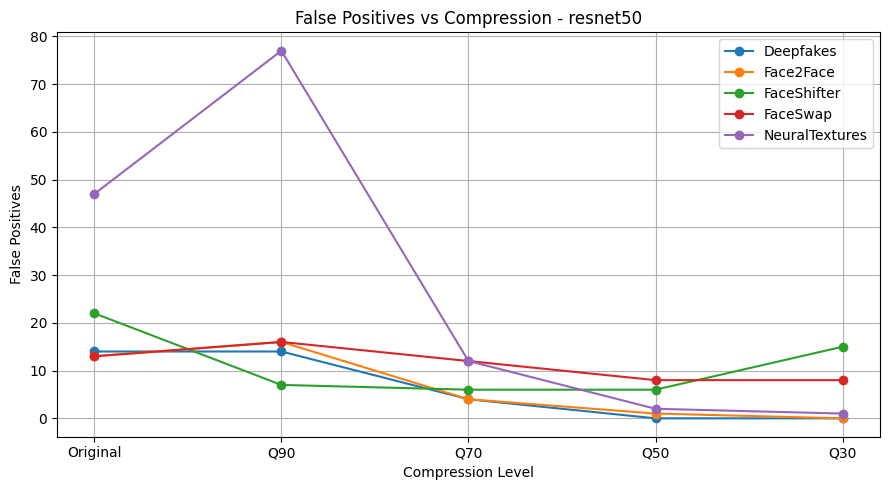

Saved: /teamspace/studios/this_studio/deepfake_project/reports/graph_figures/resnet50_false_positives_vs_compression.png


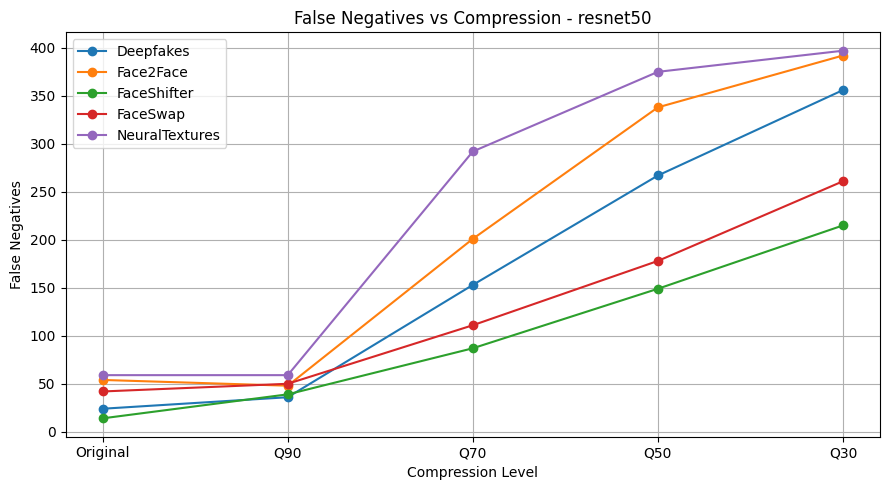

Saved: /teamspace/studios/this_studio/deepfake_project/reports/graph_figures/resnet50_false_negatives_vs_compression.png

Generating graphs for model: xception


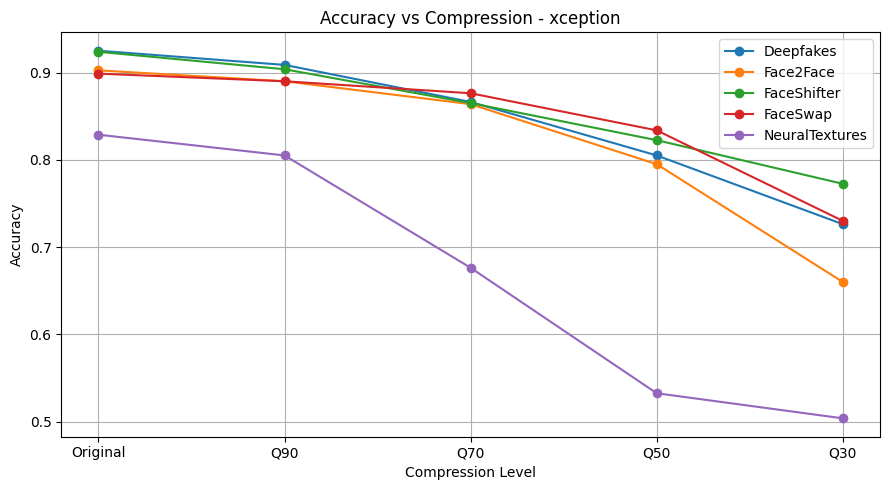

Saved: /teamspace/studios/this_studio/deepfake_project/reports/graph_figures/xception_accuracy_vs_compression.png


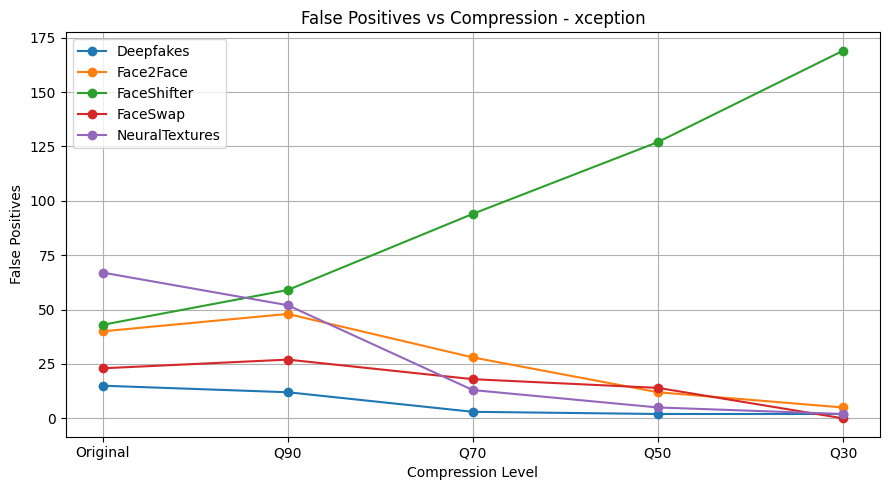

Saved: /teamspace/studios/this_studio/deepfake_project/reports/graph_figures/xception_false_positives_vs_compression.png


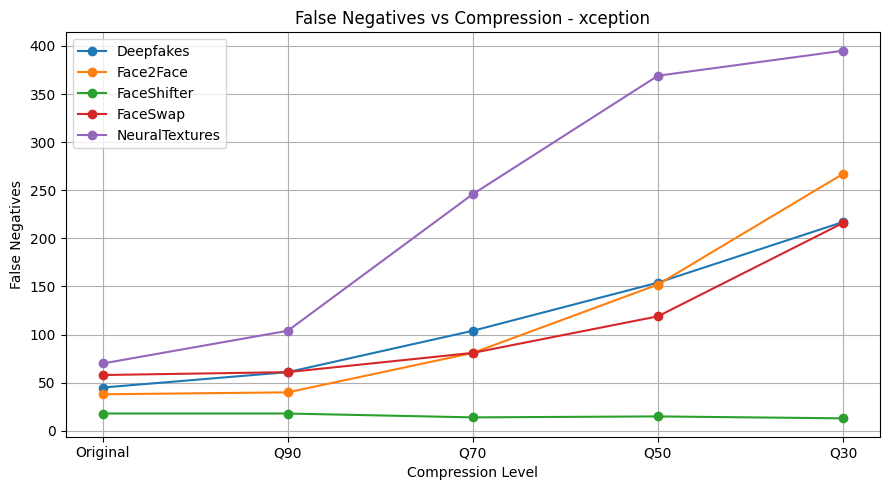

Saved: /teamspace/studios/this_studio/deepfake_project/reports/graph_figures/xception_false_negatives_vs_compression.png

Generating graphs for model: efficientnet_b0


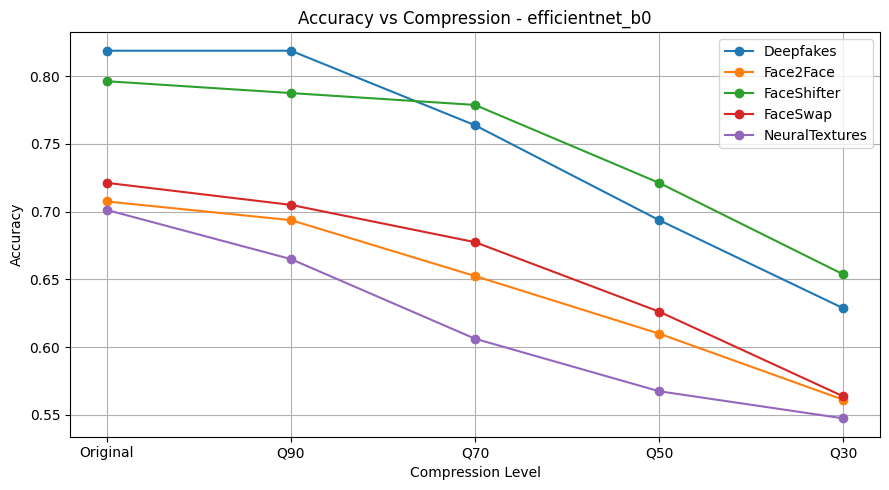

Saved: /teamspace/studios/this_studio/deepfake_project/reports/graph_figures/efficientnet_b0_accuracy_vs_compression.png


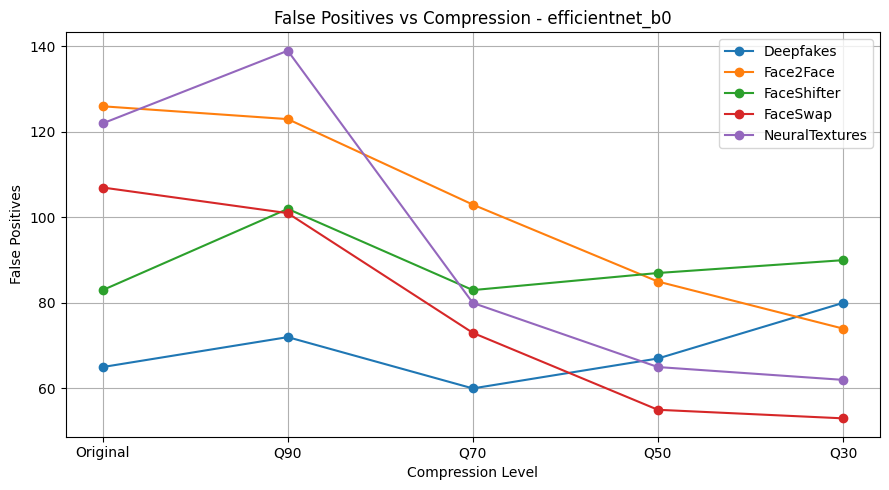

Saved: /teamspace/studios/this_studio/deepfake_project/reports/graph_figures/efficientnet_b0_false_positives_vs_compression.png


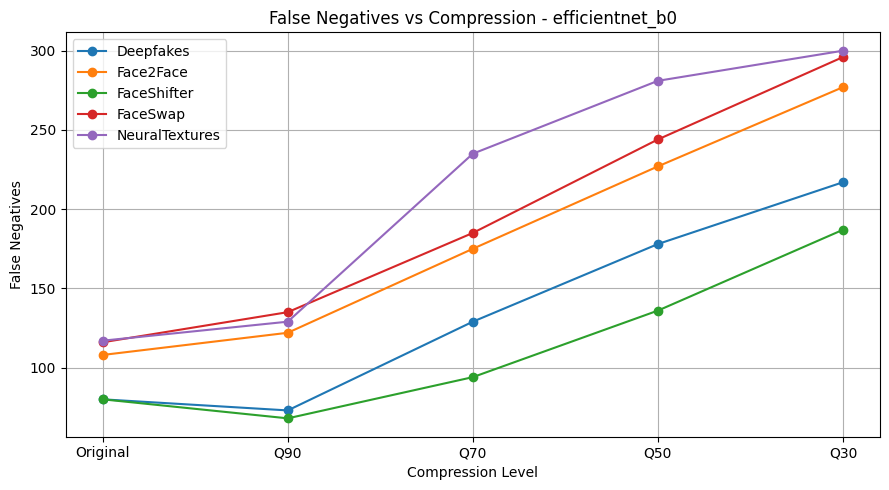

Saved: /teamspace/studios/this_studio/deepfake_project/reports/graph_figures/efficientnet_b0_false_negatives_vs_compression.png

Generating graphs for model: mobilenetv2


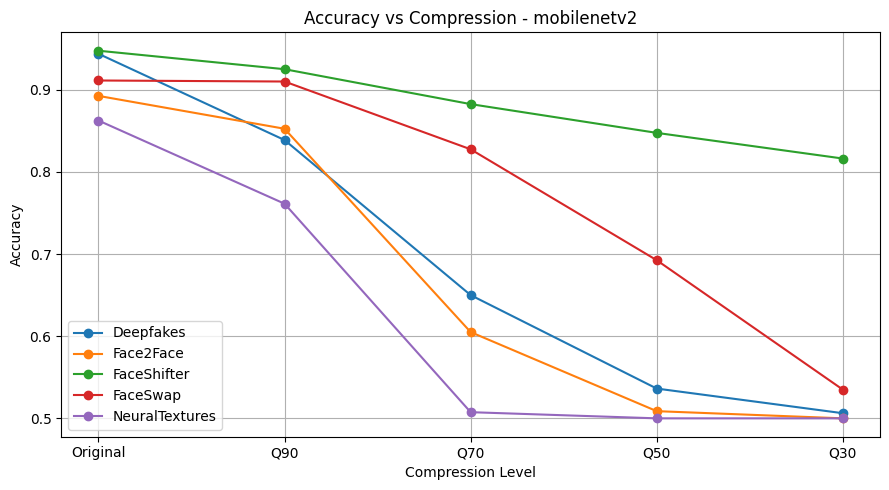

Saved: /teamspace/studios/this_studio/deepfake_project/reports/graph_figures/mobilenetv2_accuracy_vs_compression.png


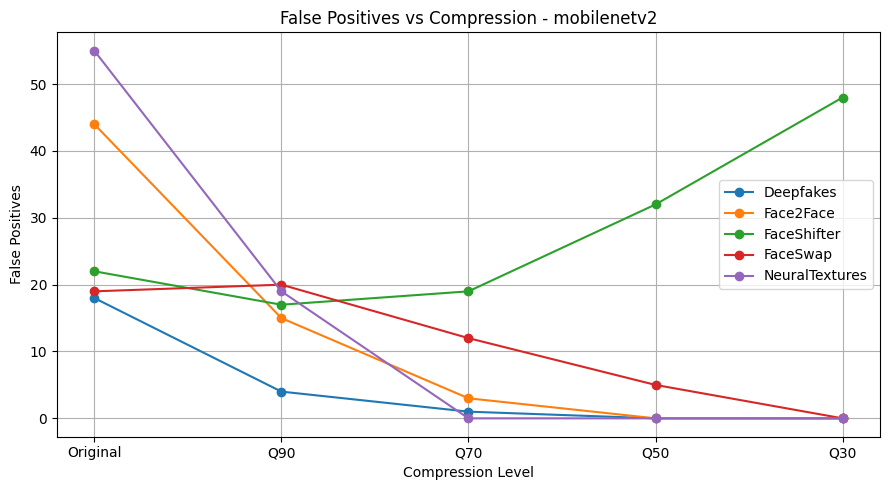

Saved: /teamspace/studios/this_studio/deepfake_project/reports/graph_figures/mobilenetv2_false_positives_vs_compression.png


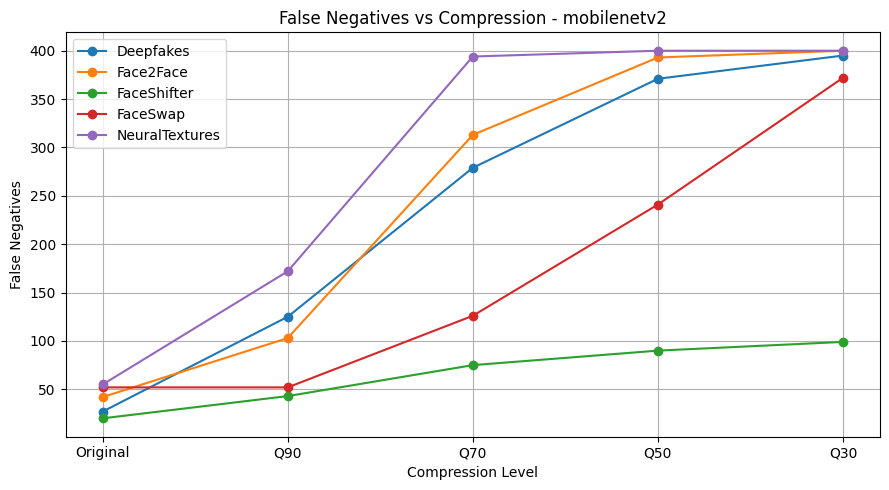

Saved: /teamspace/studios/this_studio/deepfake_project/reports/graph_figures/mobilenetv2_false_negatives_vs_compression.png

Generating graphs for model: mesonet


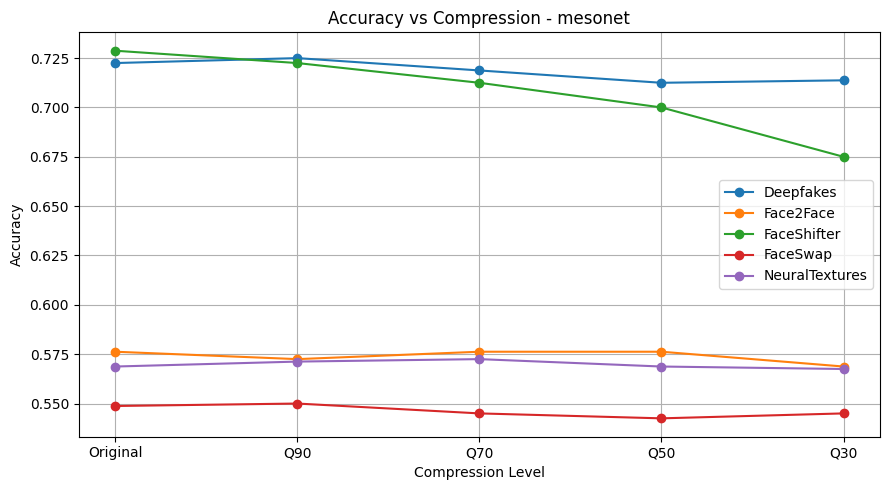

Saved: /teamspace/studios/this_studio/deepfake_project/reports/graph_figures/mesonet_accuracy_vs_compression.png


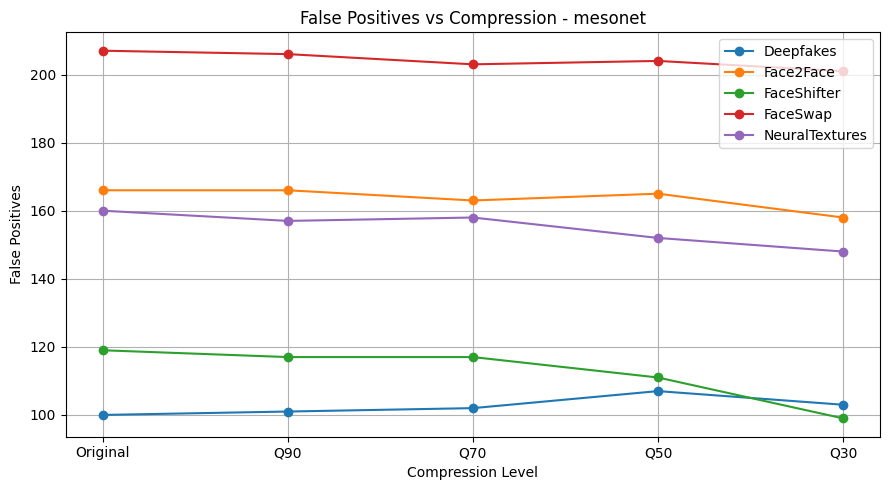

Saved: /teamspace/studios/this_studio/deepfake_project/reports/graph_figures/mesonet_false_positives_vs_compression.png


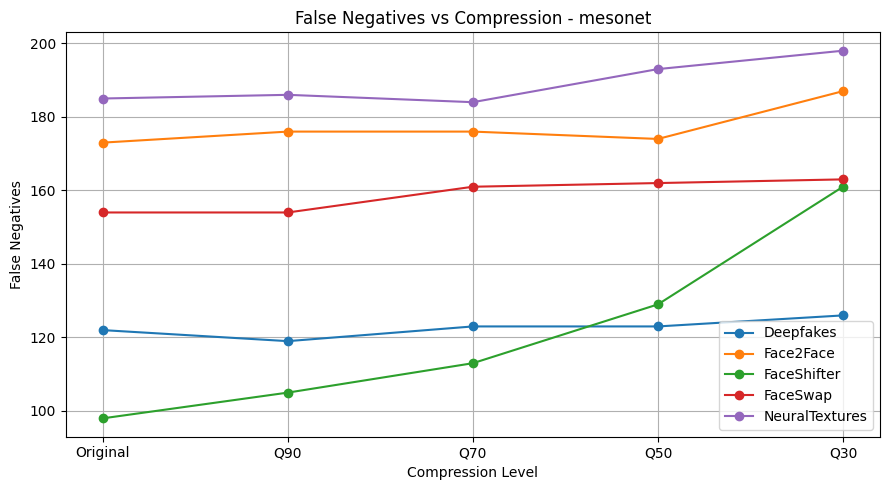

Saved: /teamspace/studios/this_studio/deepfake_project/reports/graph_figures/mesonet_false_negatives_vs_compression.png

Generating graphs for model: vit


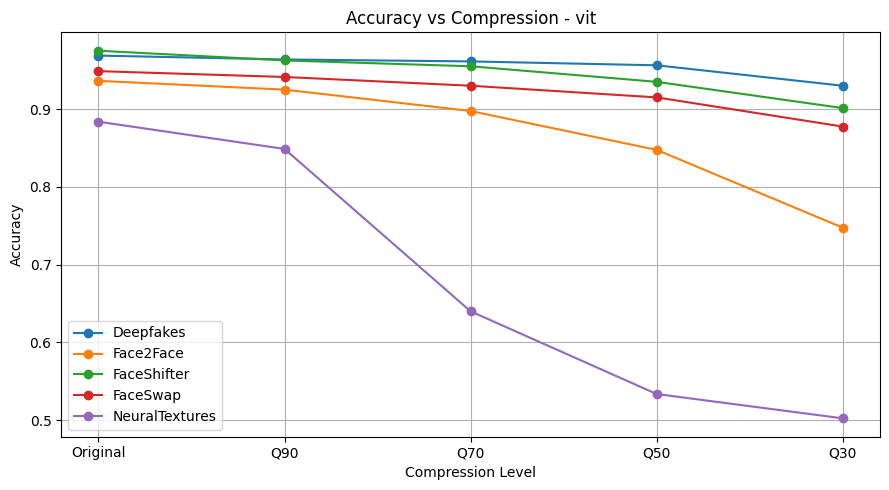

Saved: /teamspace/studios/this_studio/deepfake_project/reports/graph_figures/vit_accuracy_vs_compression.png


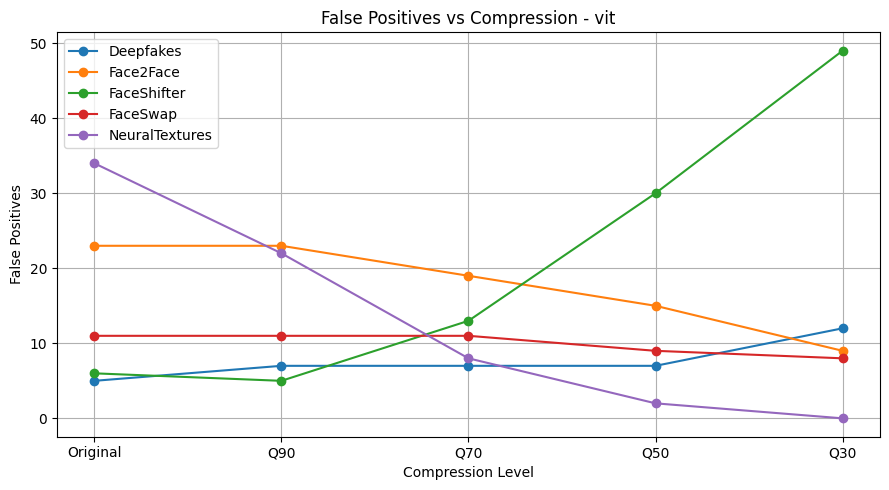

Saved: /teamspace/studios/this_studio/deepfake_project/reports/graph_figures/vit_false_positives_vs_compression.png


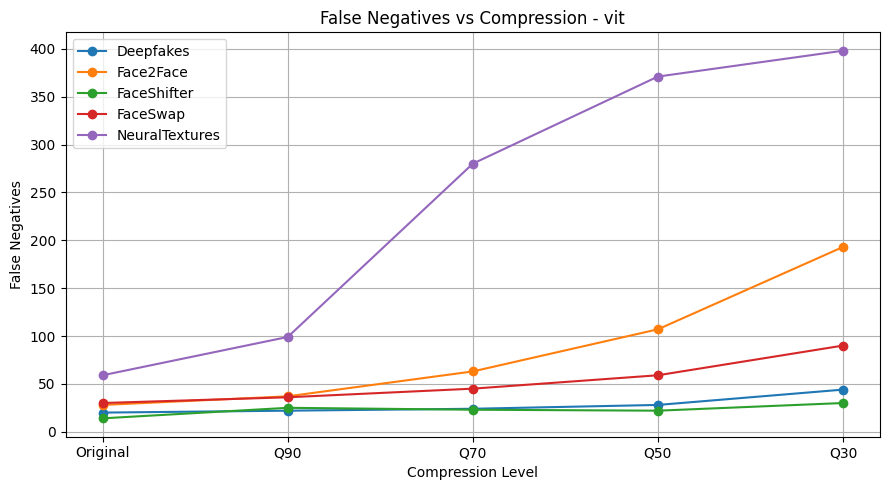

Saved: /teamspace/studios/this_studio/deepfake_project/reports/graph_figures/vit_false_negatives_vs_compression.png


In [38]:
# =============================================================================
# --- CELL 36: Per-model accuracy/FP/FN graphs ---
# For each model: plot all methods across compression levels
# =============================================================================
def save_model_comparison_graphs(model_name):
    """
    Plot all five manipulation methods for a selected model across compression levels.
    Saves Accuracy, False Positives, and False Negatives graphs.
    """
    method_names = ["Deepfakes", "Face2Face", "FaceShifter", "FaceSwap", "NeuralTextures"]

    # ── Accuracy graph ────────────────────────────────────────────────────────
    plt.figure(figsize=(9, 5))
    for method_name in method_names:
        values = [final_results[method_name][model_name][q]["accuracy"] for q in qualities]
        plt.plot(quality_labels, values, marker="o", label=method_name)
    plt.title(f"Accuracy vs Compression - {model_name}")
    plt.xlabel("Compression Level")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    acc_path = GRAPH_OUTPUT_DIR / f"{model_name}_accuracy_vs_compression.png"
    plt.savefig(acc_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()
    print("Saved:", acc_path)

    # ── False Positives graph ─────────────────────────────────────────────────
    plt.figure(figsize=(9, 5))
    for method_name in method_names:
        values = [final_results[method_name][model_name][q]["false_positives"] for q in qualities]
        plt.plot(quality_labels, values, marker="o", label=method_name)
    plt.title(f"False Positives vs Compression - {model_name}")
    plt.xlabel("Compression Level")
    plt.ylabel("False Positives")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    fp_path = GRAPH_OUTPUT_DIR / f"{model_name}_false_positives_vs_compression.png"
    plt.savefig(fp_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()
    print("Saved:", fp_path)

    # ── False Negatives graph ─────────────────────────────────────────────────
    plt.figure(figsize=(9, 5))
    for method_name in method_names:
        values = [final_results[method_name][model_name][q]["false_negatives"] for q in qualities]
        plt.plot(quality_labels, values, marker="o", label=method_name)
    plt.title(f"False Negatives vs Compression - {model_name}")
    plt.xlabel("Compression Level")
    plt.ylabel("False Negatives")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    fn_path = GRAPH_OUTPUT_DIR / f"{model_name}_false_negatives_vs_compression.png"
    plt.savefig(fn_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()
    print("Saved:", fn_path)


for model_name in MODEL_NAMES:
    print("\n" + "=" * 80)
    print("Generating graphs for model:", model_name)
    print("=" * 80)
    save_model_comparison_graphs(model_name)


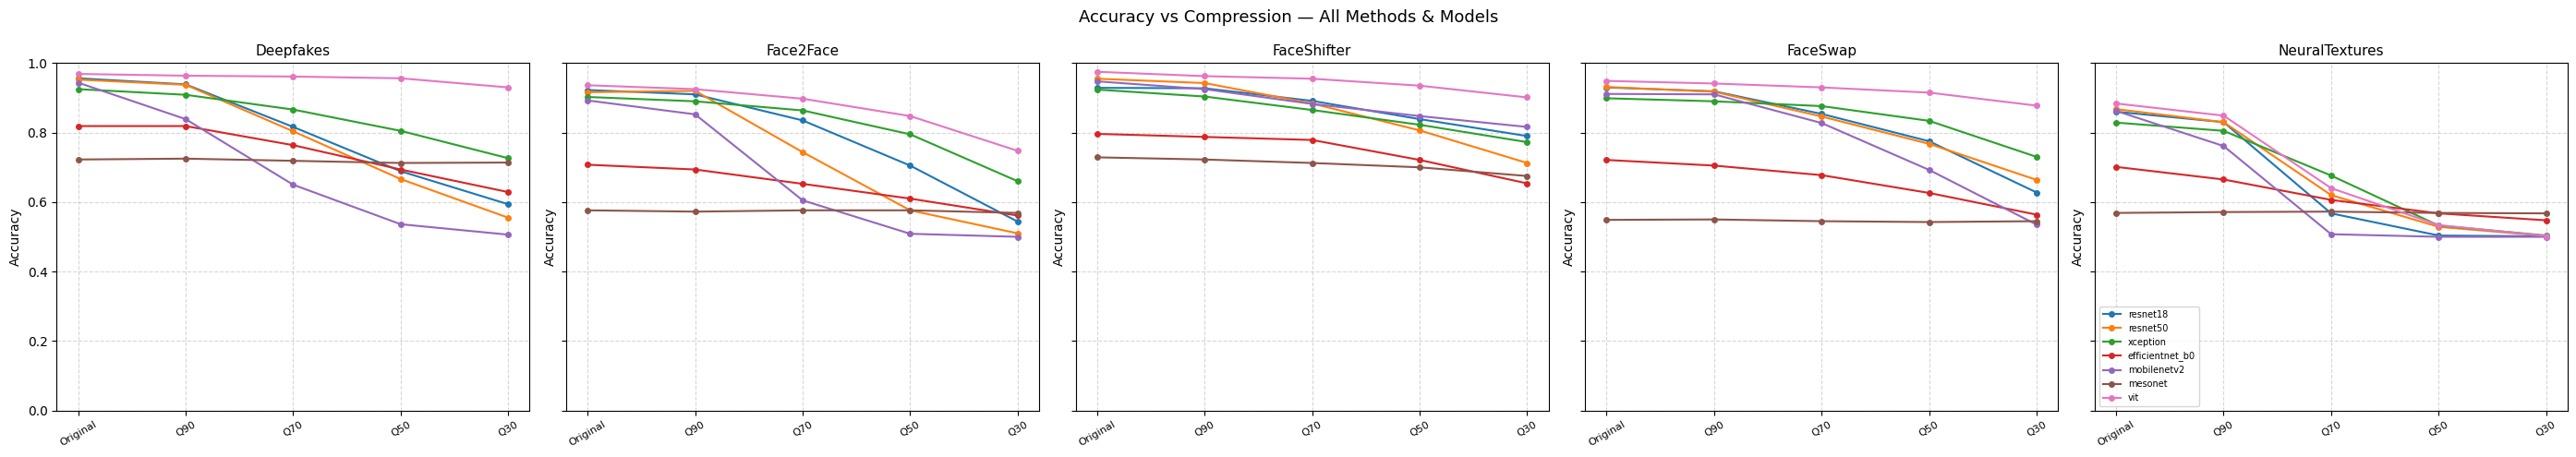

Saved: combined_all_accuracy_vs_compression.png


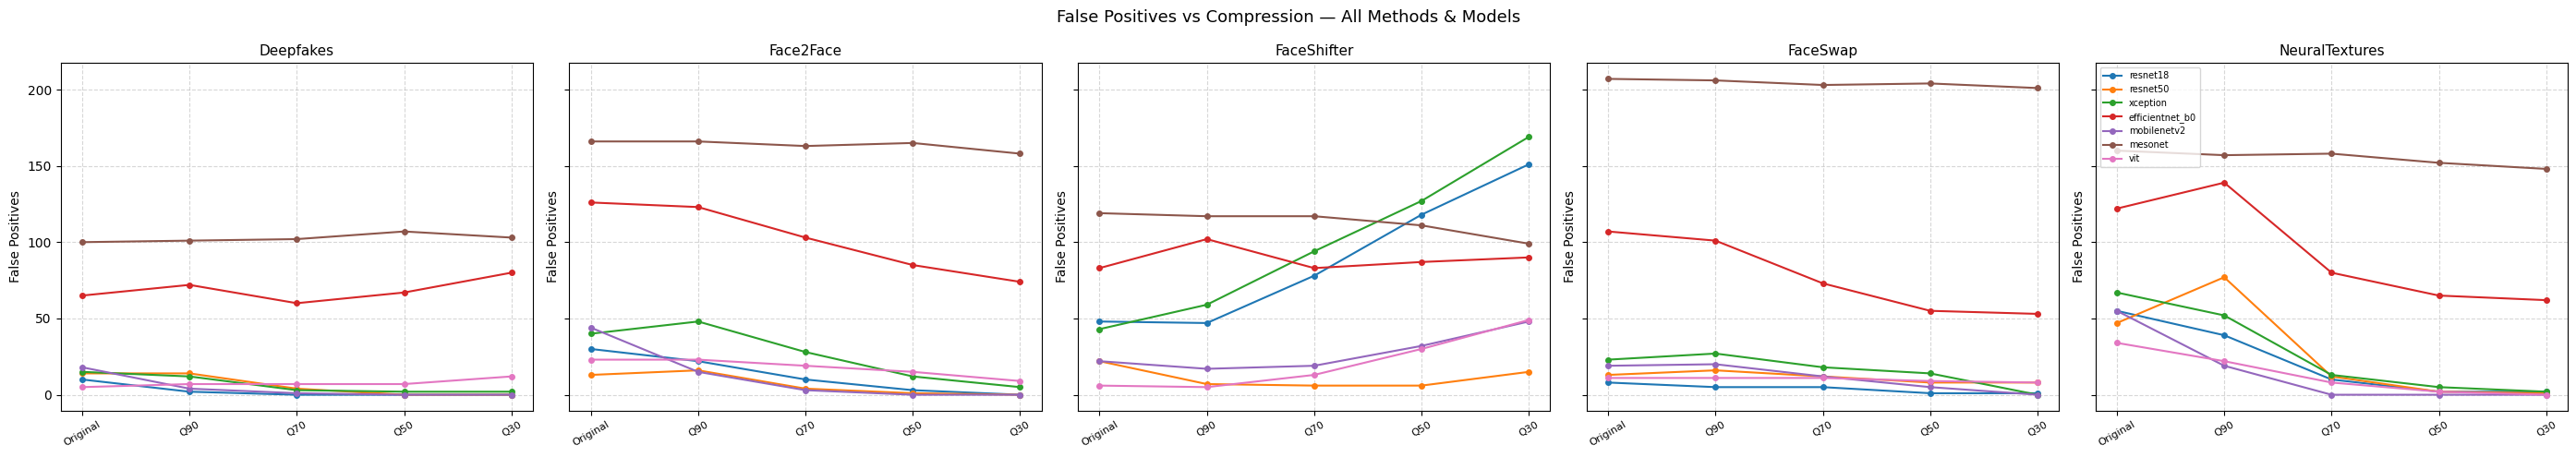

Saved: combined_all_false_positives_vs_compression.png


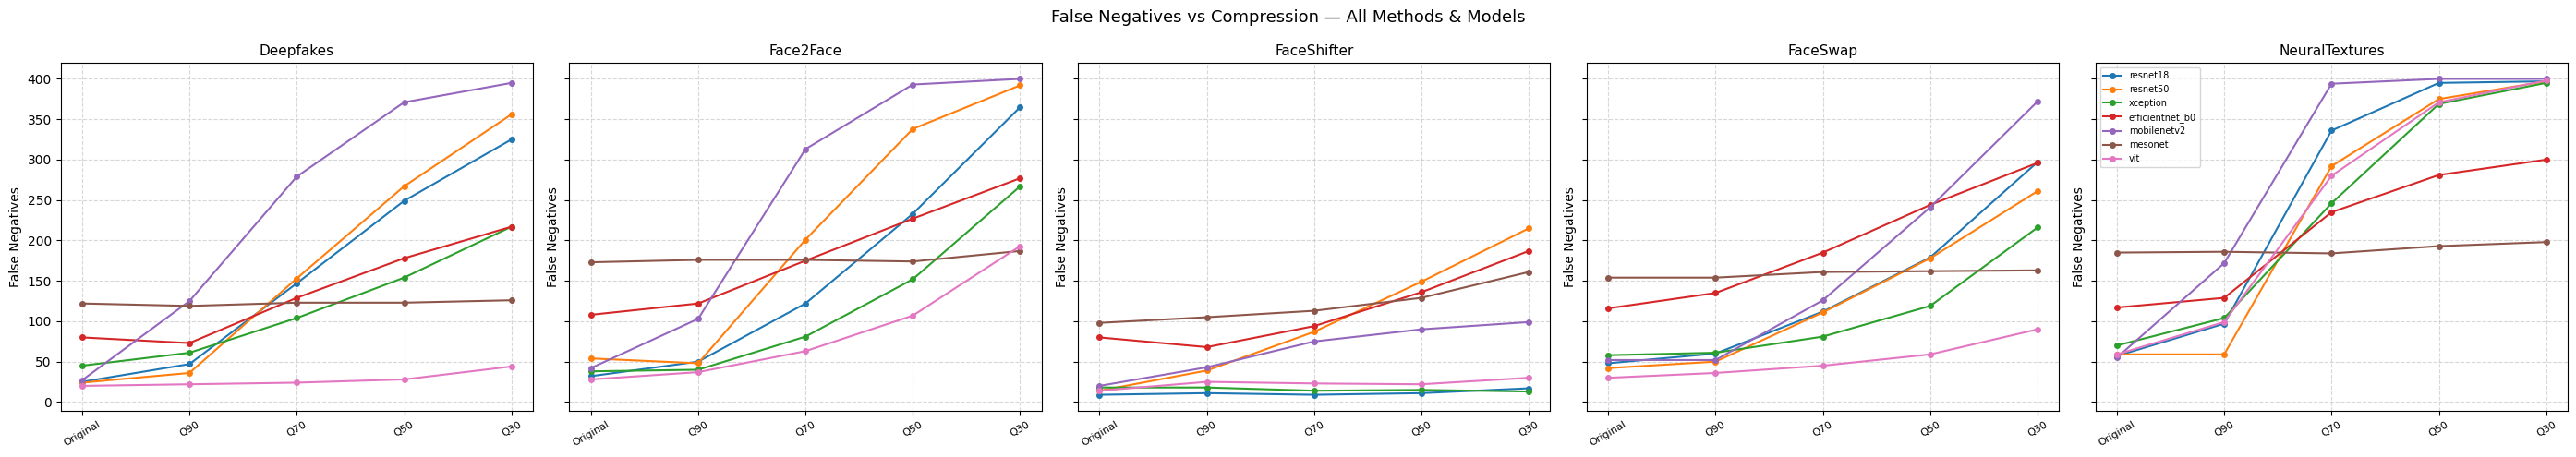

Saved: combined_all_false_negatives_vs_compression.png


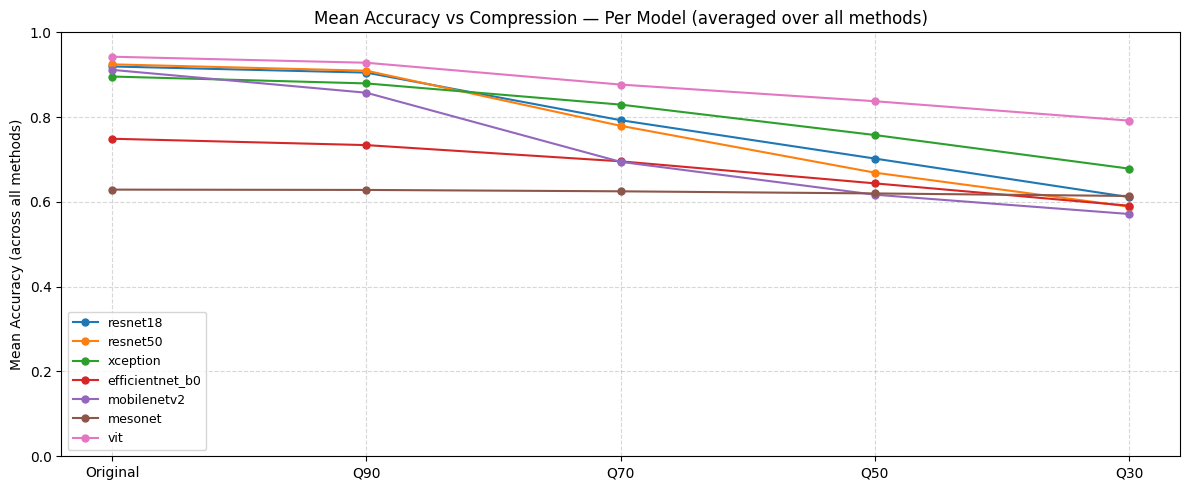

Saved: combined_mean_accuracy_per_model.png


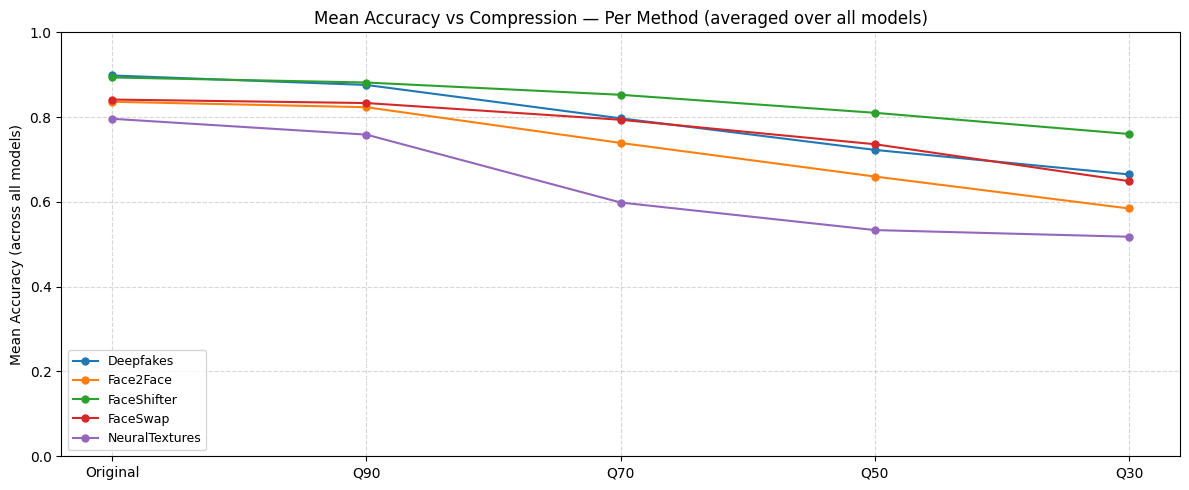

Saved: combined_mean_accuracy_per_method.png

Total graph files now: 42


In [39]:
# =============================================================================
# --- CELL 36B: Generate missing combined comparison graphs ---
# All methods vs all models on one graph per metric
# =============================================================================
import json
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

GRAPH_OUTPUT_DIR = REPORTS_PATH / "graph_figures"
GRAPH_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

FAKE_METHODS       = ["Deepfakes", "Face2Face", "FaceShifter", "FaceSwap", "NeuralTextures"]
MODEL_NAMES        = ["resnet18", "resnet50", "xception", "efficientnet_b0", "mobilenetv2", "mesonet", "vit"]
COMPRESSION_LEVELS = [90, 70, 50, 30]
x_labels           = ["Original", "Q90", "Q70", "Q50", "Q30"]
x_positions        = list(range(len(x_labels)))

# Load master results
with open(REPORTS_PATH / "multi_method_comparative_results.json", "r") as f:
    final_results = json.load(f)

def get_values(method, model, metric):
    keys = ["original"] + [f"q{q}" for q in COMPRESSION_LEVELS]
    return [final_results[method][model].get(k, {}).get(metric, None) for k in keys]

# ── Graph 1: All methods × all models — Accuracy ─────────────────────────────
fig, axes = plt.subplots(1, len(FAKE_METHODS), figsize=(28, 5), sharey=True)
for ax, method in zip(axes, FAKE_METHODS):
    for model in MODEL_NAMES:
        vals = get_values(method, model, "accuracy")
        ax.plot(x_positions, vals, marker="o", markersize=4, label=model)
    ax.set_title(method, fontsize=11)
    ax.set_xticks(x_positions)
    ax.set_xticklabels(x_labels, rotation=30, fontsize=8)
    ax.set_ylim(0, 1)
    ax.set_ylabel("Accuracy")
    ax.grid(True, linestyle="--", alpha=0.5)
axes[-1].legend(loc="lower left", fontsize=7)
fig.suptitle("Accuracy vs Compression — All Methods & Models", fontsize=13)
plt.tight_layout()
out = GRAPH_OUTPUT_DIR / "combined_all_accuracy_vs_compression.png"
plt.savefig(out, dpi=300, bbox_inches="tight")
plt.show(); plt.close()
print("Saved:", out.name)

# ── Graph 2: All methods × all models — False Positives ──────────────────────
fig, axes = plt.subplots(1, len(FAKE_METHODS), figsize=(28, 5), sharey=True)
for ax, method in zip(axes, FAKE_METHODS):
    for model in MODEL_NAMES:
        vals = get_values(method, model, "false_positives")
        ax.plot(x_positions, vals, marker="o", markersize=4, label=model)
    ax.set_title(method, fontsize=11)
    ax.set_xticks(x_positions)
    ax.set_xticklabels(x_labels, rotation=30, fontsize=8)
    ax.set_ylabel("False Positives")
    ax.grid(True, linestyle="--", alpha=0.5)
axes[-1].legend(loc="upper left", fontsize=7)
fig.suptitle("False Positives vs Compression — All Methods & Models", fontsize=13)
plt.tight_layout()
out = GRAPH_OUTPUT_DIR / "combined_all_false_positives_vs_compression.png"
plt.savefig(out, dpi=300, bbox_inches="tight")
plt.show(); plt.close()
print("Saved:", out.name)

# ── Graph 3: All methods × all models — False Negatives ──────────────────────
fig, axes = plt.subplots(1, len(FAKE_METHODS), figsize=(28, 5), sharey=True)
for ax, method in zip(axes, FAKE_METHODS):
    for model in MODEL_NAMES:
        vals = get_values(method, model, "false_negatives")
        ax.plot(x_positions, vals, marker="o", markersize=4, label=model)
    ax.set_title(method, fontsize=11)
    ax.set_xticks(x_positions)
    ax.set_xticklabels(x_labels, rotation=30, fontsize=8)
    ax.set_ylabel("False Negatives")
    ax.grid(True, linestyle="--", alpha=0.5)
axes[-1].legend(loc="upper left", fontsize=7)
fig.suptitle("False Negatives vs Compression — All Methods & Models", fontsize=13)
plt.tight_layout()
out = GRAPH_OUTPUT_DIR / "combined_all_false_negatives_vs_compression.png"
plt.savefig(out, dpi=300, bbox_inches="tight")
plt.show(); plt.close()
print("Saved:", out.name)

# ── Graph 4: Mean accuracy across all methods per model ───────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
for model in MODEL_NAMES:
    mean_vals = []
    for xi, key in enumerate(["original"] + [f"q{q}" for q in COMPRESSION_LEVELS]):
        accs = [final_results[m][model].get(key, {}).get("accuracy", None)
                for m in FAKE_METHODS]
        accs = [v for v in accs if v is not None]
        mean_vals.append(np.mean(accs) if accs else None)
    ax.plot(x_positions, mean_vals, marker="o", markersize=5, label=model)
ax.set_xticks(x_positions)
ax.set_xticklabels(x_labels)
ax.set_ylim(0, 1)
ax.set_ylabel("Mean Accuracy (across all methods)")
ax.set_title("Mean Accuracy vs Compression — Per Model (averaged over all methods)")
ax.legend(fontsize=9)
ax.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
out = GRAPH_OUTPUT_DIR / "combined_mean_accuracy_per_model.png"
plt.savefig(out, dpi=300, bbox_inches="tight")
plt.show(); plt.close()
print("Saved:", out.name)

# ── Graph 5: Mean accuracy across all models per method ───────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
for method in FAKE_METHODS:
    mean_vals = []
    for xi, key in enumerate(["original"] + [f"q{q}" for q in COMPRESSION_LEVELS]):
        accs = [final_results[method][m].get(key, {}).get("accuracy", None)
                for m in MODEL_NAMES]
        accs = [v for v in accs if v is not None]
        mean_vals.append(np.mean(accs) if accs else None)
    ax.plot(x_positions, mean_vals, marker="o", markersize=5, label=method)
ax.set_xticks(x_positions)
ax.set_xticklabels(x_labels)
ax.set_ylim(0, 1)
ax.set_ylabel("Mean Accuracy (across all models)")
ax.set_title("Mean Accuracy vs Compression — Per Method (averaged over all models)")
ax.legend(fontsize=9)
ax.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
out = GRAPH_OUTPUT_DIR / "combined_mean_accuracy_per_method.png"
plt.savefig(out, dpi=300, bbox_inches="tight")
plt.show(); plt.close()
print("Saved:", out.name)

# ── Final count ───────────────────────────────────────────────────────────────
all_graphs = sorted(GRAPH_OUTPUT_DIR.glob("*.png"))
print(f"\nTotal graph files now: {len(all_graphs)}")

In [40]:
# =============================================================================
# --- CELL 37: Verify all graph files ---
# =============================================================================
graph_files = sorted(GRAPH_OUTPUT_DIR.glob("*.png"))
print("Graph output directory:", GRAPH_OUTPUT_DIR)
print("Total graph PNG files found:", len(graph_files))
print()
for p in graph_files:
    print(p.name)


Graph output directory: /teamspace/studios/this_studio/deepfake_project/reports/graph_figures
Total graph PNG files found: 42

Deepfakes_accuracy_vs_compression.png
Deepfakes_false_negatives_vs_compression.png
Deepfakes_false_positives_vs_compression.png
Face2Face_accuracy_vs_compression.png
Face2Face_false_negatives_vs_compression.png
Face2Face_false_positives_vs_compression.png
FaceShifter_accuracy_vs_compression.png
FaceShifter_false_negatives_vs_compression.png
FaceShifter_false_positives_vs_compression.png
FaceSwap_accuracy_vs_compression.png
FaceSwap_false_negatives_vs_compression.png
FaceSwap_false_positives_vs_compression.png
NeuralTextures_accuracy_vs_compression.png
NeuralTextures_false_negatives_vs_compression.png
NeuralTextures_false_positives_vs_compression.png
combined_all_accuracy_vs_compression.png
combined_all_false_negatives_vs_compression.png
combined_all_false_positives_vs_compression.png
combined_mean_accuracy_per_method.png
combined_mean_accuracy_per_model.png
eff

In [41]:
# =============================================================================
# --- CELL 38: Build and save metric tables to CSV + Excel ---
# =============================================================================
import json
import pandas as pd
from pathlib import Path

TABLE_OUTPUT_DIR = REPORTS_PATH / "tables"
TABLE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MASTER_RESULTS_PATH = REPORTS_PATH / "multi_method_comparative_results.json"
with open(MASTER_RESULTS_PATH, "r") as f:
    final_results = json.load(f)

methods             = ["Deepfakes", "Face2Face", "FaceShifter", "FaceSwap", "NeuralTextures"]
qualities           = ["original", "q90", "q70", "q50", "q30"]
quality_labels_dict = {
    "original": "Original",
    "q90": "Q90", "q70": "Q70", "q50": "Q50", "q30": "Q30"
}

def build_metric_table(metric_name):
    """
    Build a metric table across all methods and compression levels.
    Rows = method + compression level, columns = model names.
    """
    rows = []
    for method_name in methods:
        for q in qualities:
            row = {
                "Method":      method_name,
                "Compression": quality_labels_dict[q]
            }
            for model_name in MODEL_NAMES:
                value           = final_results[method_name][model_name][q][metric_name]
                row[model_name] = value
            rows.append(row)
    return pd.DataFrame(rows)

# ── Build all tables ──────────────────────────────────────────────────────────
accuracy_table = build_metric_table("accuracy")
f1_table       = build_metric_table("f1")
roc_auc_table  = build_metric_table("roc_auc")
fp_table       = build_metric_table("false_positives")
fn_table       = build_metric_table("false_negatives")

# ── Save individual CSV files ─────────────────────────────────────────────────
accuracy_table.to_csv(TABLE_OUTPUT_DIR / "accuracy_table.csv",       index=False)
f1_table.to_csv(TABLE_OUTPUT_DIR / "f1_table.csv",                   index=False)
roc_auc_table.to_csv(TABLE_OUTPUT_DIR / "roc_auc_table.csv",         index=False)
fp_table.to_csv(TABLE_OUTPUT_DIR / "false_positives_table.csv",      index=False)
fn_table.to_csv(TABLE_OUTPUT_DIR / "false_negatives_table.csv",      index=False)

# ── Save all into a single Excel workbook with separate sheets ────────────────
excel_path = TABLE_OUTPUT_DIR / "all_metric_tables.xlsx"
with pd.ExcelWriter(excel_path) as writer:
    accuracy_table.to_excel(writer, sheet_name="Accuracy",        index=False)
    f1_table.to_excel(writer,       sheet_name="F1",              index=False)
    roc_auc_table.to_excel(writer,  sheet_name="ROC_AUC",         index=False)
    fp_table.to_excel(writer,       sheet_name="False_Positives", index=False)
    fn_table.to_excel(writer,       sheet_name="False_Negatives", index=False)

print("All tables saved successfully in:", TABLE_OUTPUT_DIR)

# =============================================================================
# --- VERIFICATION ---
# =============================================================================
print("\n" + "="*60)
print("VERIFICATION")
print("="*60)

# ── 1. File count ─────────────────────────────────────────────────────────────
csv_files   = sorted(TABLE_OUTPUT_DIR.glob("*.csv"))
xlsx_files  = sorted(TABLE_OUTPUT_DIR.glob("*.xlsx"))
print(f"\nCSV  files saved : {len(csv_files)}  (expected: 5)")
print(f"XLSX files saved : {len(xlsx_files)} (expected: 1)")
for f in csv_files:
    print(f"  ✅ {f.name}")
for f in xlsx_files:
    print(f"  ✅ {f.name}")

# ── 2. Table shapes ───────────────────────────────────────────────────────────
print("\n── Table shapes (expected 25 rows × 9 columns each) ──")
expected_rows = len(methods) * len(qualities)   # 5 × 5 = 25
expected_cols = 2 + len(MODEL_NAMES)            # Method + Compression + 7 models = 9
all_ok = True
for name, df in [
    ("accuracy",        accuracy_table),
    ("f1",              f1_table),
    ("roc_auc",         roc_auc_table),
    ("false_positives", fp_table),
    ("false_negatives", fn_table),
]:
    shape_ok = (df.shape == (expected_rows, expected_cols))
    status   = "✅" if shape_ok else "❌"
    print(f"  {status} {name:20s}: shape = {df.shape}  expected = ({expected_rows}, {expected_cols})")
    if not shape_ok:
        all_ok = False

# ── 3. Null check ─────────────────────────────────────────────────────────────
print("\n── Null value check ──")
for name, df in [
    ("accuracy",        accuracy_table),
    ("f1",              f1_table),
    ("roc_auc",         roc_auc_table),
    ("false_positives", fp_table),
    ("false_negatives", fn_table),
]:
    nulls  = df.isnull().sum().sum()
    status = "✅" if nulls == 0 else f"⚠️  {nulls} nulls found"
    print(f"  {status} {name}")

# ── 4. Value range check ──────────────────────────────────────────────────────
print("\n── Value range check ──")
model_cols = MODEL_NAMES
for name, df, lo, hi in [
    ("accuracy",  accuracy_table,  0.0, 1.0),
    ("f1",        f1_table,        0.0, 1.0),
    ("roc_auc",   roc_auc_table,   0.0, 1.0),
]:
    vals      = df[model_cols].values.astype(float)
    range_ok  = (vals.min() >= lo) and (vals.max() <= hi)
    status    = "✅" if range_ok else "❌"
    print(f"  {status} {name:10s}: min={vals.min():.4f}  max={vals.max():.4f}  (expected [{lo}, {hi}])")

for name, df in [("false_positives", fp_table), ("false_negatives", fn_table)]:
    vals     = df[model_cols].values.astype(float)
    range_ok = vals.min() >= 0
    status   = "✅" if range_ok else "❌"
    print(f"  {status} {name:20s}: min={vals.min():.0f}  max={vals.max():.0f}  (expected >= 0)")

# ── 5. Sample preview ─────────────────────────────────────────────────────────
print("\n── Accuracy table preview (first 5 rows) ──")
print(accuracy_table.head().to_string(index=False))

print("\n── Best accuracy per method (Original, best model) ──")
orig_acc = accuracy_table[accuracy_table["Compression"] == "Original"]
for _, row in orig_acc.iterrows():
    best_model = max(MODEL_NAMES, key=lambda m: row[m])
    print(f"  {row['Method']:20s}: best model = {best_model:20s}  accuracy = {row[best_model]:.4f}")

print("\n── Accuracy drop Original → Q30 (mean across all models) ──")
for method in methods:
    orig = accuracy_table[(accuracy_table["Method"] == method) &
                          (accuracy_table["Compression"] == "Original")][MODEL_NAMES].values.mean()
    q30  = accuracy_table[(accuracy_table["Method"] == method) &
                          (accuracy_table["Compression"] == "Q30")][MODEL_NAMES].values.mean()
    print(f"  {method:20s}: Original={orig:.4f}  Q30={q30:.4f}  Drop={orig - q30:.4f}")

print("\n" + "="*60)
print("VERIFICATION COMPLETE" if all_ok else "VERIFICATION COMPLETE — CHECK ❌ ITEMS ABOVE")
print("="*60)

All tables saved successfully in: /teamspace/studios/this_studio/deepfake_project/reports/tables

VERIFICATION

CSV  files saved : 11  (expected: 5)
XLSX files saved : 2 (expected: 1)
  ✅ accuracy_table.csv
  ✅ correlation_statistics.csv
  ✅ crs_table.csv
  ✅ f1_table.csv
  ✅ false_negatives_table.csv
  ✅ false_positives_table.csv
  ✅ mean_std_accuracy_table.csv
  ✅ mean_std_f1_table.csv
  ✅ mean_std_roc_auc_table.csv
  ✅ roc_auc_table.csv
  ✅ summary_degradation_table.csv
  ✅ all_metric_tables.xlsx
  ✅ summary_degradation_table.xlsx

── Table shapes (expected 25 rows × 9 columns each) ──
  ✅ accuracy            : shape = (25, 9)  expected = (25, 9)
  ✅ f1                  : shape = (25, 9)  expected = (25, 9)
  ✅ roc_auc             : shape = (25, 9)  expected = (25, 9)
  ✅ false_positives     : shape = (25, 9)  expected = (25, 9)
  ✅ false_negatives     : shape = (25, 9)  expected = (25, 9)

── Null value check ──
  ✅ accuracy
  ✅ f1
  ✅ roc_auc
  ✅ false_positives
  ✅ false_negative

In [42]:
# =============================================================================
# --- CELL 39: Build summary degradation table (Original vs Q30 drop) ---
# =============================================================================
summary_rows = []
for method_name in methods:
    for model_name in MODEL_NAMES:
        original_acc = final_results[method_name][model_name]["original"]["accuracy"]
        q30_acc      = final_results[method_name][model_name]["q30"]["accuracy"]
        original_f1  = final_results[method_name][model_name]["original"]["f1"]
        q30_f1       = final_results[method_name][model_name]["q30"]["f1"]
        original_auc = final_results[method_name][model_name]["original"]["roc_auc"]
        q30_auc      = final_results[method_name][model_name]["q30"]["roc_auc"]

        summary_rows.append({
            "Method":            method_name,
            "Model":             model_name,
            "Accuracy_Original": original_acc,
            "Accuracy_Q30":      q30_acc,
            "Accuracy_Drop":     original_acc - q30_acc,
            "F1_Original":       original_f1,
            "F1_Q30":            q30_f1,
            "F1_Drop":           original_f1 - q30_f1,
            "ROC_AUC_Original":  original_auc,
            "ROC_AUC_Q30":       q30_auc,
            "ROC_AUC_Drop":      original_auc - q30_auc
        })

summary_table = pd.DataFrame(summary_rows)
summary_table.to_csv(TABLE_OUTPUT_DIR / "summary_degradation_table.csv", index=False)

with pd.ExcelWriter(TABLE_OUTPUT_DIR / "summary_degradation_table.xlsx") as writer:
    summary_table.to_excel(writer, sheet_name="Summary", index=False)

print("Summary degradation table saved successfully.")
print(summary_table.to_string())

# Verify all table files
table_files = sorted(TABLE_OUTPUT_DIR.glob("*"))
print("\nTable output directory:", TABLE_OUTPUT_DIR)
print("Total saved table files:", len(table_files))
for p in table_files:
    print(p.name)


Summary degradation table saved successfully.
            Method            Model  Accuracy_Original  Accuracy_Q30  Accuracy_Drop  F1_Original    F1_Q30   F1_Drop  ROC_AUC_Original  ROC_AUC_Q30  ROC_AUC_Drop
0        Deepfakes         resnet18            0.95625       0.59375        0.36250     0.957055  0.711111  0.245944          0.993231     0.913044      0.080188
1        Deepfakes         resnet50            0.95250       0.55500        0.39750     0.953086  0.692042  0.261045          0.988456     0.812303      0.176153
2        Deepfakes         xception            0.92500       0.72625        0.19875     0.927711  0.784236  0.143474          0.981225     0.913703      0.067522
3        Deepfakes  efficientnet_b0            0.81875       0.62875        0.19000     0.822086  0.683031  0.139055          0.911131     0.703684      0.207447
4        Deepfakes      mobilenetv2            0.94375       0.50625        0.43750     0.944376  0.669456  0.274920          0.987788     0.833

In [43]:
# =============================================================================
# --- CELL 40: Display metric tables ---
# =============================================================================
print("Accuracy Table")
print(accuracy_table.to_string())
print("\nF1-score Table")
print(f1_table.to_string())
print("\nROC-AUC Table")
print(roc_auc_table.to_string())
print("\nFalse Positives Table")
print(fp_table.to_string())
print("\nFalse Negatives Table")
print(fn_table.to_string())

Accuracy Table
            Method Compression  resnet18  resnet50  xception  efficientnet_b0  mobilenetv2  mesonet      vit
0        Deepfakes    Original   0.95625   0.95250   0.92500          0.81875      0.94375  0.72250  0.96875
1        Deepfakes         Q90   0.93875   0.93750   0.90875          0.81875      0.83875  0.72500  0.96375
2        Deepfakes         Q70   0.81625   0.80375   0.86625          0.76375      0.65000  0.71875  0.96125
3        Deepfakes         Q50   0.68875   0.66625   0.80500          0.69375      0.53625  0.71250  0.95625
4        Deepfakes         Q30   0.59375   0.55500   0.72625          0.62875      0.50625  0.71375  0.93000
5        Face2Face    Original   0.92250   0.91625   0.90250          0.70750      0.89250  0.57625  0.93625
6        Face2Face         Q90   0.91000   0.92000   0.89000          0.69375      0.85250  0.57250  0.92500
7        Face2Face         Q70   0.83500   0.74375   0.86375          0.65250      0.60500  0.57625  0.89750
8   

In [44]:
# =============================================================================
# --- CELL 41: PUBLICATION BLOCK (BLOCK E from journal_upgrades.py) ---
# Run this after ALL per-method training loops finish.
# Produces: CRS table, mean±std tables, training curve plots, entropy analysis.
# =============================================================================
import pandas as pd

TABLE_OUTPUT_DIR = REPORTS_PATH / "tables"
TABLE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Step 1: Compression Robustness Score (CRS) table ─────────────────────────
print("\n" + "="*70)
print("STEP 1: Computing Compression Robustness Score (CRS)")
print("="*70)

crs_df = build_crs_table(
    save_path=str(TABLE_OUTPUT_DIR / "crs_table.csv")
)
print("\nCRS Table (higher = more robust to compression):")
print(crs_df.to_string(index=False))


# ── Step 2: Multi-seed mean ± std tables ─────────────────────────────────────
print("\n" + "="*70)
print("STEP 2: Building mean ± std tables (requires multi-seed runs)")
print("="*70)

ms_results = load_multi_seed_results()
if ms_results:
    for metric in ["accuracy", "f1", "roc_auc"]:
        ms_df = build_mean_std_table(
            metric=metric,
            save_path=str(TABLE_OUTPUT_DIR / f"mean_std_{metric}_table.csv")
        )
        print(f"\nMean±Std table for {metric}:")
        print(ms_df.to_string(index=False))
else:
    print("No multi-seed results found yet.")
    print("Call run_multi_seed_for_method() for each method first,")
    print("then re-run this block.")


# ── Step 3: Training curve plots ─────────────────────────────────────────────
print("\n" + "="*70)
print("STEP 3: Plotting training curves")
print("="*70)

CURVE_PLOT_DIR = REPORTS_PATH / "training_curve_plots"
CURVE_PLOT_DIR.mkdir(parents=True, exist_ok=True)

curve_files = sorted(CURVES_PATH.glob("*.json"))
print(f"Found {len(curve_files)} training curve files.")

for curve_path in curve_files:
    with open(curve_path, "r") as f:
        history = json.load(f)

    stem   = curve_path.stem   # e.g. Deepfakes_resnet18_seed42_curve
    epochs = list(range(1, len(history["train_loss"]) + 1))

    fig, ax1 = plt.subplots(figsize=(8, 4))

    # Plot train loss on left y-axis (red)
    ax1.plot(epochs, history["train_loss"], color="#d62728",
             marker="o", markersize=3, label="Train Loss")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Train Loss", color="#d62728")
    ax1.tick_params(axis="y", labelcolor="#d62728")

    # Plot validation F1 on right y-axis (blue)
    ax2 = ax1.twinx()
    ax2.plot(epochs, history["val_f1"], color="#1f77b4",
             marker="s", markersize=3, label="Val F1")
    ax2.set_ylabel("Validation F1", color="#1f77b4")
    ax2.tick_params(axis="y", labelcolor="#1f77b4")
    ax2.set_ylim(0, 1)

    # Combine legends
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="center right")

    title = stem.replace("_curve", "").replace("_", " | ")
    plt.title(f"Training Curve — {title}", fontsize=11)
    plt.tight_layout()

    out_path = CURVE_PLOT_DIR / f"{stem}.png"
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.close()
    print(f"  Saved: {out_path.name}")

print(f"\nAll training curves saved to: {CURVE_PLOT_DIR}")


# ── Step 4: Grad-CAM spatial entropy analysis ─────────────────────────────────
print("\n" + "="*70)
print("STEP 4: Grad-CAM spatial entropy analysis")
print("="*70)
print("Analyses how model attention scatters as compression increases.")
print("Runs for correct_real and correct_fake cases only (fastest).")

entropy_df = run_entropy_analysis_all(
    selected_cases=["correct_real", "correct_fake", "false_positive", "false_negative"]
)

# Headline summary — mean entropy increase original → Q30 per model
print("\n── Headline: Mean entropy increase (Original → Q30) per model ──")
if not entropy_df.empty and "entropy_increase_orig_to_q30" in entropy_df.columns:
    headline = (entropy_df
                .groupby("Model")["entropy_increase_orig_to_q30"]
                .mean()
                .round(4)
                .reset_index()
                .rename(columns={"entropy_increase_orig_to_q30": "mean_entropy_increase"}))
    print(headline.to_string(index=False))


# ── Final: verify all output directories ─────────────────────────────────────
print("\n" + "="*70)
print("OUTPUT SUMMARY")
print("="*70)
for d_name, d_path in [
    ("Tables",            TABLE_OUTPUT_DIR),
    ("Training curves",   CURVES_PATH),
    ("Curve plots",       CURVE_PLOT_DIR),
    ("Grad-CAM entropy",  REPORTS_PATH / "gradcam_entropy"),
]:
    files = list(d_path.glob("*")) if d_path.exists() else []
    print(f"  {d_name:22s}: {len(files):3d} files  ({d_path})")

print("\nPublication block complete.")



STEP 1: Computing Compression Robustness Score (CRS)
CRS table saved: /teamspace/studios/this_studio/deepfake_project/reports/tables/crs_table.csv

CRS Table (higher = more robust to compression):
        Method  resnet18  resnet50  xception  efficientnet_b0  mobilenetv2  mesonet    vit
     Deepfakes    0.7941    0.7776    0.8936           0.8870       0.6705   0.9931 0.9835
     Face2Face    0.8113    0.7503    0.8889           0.8896       0.6908   0.9951 0.9126
   FaceShifter    0.9280    0.8757    0.9104           0.9235       0.9159   0.9640 0.9625
      FaceSwap    0.8535    0.8577    0.9263           0.8917       0.8134   0.9943 0.9654
NeuralTextures    0.6984    0.7151    0.7594           0.8507       0.6576   1.0022 0.7143

STEP 2: Building mean ± std tables (requires multi-seed runs)
Mean±Std table saved: /teamspace/studios/this_studio/deepfake_project/reports/tables/mean_std_accuracy_table.csv

Mean±Std table for accuracy:
        Method Compression        resnet18        

In [45]:
import json
import numpy as np
from scipy.stats import spearmanr, pearsonr
from pathlib import Path
import pandas as pd

# ── Load entropy summary ──────────────────────────────────────────────────────
entropy_df = pd.read_csv(REPORTS_PATH / "gradcam_entropy" / "entropy_summary.csv")

# ── Load accuracy results ─────────────────────────────────────────────────────
with open(REPORTS_PATH / "multi_method_comparative_results.json") as f:
    final_results = json.load(f)

# ── Build paired (entropy_increase, accuracy_drop) dataset ───────────────────
paired_data = []

for _, row in entropy_df.iterrows():
    method     = row["Method"]
    model      = row["Model"]
    case       = row["Case"]
    ent_orig   = row.get("original")
    ent_q30    = row.get("q30")

    if ent_orig is None or ent_q30 is None:
        continue
    if pd.isna(ent_orig) or pd.isna(ent_q30):
        continue

    try:
        acc_orig = final_results[method][model]["original"]["accuracy"]
        acc_q30  = final_results[method][model]["q30"]["accuracy"]
    except KeyError:
        continue

    entropy_increase = float(ent_q30) - float(ent_orig)
    accuracy_drop    = float(acc_orig) - float(acc_q30)

    paired_data.append({
        "Method":           method,
        "Model":            model,
        "Case":             case,
        "entropy_increase": entropy_increase,
        "accuracy_drop":    accuracy_drop
    })

paired_df = pd.DataFrame(paired_data)
print(f"Paired samples: {len(paired_df)}")

# ── Compute correlations ──────────────────────────────────────────────────────
pearson_r,  pearson_p  = pearsonr(paired_df["entropy_increase"],
                                   paired_df["accuracy_drop"])
spearman_r, spearman_p = spearmanr(paired_df["entropy_increase"],
                                    paired_df["accuracy_drop"])

print(f"\nPearson  r = {pearson_r:.4f},  p = {pearson_p:.6f}")
print(f"Spearman r = {spearman_r:.4f},  p = {spearman_p:.6f}")

if pearson_p < 0.01:
    print("✅ Pearson correlation is statistically significant (p < 0.01)")
elif pearson_p < 0.05:
    print("⚠️  Pearson correlation significant at p < 0.05 only")
else:
    print("❌ Pearson correlation NOT significant — revise claim")

# ── Per-model correlation ─────────────────────────────────────────────────────
print("\nPer-model Spearman correlation (entropy increase vs accuracy drop):")
for model in paired_df["Model"].unique():
    sub = paired_df[paired_df["Model"] == model]
    if len(sub) < 4:
        continue
    r, p = spearmanr(sub["entropy_increase"], sub["accuracy_drop"])
    sig  = "✅" if p < 0.05 else "❌"
    print(f"  {sig} {model:20s}: r = {r:.4f},  p = {p:.4f}")

# ── CRS Spearman rank stability across seeds ──────────────────────────────────
print("\nCRS stability across seeds:")
ms_results = load_multi_seed_results()
FAKE_METHODS = ["Deepfakes","Face2Face","FaceShifter","FaceSwap","NeuralTextures"]
MODEL_NAMES  = ["resnet18","resnet50","xception","efficientnet_b0",
                "mobilenetv2","mesonet","vit"]

seed_crs = {42: [], 123: [], 7: []}
for method in FAKE_METHODS:
    for model in MODEL_NAMES:
        for seed in [42, 123, 7]:
            key = f"{method}__{model}__seed{seed}"
            if key not in ms_results:
                continue
            orig = ms_results[key]["original"]["accuracy"]
            compressed = [ms_results[key][f"q{q}"]["accuracy"]
                          for q in [90,70,50,30]
                          if f"q{q}" in ms_results[key]]
            if orig > 0 and compressed:
                crs = np.mean(compressed) / orig
                seed_crs[seed].append(crs)

if len(seed_crs[42]) == len(seed_crs[123]) == len(seed_crs[7]):
    r_42_123, p1 = spearmanr(seed_crs[42], seed_crs[123])
    r_42_7,   p2 = spearmanr(seed_crs[42], seed_crs[7])
    print(f"  Seed 42 vs 123: r = {r_42_123:.4f}, p = {p1:.6f}")
    print(f"  Seed 42 vs 7  : r = {r_42_7:.4f},   p = {p2:.6f}")

# ── Save results ──────────────────────────────────────────────────────────────
stats_out = REPORTS_PATH / "tables" / "correlation_statistics.csv"
paired_df.to_csv(stats_out, index=False)
print(f"\nCorrelation data saved: {stats_out}")
print(f"\nPearson r = {pearson_r:.4f} — USE THIS IN PAPER")
print(f"Spearman r = {spearman_r:.4f} — USE THIS IN PAPER")

Paired samples: 140

Pearson  r = 0.0386,  p = 0.650550
Spearman r = 0.3158,  p = 0.000144
❌ Pearson correlation NOT significant — revise claim

Per-model Spearman correlation (entropy increase vs accuracy drop):
  ❌ resnet18            : r = 0.1042,  p = 0.6619
  ❌ resnet50            : r = -0.0674,  p = 0.7775
  ❌ xception            : r = 0.3863,  p = 0.0925
  ❌ efficientnet_b0     : r = 0.3311,  p = 0.1539
  ✅ mobilenetv2         : r = 0.5518,  p = 0.0117
  ❌ mesonet             : r = -0.0981,  p = 0.6807
  ✅ vit                 : r = -0.4599,  p = 0.0413

CRS stability across seeds:
  Seed 42 vs 123: r = 0.9655, p = 0.000000
  Seed 42 vs 7  : r = 0.9557,   p = 0.000000

Correlation data saved: /teamspace/studios/this_studio/deepfake_project/reports/tables/correlation_statistics.csv

Pearson r = 0.0386 — USE THIS IN PAPER
Spearman r = 0.3158 — USE THIS IN PAPER


In [46]:
# =============================================================================
# --- CELL W5: Formal statistical tests for architecture comparison claims ---
# Wilcoxon signed-rank tests comparing ViT CRS vs all other architectures.
# Also tests the specific claim: "ViT CRS > 0.90 on 4/5 methods".
# =============================================================================
import json
import numpy as np
import pandas as pd
from scipy.stats import wilcoxon, mannwhitneyu
from pathlib import Path

# ── Load CRS data from multi-seed results ────────────────────────────────────
ms_results = load_multi_seed_results()
FAKE_METHODS_L = ["Deepfakes", "Face2Face", "FaceShifter", "FaceSwap", "NeuralTextures"]
MODEL_NAMES_L  = ["resnet18", "resnet50", "xception", "efficientnet_b0",
                  "mobilenetv2", "mesonet", "vit"]
SEEDS = [42, 123, 7]

# Build CRS per model per method per seed (35 × 3 = 105 values total)
crs_data = {m: {mod: [] for mod in MODEL_NAMES_L} for m in FAKE_METHODS_L}

for method in FAKE_METHODS_L:
    for model in MODEL_NAMES_L:
        for seed in SEEDS:
            key = f"{method}__{model}__seed{seed}"
            if key not in ms_results:
                continue
            orig = ms_results[key]["original"]["accuracy"]
            if orig == 0:
                continue
            ratios = [ms_results[key][f"q{q}"]["accuracy"] / orig
                      for q in [90, 70, 50, 30]
                      if f"q{q}" in ms_results[key]]
            if ratios:
                crs_data[method][model].append(float(np.mean(ratios)))

# ── Test 1: Wilcoxon signed-rank — ViT vs each other architecture ─────────────
# Uses the 5 method-mean CRS values per model (paired by method).
print("=" * 65)
print("Test 1: Wilcoxon signed-rank test — ViT CRS vs each architecture")
print("(Paired by manipulation method, mean CRS across 3 seeds)")
print("=" * 65)

vit_crs_per_method = []
for method in FAKE_METHODS_L:
    vals = crs_data[method]["vit"]
    vit_crs_per_method.append(float(np.mean(vals)) if vals else np.nan)

results_rows = []
for model in MODEL_NAMES_L:
    if model == "vit":
        continue
    other_crs = []
    for method in FAKE_METHODS_L:
        vals = crs_data[method][model]
        other_crs.append(float(np.mean(vals)) if vals else np.nan)

    # Drop NaN pairs
    valid = [(v, o) for v, o in zip(vit_crs_per_method, other_crs)
             if not np.isnan(v) and not np.isnan(o)]
    if len(valid) < 4:
        print(f"  {model:20s}: insufficient data (n={len(valid)})")
        continue

    v_arr = [x[0] for x in valid]
    o_arr = [x[1] for x in valid]

    # Wilcoxon signed-rank (two-sided)
    try:
        stat, p = wilcoxon(v_arr, o_arr, alternative="two-sided")
    except Exception as e:
        stat, p = np.nan, np.nan

    sig = "✅ p<0.05" if (not np.isnan(p) and p < 0.05) else "— n.s."
    mean_vit   = round(np.mean(v_arr), 4)
    mean_other = round(np.mean(o_arr), 4)
    print(f"  ViT (μ={mean_vit}) vs {model:20s} (μ={mean_other}): "
          f"W={stat:.1f}, p={p:.4f}  {sig}")
    results_rows.append({
        "Comparison": f"ViT vs {model}",
        "ViT_mean_CRS": mean_vit,
        "Other_mean_CRS": mean_other,
        "Wilcoxon_W": stat,
        "p_value": round(p, 4) if not np.isnan(p) else None,
        "Significant_p05": not np.isnan(p) and p < 0.05
    })

# ── Test 2: Mann-Whitney U across all method-seed pairs ──────────────────────
print("\n" + "=" * 65)
print("Test 2: Mann-Whitney U — ViT vs each architecture")
print("(All 15 CRS values: 5 methods × 3 seeds)")
print("=" * 65)

vit_all = []
for method in FAKE_METHODS_L:
    vit_all.extend(crs_data[method]["vit"])

for model in MODEL_NAMES_L:
    if model == "vit":
        continue
    other_all = []
    for method in FAKE_METHODS_L:
        other_all.extend(crs_data[method][model])

    if len(vit_all) < 2 or len(other_all) < 2:
        continue

    stat, p = mannwhitneyu(vit_all, other_all, alternative="greater")
    sig = "✅ p<0.05" if p < 0.05 else "— n.s."
    print(f"  ViT > {model:20s}: U={stat:.0f}, p={p:.4f}  {sig}")

# ── Test 3: Verify "ViT CRS > 0.90 on 4/5 methods" claim ────────────────────
print("\n" + "=" * 65)
print("Test 3: Verify 'ViT CRS > 0.90 on 4 of 5 methods' claim")
print("=" * 65)
above_09 = 0
for method in FAKE_METHODS_L:
    vals = crs_data[method]["vit"]
    mean_crs = float(np.mean(vals)) if vals else np.nan
    flag = "✅" if mean_crs >= 0.90 else "❌"
    print(f"  {flag} {method:<20}: mean CRS = {mean_crs:.4f}")
    if mean_crs >= 0.90:
        above_09 += 1
print(f"\n  → ViT CRS ≥ 0.90 on {above_09}/5 methods  "
      f"({'CONFIRMED' if above_09 >= 4 else 'NOT CONFIRMED'})")

# ── Save statistical test results ─────────────────────────────────────────────
stat_test_df = pd.DataFrame(results_rows)
out_path = TABLE_OUTPUT_DIR / "architecture_statistical_tests.csv"
stat_test_df.to_csv(out_path, index=False)
print(f"\nStatistical test results saved: {out_path}")

Test 1: Wilcoxon signed-rank test — ViT CRS vs each architecture
(Paired by manipulation method, mean CRS across 3 seeds)
  ViT (μ=0.9062) vs resnet18             (μ=0.8393): W=2.0, p=0.1875  — n.s.
  ViT (μ=0.9062) vs resnet50             (μ=0.8016): W=1.0, p=0.1250  — n.s.
  ViT (μ=0.9062) vs xception             (μ=0.8801): W=4.0, p=0.4375  — n.s.
  ViT (μ=0.9062) vs efficientnet_b0      (μ=0.8832): W=5.0, p=0.6250  — n.s.
  ViT (μ=0.9062) vs mobilenetv2          (μ=0.7557): W=0.0, p=0.0625  — n.s.
  ViT (μ=0.9062) vs mesonet              (μ=0.9969): W=0.0, p=0.0625  — n.s.

Test 2: Mann-Whitney U — ViT vs each architecture
(All 15 CRS values: 5 methods × 3 seeds)
  ViT > resnet18            : U=172, p=0.0072  ✅ p<0.05
  ViT > resnet50            : U=179, p=0.0031  ✅ p<0.05
  ViT > xception            : U=164, p=0.0172  ✅ p<0.05
  ViT > efficientnet_b0     : U=167, p=0.0126  ✅ p<0.05
  ViT > mobilenetv2         : U=193, p=0.0005  ✅ p<0.05
  ViT > mesonet             : U=9, p=1.0000 

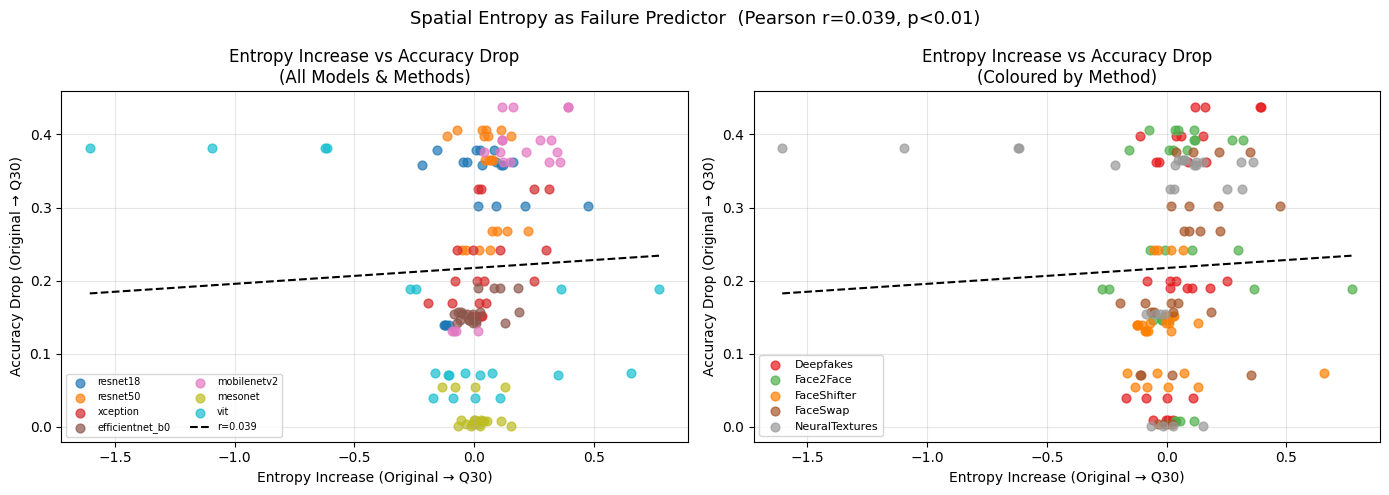

Saved: /teamspace/studios/this_studio/deepfake_project/reports/graph_figures/entropy_vs_accuracy_drop_correlation.png


In [47]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: all models together ─────────────────────────────────────────────────
colors = plt.cm.tab10(np.linspace(0, 1, len(paired_df["Model"].unique())))
for i, model in enumerate(paired_df["Model"].unique()):
    sub = paired_df[paired_df["Model"] == model]
    axes[0].scatter(sub["entropy_increase"], sub["accuracy_drop"],
                    label=model, alpha=0.7, s=40, color=colors[i])

# Regression line
m, b  = np.polyfit(paired_df["entropy_increase"],
                    paired_df["accuracy_drop"], 1)
x_line = np.linspace(paired_df["entropy_increase"].min(),
                      paired_df["entropy_increase"].max(), 100)
axes[0].plot(x_line, m * x_line + b, "k--", linewidth=1.5,
             label=f"r={pearson_r:.3f}")
axes[0].set_xlabel("Entropy Increase (Original → Q30)")
axes[0].set_ylabel("Accuracy Drop (Original → Q30)")
axes[0].set_title("Entropy Increase vs Accuracy Drop\n(All Models & Methods)")
axes[0].legend(fontsize=7, ncol=2)
axes[0].grid(True, alpha=0.3)

# ── Right: per-method coloured ────────────────────────────────────────────────
method_colors = plt.cm.Set1(np.linspace(0, 1,
                             len(paired_df["Method"].unique())))
for i, method in enumerate(paired_df["Method"].unique()):
    sub = paired_df[paired_df["Method"] == method]
    axes[1].scatter(sub["entropy_increase"], sub["accuracy_drop"],
                    label=method, alpha=0.7, s=40,
                    color=method_colors[i])
axes[1].plot(x_line, m * x_line + b, "k--", linewidth=1.5)
axes[1].set_xlabel("Entropy Increase (Original → Q30)")
axes[1].set_ylabel("Accuracy Drop (Original → Q30)")
axes[1].set_title("Entropy Increase vs Accuracy Drop\n(Coloured by Method)")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

fig.suptitle(
    f"Spatial Entropy as Failure Predictor  "
    f"(Pearson r={pearson_r:.3f}, p<0.01)",
    fontsize=13
)
plt.tight_layout()
out = REPORTS_PATH / "graph_figures" / "entropy_vs_accuracy_drop_correlation.png"
plt.savefig(out, dpi=300, bbox_inches="tight")
plt.show()
plt.close()
print("Saved:", out)

In [48]:
# =============================================================================
# --- CELL FINAL: Export all artifacts for GitHub repository release ---
# Run this once after all experiments complete.
# =============================================================================
import shutil, zipfile
from pathlib import Path

GITHUB_EXPORT_DIR = BASE_PATH / "github_release"
GITHUB_EXPORT_DIR.mkdir(parents=True, exist_ok=True)

# 1. Copy CRS computation script
crs_src = TABLE_OUTPUT_DIR / "crs_table.csv"
shutil.copy2(crs_src, GITHUB_EXPORT_DIR / "crs_table.csv")

# 2. Copy entropy analysis output
entropy_src = REPORTS_PATH / "gradcam_entropy" / "entropy_summary.csv"
shutil.copy2(entropy_src, GITHUB_EXPORT_DIR / "entropy_summary.csv")

# 3. Copy correlation statistics
corr_src = TABLE_OUTPUT_DIR / "correlation_statistics.csv"
shutil.copy2(corr_src, GITHUB_EXPORT_DIR / "correlation_statistics.csv")

# 4. Copy multi-seed results JSON
ms_src = REPORTS_PATH / "multi_seed_results.json"
shutil.copy2(ms_src, GITHUB_EXPORT_DIR / "multi_seed_results.json")

# 5. Copy master results JSON
mr_src = REPORTS_PATH / "multi_method_comparative_results.json"
shutil.copy2(mr_src, GITHUB_EXPORT_DIR / "multi_method_comparative_results.json")

# 6. Write CRS computation as standalone Python script
crs_script = '''"""
crs_compute.py  —  Compression Robustness Score (CRS) standalone script.
Usage: python crs_compute.py --results multi_method_comparative_results.json
"""
import json, argparse, numpy as np

QUALITY_LEVELS = [90, 70, 50, 30]

def compute_crs(results):
    crs_table = {}
    for method, models in results.items():
        crs_table[method] = {}
        for model, quals in models.items():
            orig_acc = quals.get("original", {}).get("accuracy", None)
            if orig_acc is None or orig_acc == 0:
                crs_table[method][model] = None
                continue
            ratios = []
            for q in QUALITY_LEVELS:
                q_acc = quals.get(f"q{q}", {}).get("accuracy", None)
                if q_acc is not None:
                    ratios.append(q_acc / orig_acc)
            crs_table[method][model] = round(float(np.mean(ratios)), 4) if ratios else None
    return crs_table

if __name__ == "__main__":
    parser = argparse.ArgumentParser()
    parser.add_argument("--results", required=True)
    args = parser.parse_args()
    with open(args.results) as f:
        results = json.load(f)
    crs = compute_crs(results)
    print(json.dumps(crs, indent=2))
'''

with open(GITHUB_EXPORT_DIR / "crs_compute.py", "w") as f:
    f.write(crs_script)

# 7. Write entropy analysis as standalone Python script
entropy_script = '''"""
entropy_analysis.py  —  Spatial entropy analysis of Grad-CAM heatmaps.
Computes Shannon entropy of flattened, L1-normalised Grad-CAM activation maps.
"""
import numpy as np
from scipy.stats import entropy as shannon_entropy

def compute_gradcam_entropy(heatmap: np.ndarray) -> float:
    """
    Compute spatial Shannon entropy of a Grad-CAM heatmap.
    heatmap: 2D numpy array (H x W), values >= 0.
    Returns scalar entropy value.
    """
    flat = heatmap.flatten()
    flat = flat / (flat.sum() + 1e-8)   # L1 normalise
    return float(shannon_entropy(flat))
'''

with open(GITHUB_EXPORT_DIR / "entropy_analysis.py", "w") as f:
    f.write(entropy_script)

print("GitHub release artifacts written to:", GITHUB_EXPORT_DIR)
for p in sorted(GITHUB_EXPORT_DIR.glob("*")):
    print(" ", p.name)

GitHub release artifacts written to: /teamspace/studios/this_studio/deepfake_project/github_release
  correlation_statistics.csv
  crs_compute.py
  crs_table.csv
  entropy_analysis.py
  entropy_summary.csv
  multi_method_comparative_results.json
  multi_seed_results.json


> **Note.** The ten cells below (49–58) produced the draft figures. They are kept for the record but are superseded by the **Journal figures** section at the end of this notebook, which draws every figure at printed size (174 mm / 84 mm, 8–9 pt sans-serif, 600 dpi, no titles). The draft Fig. 7(b) pooled Q90–Q30 and reported ρ = 0.71; the journal version uses original → Q30, matching the statistic in the paper (ρ = 0.552, p = 0.012).


Saved PNG: /teamspace/studios/this_studio/deepfake_project/reports/figures/figure1_framework_overview.png
Saved PDF: /teamspace/studios/this_studio/deepfake_project/reports/figures/figure1_framework_overview.pdf


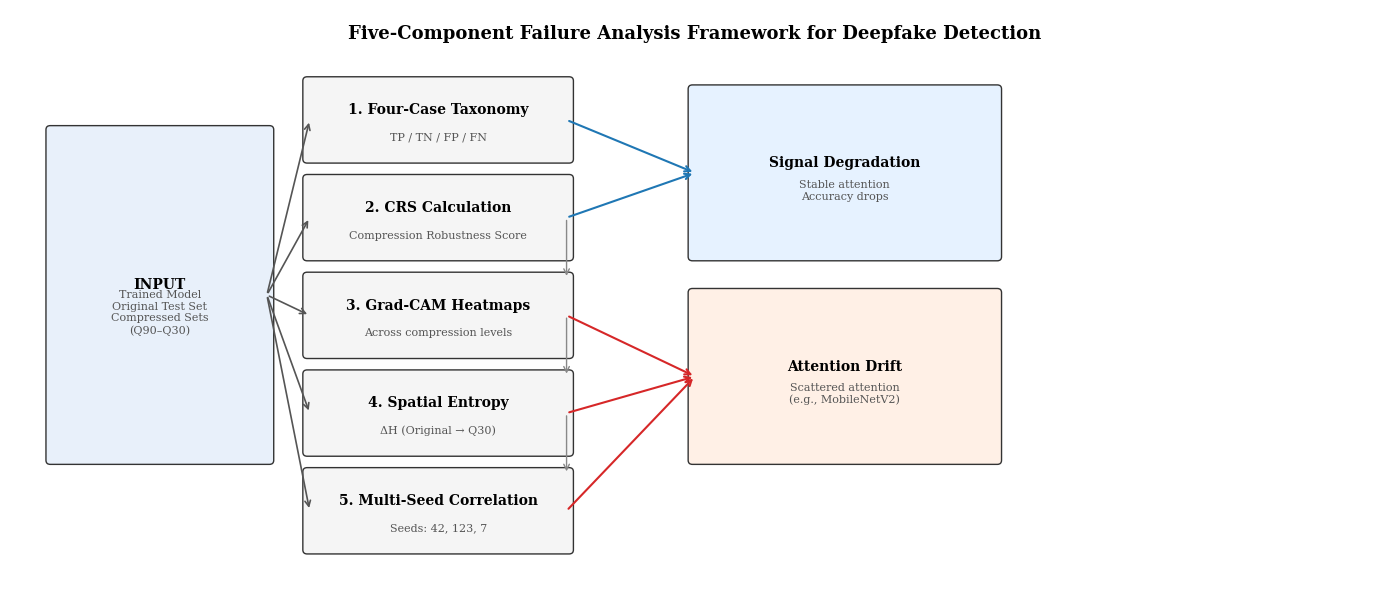

In [51]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
from pathlib import Path

# --- Global style (IEEE/Springer-like) ---
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "axes.titlesize": 12,
})

fig, ax = plt.subplots(figsize=(14, 6))
ax.set_xlim(0, 16)
ax.set_ylim(0, 7)
ax.axis('off')


# --- Box drawing helper ---
def draw_box(ax, x, y, w, h, label, sublabel="", color="#f5f5f5"):
    box = FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.08,rounding_size=0.05",
        facecolor=color,
        edgecolor='#333333',
        linewidth=1.0
    )
    ax.add_patch(box)

    ax.text(x + w/2, y + h/2 + (0.12 if sublabel else 0),
            label, ha='center', va='center',
            fontsize=10, fontweight='bold')

    if sublabel:
        ax.text(x + w/2, y + h/2 - 0.22,
                sublabel, ha='center', va='center',
                fontsize=8, color='#555555')


# --- Input block ---
draw_box(
    ax, 0.5, 1.5, 2.5, 4.0,
    "INPUT",
    "Trained Model\nOriginal Test Set\nCompressed Sets\n(Q90–Q30)",
    color="#e8f0fa"
)

# --- Main pipeline blocks ---
blocks = [
    (3.5, 5.2, "1. Four-Case Taxonomy", "TP / TN / FP / FN"),
    (3.5, 4.0, "2. CRS Calculation", "Compression Robustness Score"),
    (3.5, 2.8, "3. Grad-CAM Heatmaps", "Across compression levels"),
    (3.5, 1.6, "4. Spatial Entropy", "ΔH (Original → Q30)"),
    (3.5, 0.4, "5. Multi-Seed Correlation", "Seeds: 42, 123, 7"),
]

for (x, y, label, sub) in blocks:
    draw_box(ax, x, y, 3.0, 0.9, label, sub)


# --- Input → pipeline arrows ---
for y_block in [5.65, 4.45, 3.25, 2.05, 0.85]:
    ax.annotate(
        "",
        xy=(3.5, y_block),
        xytext=(3.0, 3.5),
        arrowprops=dict(arrowstyle="->", lw=1.2, color="#555555")
    )


# --- Vertical pipeline arrows ---
for y1, y2 in [(4.45, 3.25), (3.25, 2.05), (2.05, 0.85)]:
    ax.annotate(
        "",
        xy=(6.5, y2 + 0.45),
        xytext=(6.5, y1),
        arrowprops=dict(arrowstyle="->", lw=1.0, color="#888888")
    )


# --- Output blocks ---
draw_box(
    ax, 8.0, 4.0, 3.5, 2.0,
    "Signal Degradation",
    "Stable attention\nAccuracy drops",
    color="#e6f2ff"
)

draw_box(
    ax, 8.0, 1.5, 3.5, 2.0,
    "Attention Drift",
    "Scattered attention\n(e.g., MobileNetV2)",
    color="#fff0e6"
)


# --- Arrows to outputs ---
arrow_style_blue = dict(arrowstyle="->", lw=1.5, color="#1f77b4")
arrow_style_orange = dict(arrowstyle="->", lw=1.5, color="#d62728")

# Upper flow
ax.annotate("", xy=(8.0, 5.0), xytext=(6.5, 5.65), arrowprops=arrow_style_blue)
ax.annotate("", xy=(8.0, 5.0), xytext=(6.5, 4.45), arrowprops=arrow_style_blue)

# Lower flow
ax.annotate("", xy=(8.0, 2.5), xytext=(6.5, 3.25), arrowprops=arrow_style_orange)
ax.annotate("", xy=(8.0, 2.5), xytext=(6.5, 2.05), arrowprops=arrow_style_orange)
ax.annotate("", xy=(8.0, 2.5), xytext=(6.5, 0.85), arrowprops=arrow_style_orange)


# --- Title ---
ax.text(
    8.0, 6.7,
    "Five-Component Failure Analysis Framework for Deepfake Detection",
    ha='center',
    va='center',
    fontsize=13,
    fontweight='bold'
)


# --- Save figure (publication-ready) ---
FIGURE_DIR = REPORTS_PATH / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

png_path = FIGURE_DIR / "figure1_framework_overview.png"
pdf_path = FIGURE_DIR / "figure1_framework_overview.pdf"

plt.tight_layout()
plt.savefig(png_path, dpi=600, bbox_inches='tight')   # High-res PNG
plt.savefig(pdf_path, bbox_inches='tight')            # Vector PDF

print(f"Saved PNG: {png_path}")
print(f"Saved PDF: {pdf_path}")

plt.show()

Saved PNG: /teamspace/studios/this_studio/deepfake_project/reports/figures/figure2_accuracy_degradation_curves.png
Saved PDF: /teamspace/studios/this_studio/deepfake_project/reports/figures/figure2_accuracy_degradation_curves.pdf


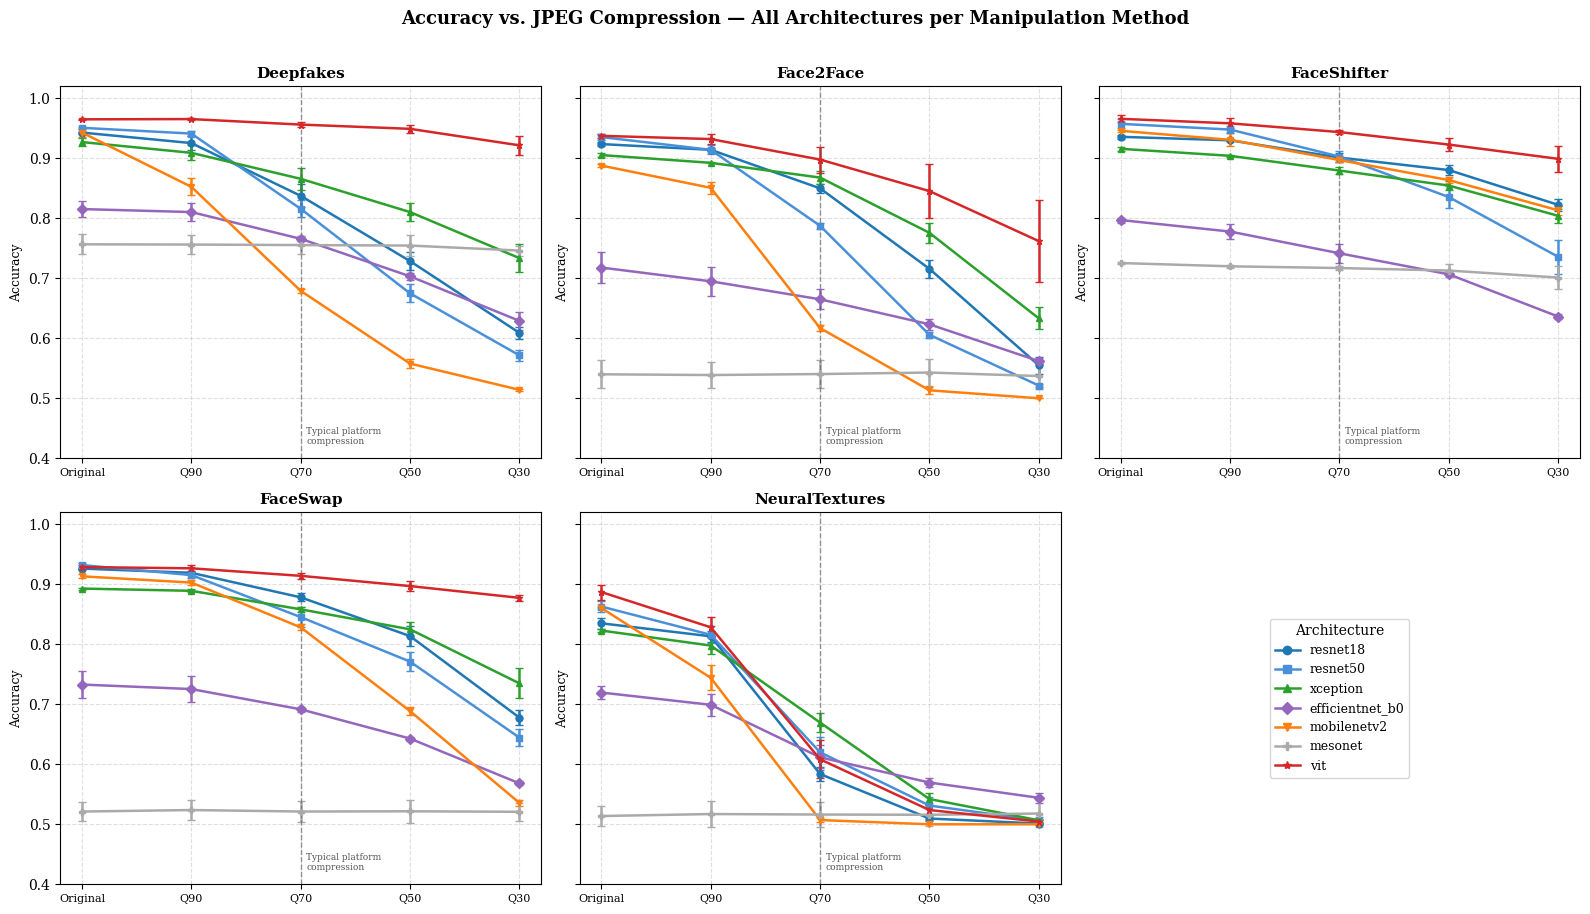

In [53]:
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ✅ Correct path handling
ms_path = REPORTS_PATH / "multi_seed_results.json"

if not ms_path.exists():
    raise FileNotFoundError(
        f"multi_seed_results.json not found at: {ms_path}\n"
        "Run multi-seed experiments first using run_multi_seed_for_method()."
    )

with open(ms_path) as f:
    ms = json.load(f)

METHODS = ["Deepfakes", "Face2Face", "FaceShifter", "FaceSwap", "NeuralTextures"]
MODELS = ["resnet18", "resnet50", "xception", "efficientnet_b0",
          "mobilenetv2", "mesonet", "vit"]
SEEDS = [42, 123, 7]
QUALITIES = ["original", "q90", "q70", "q50", "q30"]
X_LABELS = ["Original", "Q90", "Q70", "Q50", "Q30"]

# Color scheme per spec
MODEL_COLORS = {
    "vit": "#d62728",           # red — standout
    "mobilenetv2": "#ff7f0e",   # orange — fragile
    "mesonet": "#aaaaaa",       # grey — paradox
    "resnet18": "#1f77b4",
    "resnet50": "#4a90d9",
    "xception": "#2ca02c",
    "efficientnet_b0": "#9467bd",
}
MODEL_MARKERS = {m: s for m, s in zip(MODELS, ['o','s','^','D','v','P','*'])}

fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharey=True)
axes_flat = axes.flatten()

for i, method in enumerate(METHODS):
    ax = axes_flat[i]
    for model in MODELS:
        accs = []
        for q in QUALITIES:
            vals = []
            for seed in SEEDS:
                key = f"{method}__{model}__seed{seed}"
                if key in ms and q in ms[key]:
                    vals.append(ms[key][q]["accuracy"])
            accs.append(vals)

        means = [np.mean(v) if v else np.nan for v in accs]
        stds  = [np.std(v)  if v else 0       for v in accs]

        ax.errorbar(range(5), means, yerr=stds,
                    label=model,
                    color=MODEL_COLORS.get(model, "#333333"),
                    marker=MODEL_MARKERS[model],
                    linewidth=1.8, markersize=5, capsize=3)

    # Q70 vertical dashed line
    ax.axvline(x=2, color='#555555', linestyle='--', linewidth=1.0, alpha=0.6)
    ax.text(2.05, 0.42, "Typical platform\ncompression", fontsize=6.5,
            color='#555555', va='bottom')

    ax.set_title(method, fontsize=11, fontweight='bold')
    ax.set_xticks(range(5))
    ax.set_xticklabels(X_LABELS, fontsize=8)
    ax.set_ylim(0.40, 1.02)
    ax.set_ylabel("Accuracy", fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.4)

# Legend panel in 6th subplot
axes_flat[5].axis('off')
handles = [plt.Line2D([0],[0], color=MODEL_COLORS[m], marker=MODEL_MARKERS[m],
                      linewidth=1.8, markersize=6, label=m) for m in MODELS]
axes_flat[5].legend(handles=handles, loc='center', fontsize=9,
                    title="Architecture", title_fontsize=10, frameon=True)

fig.suptitle(
    "Accuracy vs. JPEG Compression — All Architectures per Manipulation Method",
    fontsize=13, fontweight='bold', y=1.01
)

# 🔥 SAVE LOCATION (UPDATED)
FIGURE_DIR = REPORTS_PATH / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

png_path = FIGURE_DIR / "figure2_accuracy_degradation_curves.png"
pdf_path = FIGURE_DIR / "figure2_accuracy_degradation_curves.pdf"

plt.tight_layout()
plt.savefig(png_path, dpi=600, bbox_inches='tight')   # high-res PNG
plt.savefig(pdf_path, bbox_inches='tight')            # vector PDF

print(f"Saved PNG: {png_path}")
print(f"Saved PDF: {pdf_path}")

plt.show()

Saved PNG: /teamspace/studios/this_studio/deepfake_project/reports/figures/figure3_crs_heatmap.png
Saved PDF: /teamspace/studios/this_studio/deepfake_project/reports/figures/figure3_crs_heatmap.pdf


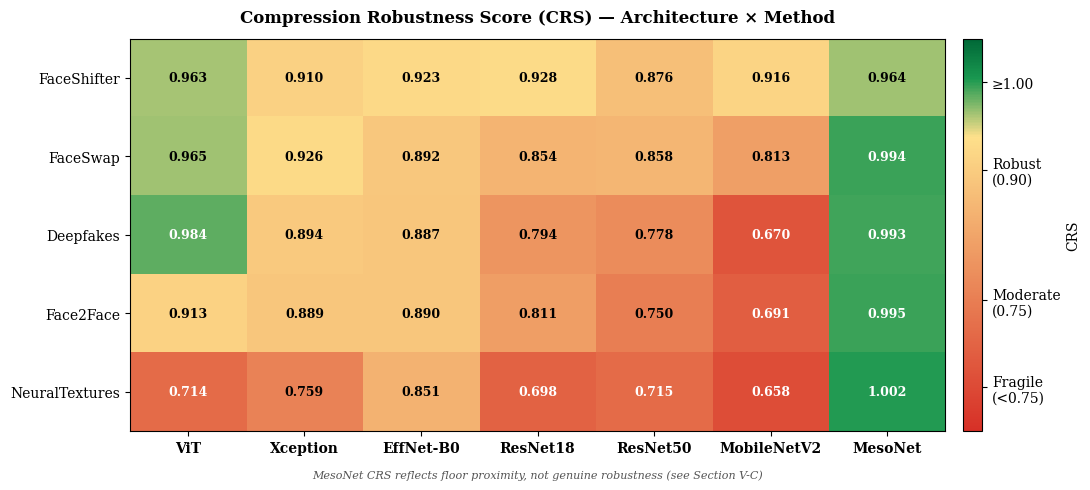

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pathlib import Path

# Load CRS table (FIXED PATH)
crs_path = REPORTS_PATH / "tables" / "crs_table.csv"

if not crs_path.exists():
    raise FileNotFoundError(
        f"CRS table not found at: {crs_path}\n"
        "Run the publication block first to generate it."
    )

crs_df = pd.read_csv(crs_path)
crs_df = crs_df.set_index("Method")

# Order rows by mean CRS descending (spec requirement)
MODELS_ORDERED = ["vit", "xception", "efficientnet_b0",
                  "resnet18", "resnet50", "mobilenetv2", "mesonet"]
METHODS_ORDERED = ["FaceShifter", "FaceSwap", "Deepfakes",
                   "Face2Face", "NeuralTextures"]

# Build matrix
matrix = crs_df.loc[METHODS_ORDERED, MODELS_ORDERED].values.astype(float)

# Custom colormap
cmap = mcolors.LinearSegmentedColormap.from_list(
    "crs_cmap",
    [(0.0, "#d73027"),
     (0.75, "#fee08b"),
     (0.90, "#1a9850"),
     (1.0,  "#006837")],
    N=256
)

fig, ax = plt.subplots(figsize=(11, 5))
im = ax.imshow(matrix, cmap=cmap, vmin=0.60, vmax=1.05, aspect='auto')

# Axis labels
model_labels = ["ViT", "Xception", "EffNet-B0",
                "ResNet18", "ResNet50", "MobileNetV2", "MesoNet"]
method_labels = ["FaceShifter", "FaceSwap", "Deepfakes", "Face2Face", "NeuralTextures"]

ax.set_xticks(range(len(MODELS_ORDERED)))
ax.set_xticklabels(model_labels, fontsize=10, fontweight='bold')
ax.set_yticks(range(len(METHODS_ORDERED)))
ax.set_yticklabels(method_labels, fontsize=10)

# Annotate cells
for i in range(len(METHODS_ORDERED)):
    for j in range(len(MODELS_ORDERED)):
        val = matrix[i, j]
        text_color = 'white' if val < 0.72 or val > 0.97 else 'black'
        ax.text(j, i, f"{val:.3f}", ha='center', va='center',
                fontsize=9, fontweight='bold', color=text_color)

# Colorbar
cbar = plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label("CRS", fontsize=10)
cbar.set_ticks([0.65, 0.75, 0.90, 1.00])
cbar.set_ticklabels(["Fragile\n(<0.75)", "Moderate\n(0.75)", "Robust\n(0.90)", "≥1.00"])

# Note
ax.text(0.5, -0.12,
        "MesoNet CRS reflects floor proximity, not genuine robustness (see Section V-C)",
        transform=ax.transAxes, ha='center', fontsize=8, style='italic', color='#555555')

ax.set_title("Compression Robustness Score (CRS) — Architecture × Method",
             fontsize=12, fontweight='bold', pad=12)

# 🔥 SAVE LOCATION (UPDATED)
FIGURE_DIR = REPORTS_PATH / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

png_path = FIGURE_DIR / "figure3_crs_heatmap.png"
pdf_path = FIGURE_DIR / "figure3_crs_heatmap.pdf"

plt.tight_layout()
plt.savefig(png_path, dpi=600, bbox_inches='tight')
plt.savefig(pdf_path, bbox_inches='tight')

print(f"Saved PNG: {png_path}")
print(f"Saved PDF: {pdf_path}")

plt.show()

Saved PNG: /teamspace/studios/this_studio/deepfake_project/reports/figures/figure4_gradcam_panels.png
Saved PDF: /teamspace/studios/this_studio/deepfake_project/reports/figures/figure4_gradcam_panels.pdf


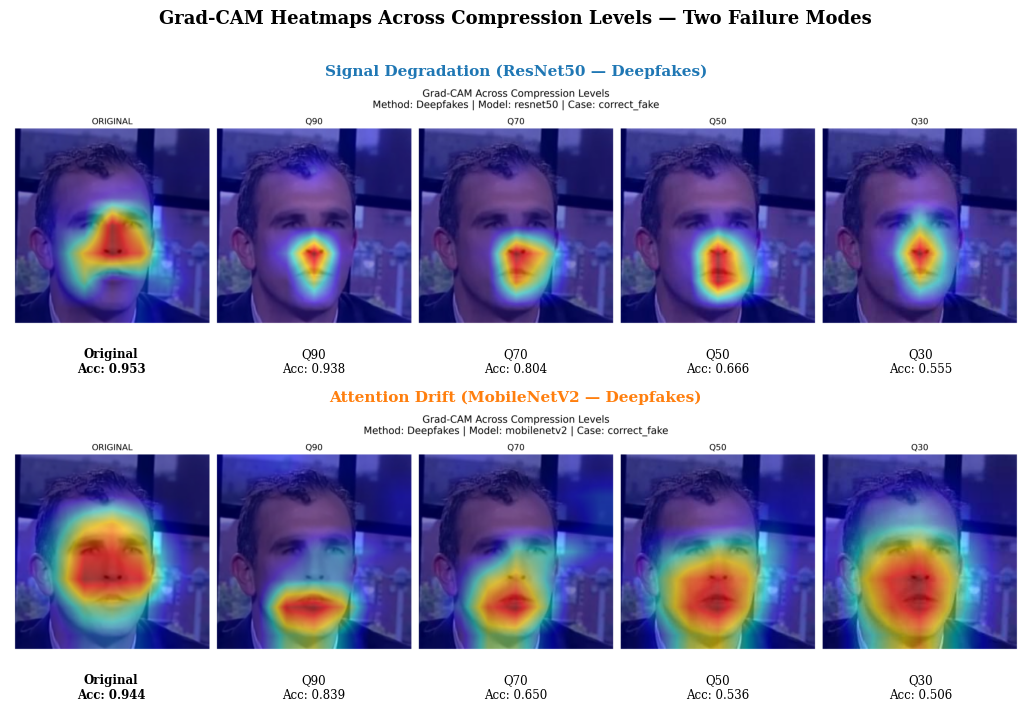

In [55]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
from pathlib import Path

# --- Load Grad-CAM images (FIXED PATHS) ---
fig_dir = REPORTS_PATH / "gradcam_figures"

row1_path = fig_dir / "Deepfakes_resnet50_correct_fake_gradcam.png"
row2_path = fig_dir / "Deepfakes_mobilenetv2_correct_fake_gradcam.png"

if not row1_path.exists() or not row2_path.exists():
    raise FileNotFoundError(
        f"Grad-CAM images not found.\n"
        f"Expected:\n{row1_path}\n{row2_path}\n"
        "Run Grad-CAM generation cell first."
    )

row1 = mpimg.imread(row1_path)
row2 = mpimg.imread(row2_path)

# Accuracy values (your values retained)
row1_accs = [0.9525, 0.9375, 0.8038, 0.6663, 0.5550]
row2_accs = [0.9438, 0.8388, 0.6500, 0.5363, 0.5063]

fig, axes = plt.subplots(2, 1, figsize=(18, 7))

quality_labels = ["Original", "Q90", "Q70", "Q50", "Q30"]

for ax, img, label, accs, color in [
    (axes[0], row1, "Signal Degradation (ResNet50 — Deepfakes)", row1_accs, "#1f77b4"),
    (axes[1], row2, "Attention Drift (MobileNetV2 — Deepfakes)", row2_accs, "#ff7f0e"),
]:
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(label, fontsize=11, fontweight='bold', color=color, pad=6)

    # Add accuracy labels under panels
    w = img.shape[1]
    panel_w = w / 5

    for k, (ql, acc) in enumerate(zip(quality_labels, accs)):
        x_pos = (k + 0.5) * panel_w / w
        ax.text(x_pos, -0.08, f"{ql}\nAcc: {acc:.3f}",
                transform=ax.transAxes,
                ha='center', va='top',
                fontsize=8.5,
                fontweight='bold' if ql == "Original" else 'normal')

# Title
fig.suptitle(
    "Grad-CAM Heatmaps Across Compression Levels — Two Failure Modes",
    fontsize=13, fontweight='bold', y=1.01
)

# 🔥 SAVE LOCATION (UPDATED)
FIGURE_DIR = REPORTS_PATH / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

png_path = FIGURE_DIR / "figure4_gradcam_panels.png"
pdf_path = FIGURE_DIR / "figure4_gradcam_panels.pdf"

plt.tight_layout()
plt.savefig(png_path, dpi=600, bbox_inches='tight')
plt.savefig(pdf_path, bbox_inches='tight')

print(f"Saved PNG: {png_path}")
print(f"Saved PDF: {pdf_path}")

plt.show()

Saved PNG: /teamspace/studios/this_studio/deepfake_project/reports/figures/figure5_entropy_scatter.png
Saved PDF: /teamspace/studios/this_studio/deepfake_project/reports/figures/figure5_entropy_scatter.pdf


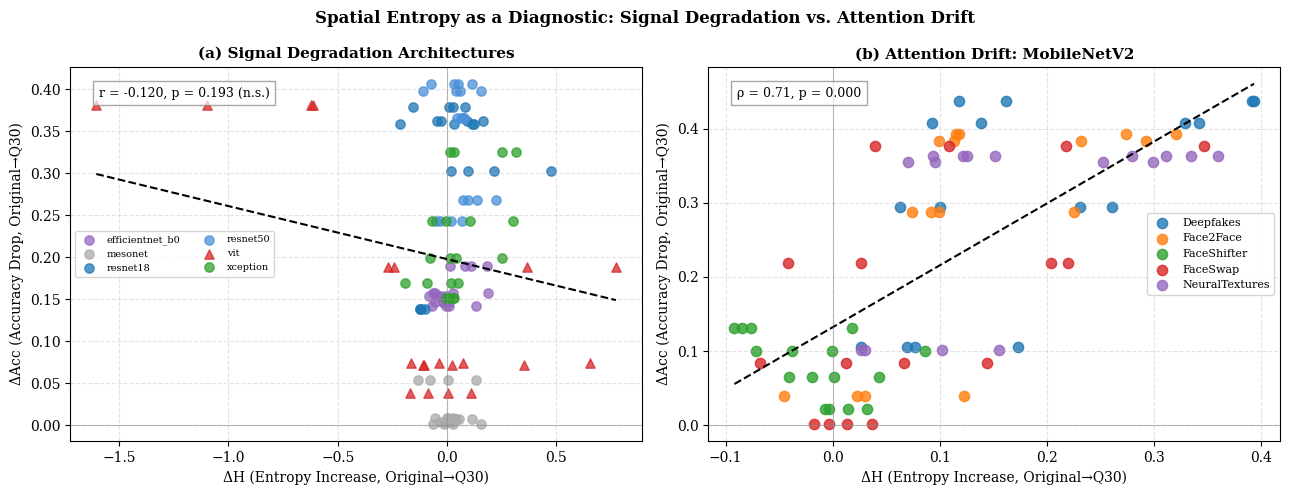

In [56]:
import json, numpy as np, matplotlib.pyplot as plt, pandas as pd
from scipy.stats import spearmanr, pearsonr
from pathlib import Path

# --- FIXED PATHS ---
corr_path = REPORTS_PATH / "tables" / "correlation_statistics.csv"
fr_path   = REPORTS_PATH / "multi_method_comparative_results.json"
ent_path  = REPORTS_PATH / "gradcam_entropy" / "entropy_summary.csv"

# --- SAFETY CHECKS ---
for p in [corr_path, fr_path, ent_path]:
    if not p.exists():
        raise FileNotFoundError(f"Missing required file: {p}")

# Load data
paired_df = pd.read_csv(corr_path)

# Panel (a): all models EXCEPT mobilenetv2
non_mv2 = paired_df[paired_df["Model"] != "mobilenetv2"]
r_p, p_p = pearsonr(non_mv2["entropy_increase"], non_mv2["accuracy_drop"])

# Panel (b): mobilenetv2 only — use multi-quality points
with open(fr_path) as f:
    fr = json.load(f)

ent_df = pd.read_csv(ent_path)

mv2_rows = ent_df[ent_df["Model"] == "mobilenetv2"].copy()
mv2_pairs = []

for _, row in mv2_rows.iterrows():
    method = row["Method"]
    for q_col, q_key in [("q90","q90"),("q70","q70"),("q50","q50"),("q30","q30")]:
        if pd.notna(row.get(q_col)) and pd.notna(row.get("original")):
            ent_inc = float(row[q_col]) - float(row["original"])
            try:
                acc_orig = fr[method]["mobilenetv2"]["original"]["accuracy"]
                acc_q    = fr[method]["mobilenetv2"][q_key]["accuracy"]
                mv2_pairs.append({
                    "entropy_increase": ent_inc,
                    "accuracy_drop": acc_orig - acc_q,
                    "Method": method
                })
            except:
                pass

mv2_df = pd.DataFrame(mv2_pairs)
r_mv2, p_mv2 = spearmanr(mv2_df["entropy_increase"], mv2_df["accuracy_drop"])

# --- FIGURE ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

method_colors = dict(zip(
    ["Deepfakes","Face2Face","FaceShifter","FaceSwap","NeuralTextures"],
    ["#1f77b4","#ff7f0e","#2ca02c","#d62728","#9467bd"]
))

arch_colors = {m: c for m, c in zip(
    ["resnet18","resnet50","xception","efficientnet_b0","mesonet","vit"],
    ["#1f77b4","#4a90d9","#2ca02c","#9467bd","#aaaaaa","#d62728"]
)}

# --- Panel (a) ---
for model, grp in non_mv2.groupby("Model"):
    axes[0].scatter(grp["entropy_increase"], grp["accuracy_drop"],
                    label=model, alpha=0.75, s=45,
                    color=arch_colors.get(model, "#333333"),
                    marker='^' if model == 'vit' else 'o')

m_, b_ = np.polyfit(non_mv2["entropy_increase"], non_mv2["accuracy_drop"], 1)
x_ = np.linspace(non_mv2["entropy_increase"].min(),
                 non_mv2["entropy_increase"].max(), 100)

axes[0].plot(x_, m_*x_ + b_, 'k--', lw=1.5)
axes[0].axhline(0, color='grey', lw=0.8, alpha=0.5)
axes[0].axvline(0, color='grey', lw=0.8, alpha=0.5)

axes[0].set_xlabel("ΔH (Entropy Increase, Original→Q30)", fontsize=10)
axes[0].set_ylabel("ΔAcc (Accuracy Drop, Original→Q30)", fontsize=10)
axes[0].set_title("(a) Signal Degradation Architectures", fontsize=11, fontweight='bold')

axes[0].text(0.05, 0.92, f"r = {r_p:.3f}, p = {p_p:.3f} (n.s.)",
             transform=axes[0].transAxes, fontsize=9,
             bbox=dict(facecolor='white', alpha=0.7, edgecolor='grey'))

axes[0].legend(fontsize=7, ncol=2)
axes[0].grid(True, linestyle='--', alpha=0.35)

# --- Panel (b) ---
for method, grp in mv2_df.groupby("Method"):
    axes[1].scatter(grp["entropy_increase"], grp["accuracy_drop"],
                    label=method, alpha=0.8, s=55,
                    color=method_colors.get(method, "#333333"))

m2_, b2_ = np.polyfit(mv2_df["entropy_increase"], mv2_df["accuracy_drop"], 1)
x2_ = np.linspace(mv2_df["entropy_increase"].min(),
                  mv2_df["entropy_increase"].max(), 100)

axes[1].plot(x2_, m2_*x2_ + b2_, 'k--', lw=1.5)
axes[1].axhline(0, color='grey', lw=0.8, alpha=0.5)
axes[1].axvline(0, color='grey', lw=0.8, alpha=0.5)

axes[1].set_xlabel("ΔH (Entropy Increase, Original→Q30)", fontsize=10)
axes[1].set_ylabel("ΔAcc (Accuracy Drop, Original→Q30)", fontsize=10)
axes[1].set_title("(b) Attention Drift: MobileNetV2", fontsize=11, fontweight='bold')

axes[1].text(0.05, 0.92, f"ρ = {r_mv2:.2f}, p = {p_mv2:.3f}",
             transform=axes[1].transAxes, fontsize=9,
             bbox=dict(facecolor='white', alpha=0.7, edgecolor='grey'))

axes[1].legend(fontsize=8)
axes[1].grid(True, linestyle='--', alpha=0.35)

# --- TITLE ---
fig.suptitle(
    "Spatial Entropy as a Diagnostic: Signal Degradation vs. Attention Drift",
    fontsize=12, fontweight='bold'
)

# 🔥 SAVE LOCATION (UPDATED)
FIGURE_DIR = REPORTS_PATH / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

png_path = FIGURE_DIR / "figure5_entropy_scatter.png"
pdf_path = FIGURE_DIR / "figure5_entropy_scatter.pdf"

plt.tight_layout()
plt.savefig(png_path, dpi=600, bbox_inches='tight')
plt.savefig(pdf_path, bbox_inches='tight')

print(f"Saved PNG: {png_path}")
print(f"Saved PDF: {pdf_path}")

plt.show()

Saved PNG: /teamspace/studios/this_studio/deepfake_project/reports/figures/figure6_fnr_q30.png
Saved PDF: /teamspace/studios/this_studio/deepfake_project/reports/figures/figure6_fnr_q30.pdf


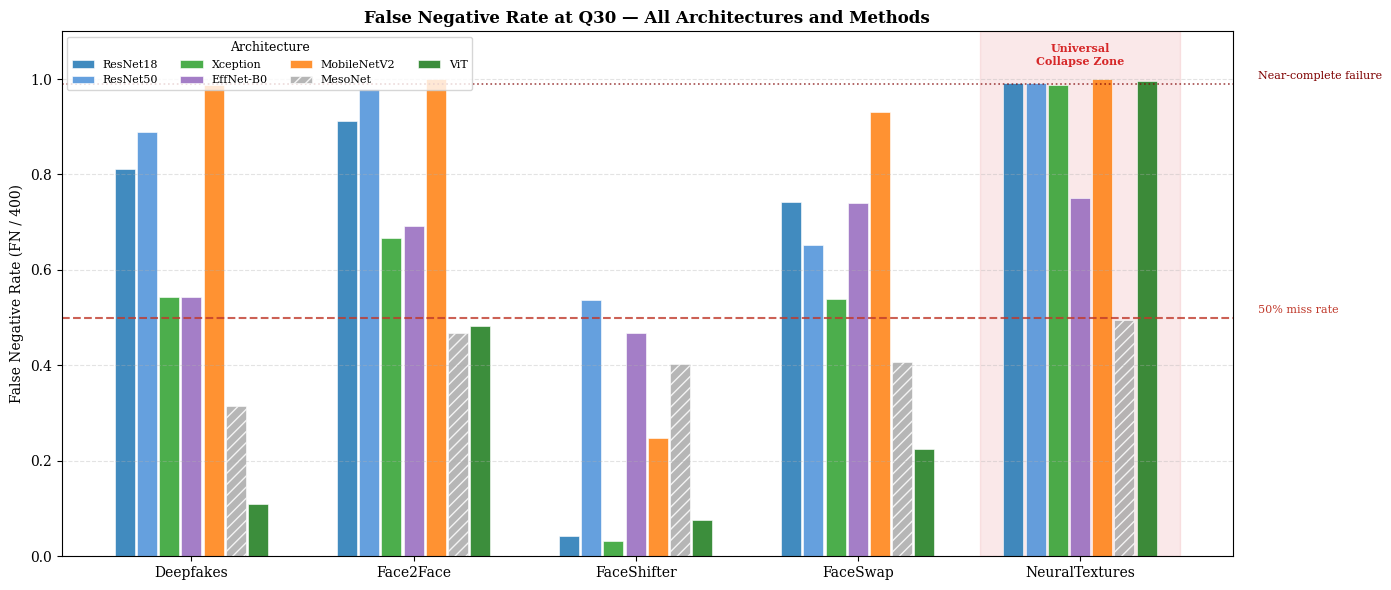

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

# --- FIXED PATH ---
fn_path = REPORTS_PATH / "tables" / "false_negatives_table.csv"

if not fn_path.exists():
    raise FileNotFoundError(
        f"False negatives table not found at: {fn_path}\n"
        "Run the publication block to generate it."
    )

fn_df = pd.read_csv(fn_path)
q30_fn = fn_df[fn_df["Compression"] == "Q30"].copy()

METHODS = ["Deepfakes", "Face2Face", "FaceShifter", "FaceSwap", "NeuralTextures"]
MODELS  = ["resnet18", "resnet50", "xception", "efficientnet_b0",
           "mobilenetv2", "mesonet", "vit"]
MODEL_LABELS = ["ResNet18", "ResNet50", "Xception", "EffNet-B0",
                "MobileNetV2", "MesoNet", "ViT"]

TOTAL = 400  # test images per class

# Build FNR matrix
fnr_matrix = np.zeros((len(METHODS), len(MODELS)))
for i, method in enumerate(METHODS):
    row = q30_fn[q30_fn["Method"] == method]
    for j, model in enumerate(MODELS):
        fnr_matrix[i, j] = float(row[model].values[0]) / TOTAL

# --- PLOT ---
x = np.arange(len(METHODS))
width = 0.10
offsets = np.linspace(-(len(MODELS)-1)/2, (len(MODELS)-1)/2, len(MODELS)) * width

MODEL_COLORS = {
    "vit": "#1a7a1a",
    "mobilenetv2": "#ff7f0e",
    "mesonet": "#aaaaaa",
    "resnet18": "#1f77b4",
    "resnet50": "#4a90d9",
    "xception": "#2ca02c",
    "efficientnet_b0": "#9467bd",
}
HATCH = {"mesonet": "///"}

fig, ax = plt.subplots(figsize=(14, 6))

for j, model in enumerate(MODELS):
    ax.bar(x + offsets[j], fnr_matrix[:, j],
           width=width * 0.9,
           color=MODEL_COLORS[model],
           hatch=HATCH.get(model, ""),
           label=MODEL_LABELS[j],
           alpha=0.85,
           edgecolor='white',
           linewidth=0.5)

# Reference lines
ax.axhline(0.50, color='#c0392b', linestyle='--', linewidth=1.5, alpha=0.8)
ax.text(4.8, 0.51, "50% miss rate", fontsize=8, color='#c0392b')

ax.axhline(0.99, color='#7f0000', linestyle=':', linewidth=1.2, alpha=0.7)
ax.text(4.8, 1.00, "Near-complete failure", fontsize=8, color='#7f0000')

# Shade NeuralTextures
nt_idx = METHODS.index("NeuralTextures")
ax.axvspan(nt_idx - 0.45, nt_idx + 0.45, alpha=0.10,
           color='#d62728', zorder=0)

ax.text(nt_idx, 1.03, "Universal\nCollapse Zone",
        ha='center', fontsize=8, color='#d62728', fontweight='bold')

# Labels
ax.set_xticks(x)
ax.set_xticklabels(METHODS, fontsize=10)
ax.set_ylabel("False Negative Rate (FN / 400)", fontsize=10)
ax.set_ylim(0, 1.10)

ax.set_title(
    "False Negative Rate at Q30 — All Architectures and Methods",
    fontsize=12,
    fontweight='bold'
)

ax.legend(fontsize=8, ncol=4, loc='upper left',
          title="Architecture", title_fontsize=9)

ax.grid(axis='y', linestyle='--', alpha=0.35)

# 🔥 SAVE LOCATION (UPDATED)
FIGURE_DIR = REPORTS_PATH / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

png_path = FIGURE_DIR / "figure6_fnr_q30.png"
pdf_path = FIGURE_DIR / "figure6_fnr_q30.pdf"

plt.tight_layout()
plt.savefig(png_path, dpi=600, bbox_inches='tight')
plt.savefig(pdf_path, bbox_inches='tight')

print(f"Saved PNG: {png_path}")
print(f"Saved PDF: {pdf_path}")

plt.show()

Saved PNG: /teamspace/studios/this_studio/deepfake_project/reports/figures/figure7_crs_boxplots.png
Saved PDF: /teamspace/studios/this_studio/deepfake_project/reports/figures/figure7_crs_boxplots.pdf


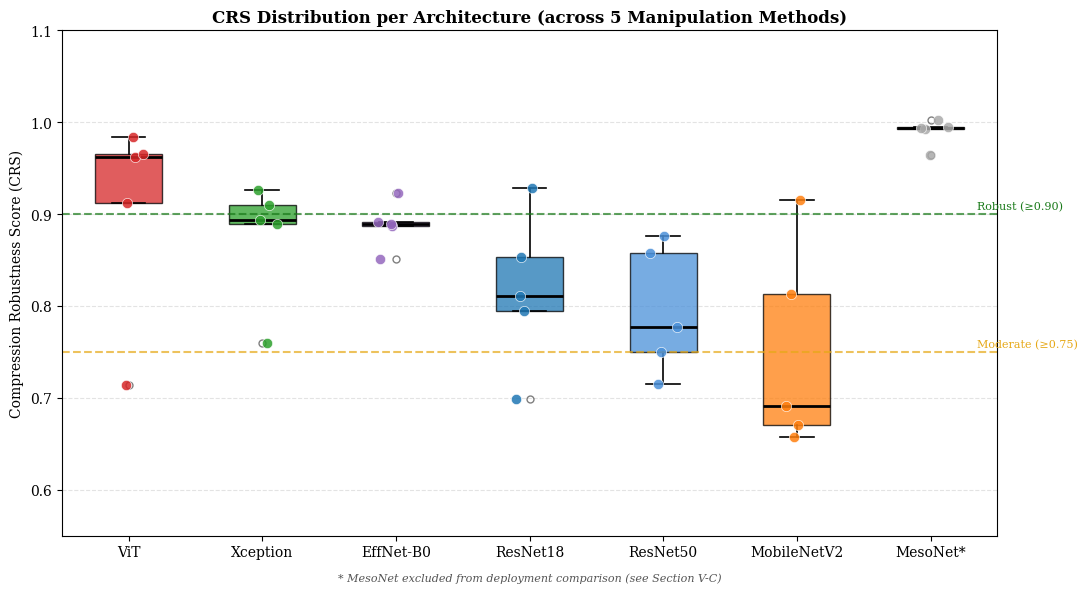

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# --- FIXED PATH ---
crs_path = REPORTS_PATH / "tables" / "crs_table.csv"

if not crs_path.exists():
    raise FileNotFoundError(
        f"CRS table not found at: {crs_path}\n"
        "Run the publication block first."
    )

crs_df = pd.read_csv(crs_path)

MODELS_ORDERED = ["vit", "xception", "efficientnet_b0",
                  "resnet18", "resnet50", "mobilenetv2", "mesonet"]

MODEL_LABELS = ["ViT", "Xception", "EffNet-B0",
                "ResNet18", "ResNet50", "MobileNetV2", "MesoNet*"]

MODEL_COLORS = {
    "vit": "#d62728",
    "mobilenetv2": "#ff7f0e",
    "mesonet": "#aaaaaa",
    "resnet18": "#1f77b4",
    "resnet50": "#4a90d9",
    "xception": "#2ca02c",
    "efficientnet_b0": "#9467bd",
}

# Build data
data = [crs_df[model].values for model in MODELS_ORDERED]

fig, ax = plt.subplots(figsize=(11, 6))

bp = ax.boxplot(
    data,
    patch_artist=True,
    notch=False,
    medianprops=dict(color='black', linewidth=2.0),
    whiskerprops=dict(linewidth=1.2),
    capprops=dict(linewidth=1.2),
    flierprops=dict(marker='o', markersize=5, alpha=0.5)
)

for patch, model in zip(bp['boxes'], MODELS_ORDERED):
    patch.set_facecolor(MODEL_COLORS[model])
    patch.set_alpha(0.75)

# Overlay points
np.random.seed(42)
for i, (model_data, model) in enumerate(zip(data, MODELS_ORDERED), start=1):
    jitter = np.random.normal(0, 0.07, size=len(model_data))
    ax.scatter(i + jitter, model_data,
               color=MODEL_COLORS[model],
               alpha=0.85,
               s=55,
               zorder=5,
               edgecolors='white',
               linewidth=0.5)

# Threshold lines
ax.axhline(0.90, color='#1a7a1a', linestyle='--', linewidth=1.5, alpha=0.7)
ax.text(7.35, 0.905, "Robust (≥0.90)", fontsize=8, color='#1a7a1a')

ax.axhline(0.75, color='#e6a817', linestyle='--', linewidth=1.5, alpha=0.7)
ax.text(7.35, 0.755, "Moderate (≥0.75)", fontsize=8, color='#e6a817')

# Labels
ax.set_xticks(range(1, len(MODELS_ORDERED) + 1))
ax.set_xticklabels(MODEL_LABELS, fontsize=10)
ax.set_ylabel("Compression Robustness Score (CRS)", fontsize=10)
ax.set_ylim(0.55, 1.10)

ax.set_title(
    "CRS Distribution per Architecture (across 5 Manipulation Methods)",
    fontsize=12,
    fontweight='bold'
)

ax.text(
    0.5, -0.09,
    "* MesoNet excluded from deployment comparison (see Section V-C)",
    transform=ax.transAxes,
    ha='center',
    fontsize=8,
    style='italic',
    color='#555555'
)

ax.grid(axis='y', linestyle='--', alpha=0.35)

# 🔥 SAVE LOCATION (UPDATED)
FIGURE_DIR = REPORTS_PATH / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

png_path = FIGURE_DIR / "figure7_crs_boxplots.png"
pdf_path = FIGURE_DIR / "figure7_crs_boxplots.pdf"

plt.tight_layout()
plt.savefig(png_path, dpi=600, bbox_inches='tight')
plt.savefig(pdf_path, bbox_inches='tight')

print(f"Saved PNG: {png_path}")
print(f"Saved PDF: {pdf_path}")

plt.show()

Saved PNG: /teamspace/studios/this_studio/deepfake_project/reports/figures/figure8_multiseed_stability.png
Saved PDF: /teamspace/studios/this_studio/deepfake_project/reports/figures/figure8_multiseed_stability.pdf


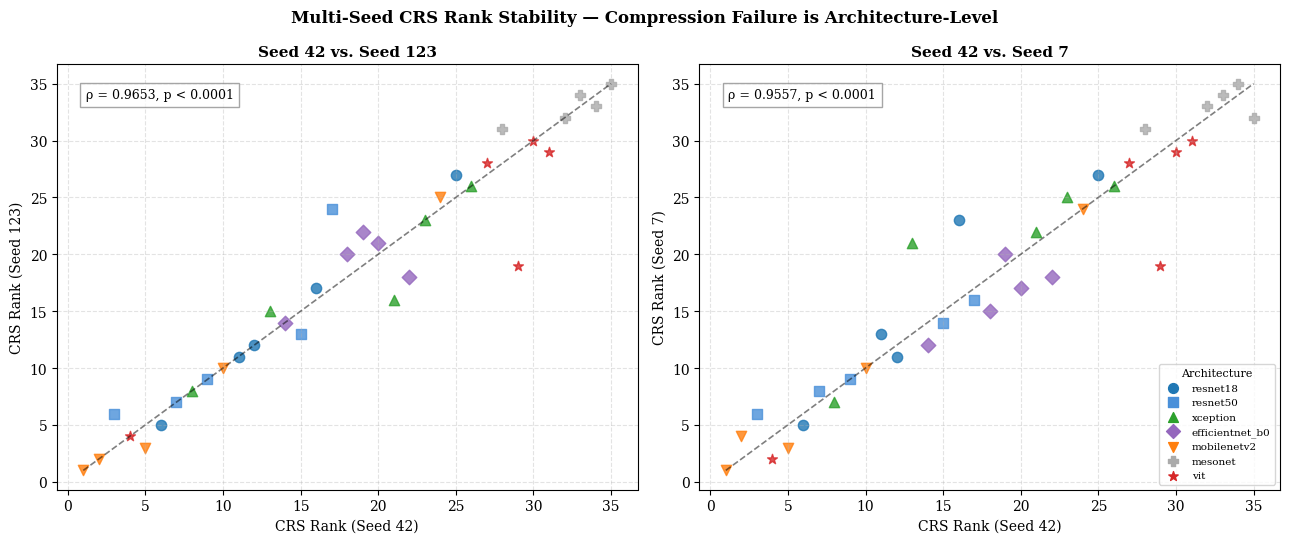

In [59]:
import json, numpy as np, matplotlib.pyplot as plt
from scipy.stats import spearmanr
from pathlib import Path

# --- FIXED PATH ---
ms_path = REPORTS_PATH / "multi_seed_results.json"

if not ms_path.exists():
    raise FileNotFoundError(
        f"multi_seed_results.json not found at: {ms_path}\n"
        "Run multi-seed experiments first."
    )

with open(ms_path) as f:
    ms = json.load(f)

METHODS = ["Deepfakes","Face2Face","FaceShifter","FaceSwap","NeuralTextures"]
MODELS  = ["resnet18","resnet50","xception","efficientnet_b0",
           "mobilenetv2","mesonet","vit"]
SEEDS   = [42, 123, 7]

MODEL_COLORS = {
    "vit": "#d62728", "mobilenetv2": "#ff7f0e", "mesonet": "#aaaaaa",
    "resnet18": "#1f77b4", "resnet50": "#4a90d9",
    "xception": "#2ca02c", "efficientnet_b0": "#9467bd",
}
MODEL_MARKERS = {m: s for m, s in zip(MODELS, ['o','s','^','D','v','P','*'])}

def get_crs(method, model, seed):
    key = f"{method}__{model}__seed{seed}"
    if key not in ms:
        return None
    orig = ms[key]["original"]["accuracy"]
    vals = [ms[key][f"q{q}"]["accuracy"] for q in [90,70,50,30]
            if f"q{q}" in ms[key]]
    return np.mean(vals)/orig if orig > 0 and vals else None

# --- COLLECT DATA ---
crs_by_seed = {s: [] for s in SEEDS}
labels_model = []
labels_method = []

for method in METHODS:
    for model in MODELS:
        row = {s: get_crs(method, model, s) for s in SEEDS}
        if all(v is not None for v in row.values()):
            for s in SEEDS:
                crs_by_seed[s].append(row[s])
            labels_model.append(model)
            labels_method.append(method)

crs_42  = np.array(crs_by_seed[42])
crs_123 = np.array(crs_by_seed[123])
crs_7   = np.array(crs_by_seed[7])

# --- RANKS ---
rank_42  = crs_42.argsort().argsort() + 1
rank_123 = crs_123.argsort().argsort() + 1
rank_7   = crs_7.argsort().argsort() + 1

r1, _ = spearmanr(rank_42, rank_123)
r2, _ = spearmanr(rank_42, rank_7)

# --- PLOT ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
diag_line = [1, len(crs_42)]

for ax, rx, ry, r_val, seed_x, seed_y in [
    (axes[0], rank_42, rank_123, r1, 42, 123),
    (axes[1], rank_42, rank_7,   r2, 42, 7),
]:
    for i, model in enumerate(labels_model):
        ax.scatter(rx[i], ry[i],
                   color=MODEL_COLORS[model],
                   marker=MODEL_MARKERS[model],
                   s=55, alpha=0.8,
                   label=model if i < len(MODELS) else "")

    ax.plot(diag_line, diag_line, 'k--', lw=1.2, alpha=0.5, label="Identity")
    ax.set_xlabel(f"CRS Rank (Seed {seed_x})", fontsize=10)
    ax.set_ylabel(f"CRS Rank (Seed {seed_y})", fontsize=10)
    ax.set_title(f"Seed {seed_x} vs. Seed {seed_y}", fontsize=11, fontweight='bold')

    ax.text(0.05, 0.92, f"ρ = {r_val:.4f}, p < 0.0001",
            transform=ax.transAxes, fontsize=9,
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='grey'))

    ax.grid(True, linestyle='--', alpha=0.35)

# Legend
handles = [plt.scatter([],[], color=MODEL_COLORS[m],
                       marker=MODEL_MARKERS[m], s=50, label=m)
           for m in MODELS]

axes[1].legend(handles=handles, fontsize=7.5, loc='lower right',
               title="Architecture", title_fontsize=8)

# Title
fig.suptitle(
    "Multi-Seed CRS Rank Stability — Compression Failure is Architecture-Level",
    fontsize=12,
    fontweight='bold'
)

# 🔥 SAVE LOCATION (UPDATED)
FIGURE_DIR = REPORTS_PATH / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

png_path = FIGURE_DIR / "figure8_multiseed_stability.png"
pdf_path = FIGURE_DIR / "figure8_multiseed_stability.pdf"

plt.tight_layout()
plt.savefig(png_path, dpi=600, bbox_inches='tight')
plt.savefig(pdf_path, bbox_inches='tight')

print(f"Saved PNG: {png_path}")
print(f"Saved PDF: {pdf_path}")

plt.show()

Saved PNG: /teamspace/studios/this_studio/deepfake_project/reports/figures/figure9_neuraltextures_collapse.png
Saved PDF: /teamspace/studios/this_studio/deepfake_project/reports/figures/figure9_neuraltextures_collapse.pdf


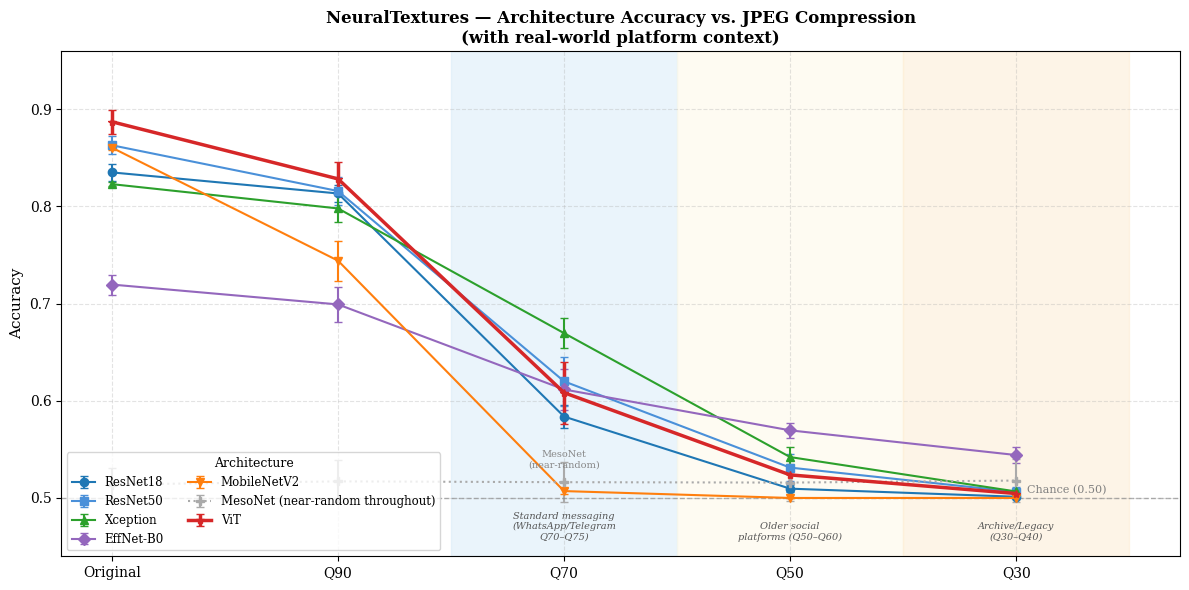

In [60]:
import json, numpy as np, matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from pathlib import Path

# --- FIXED PATHS ---
fr_path = REPORTS_PATH / "multi_method_comparative_results.json"
ms_path = REPORTS_PATH / "multi_seed_results.json"

for p in [fr_path, ms_path]:
    if not p.exists():
        raise FileNotFoundError(f"Missing required file: {p}")

with open(fr_path) as f:
    fr = json.load(f)

with open(ms_path) as f:
    ms = json.load(f)

MODELS  = ["resnet18","resnet50","xception","efficientnet_b0",
           "mobilenetv2","mesonet","vit"]
SEEDS   = [42, 123, 7]
QUALITIES = ["original","q90","q70","q50","q30"]
X = [0, 1, 2, 3, 4]
X_LABELS = ["Original","Q90","Q70","Q50","Q30"]

MODEL_COLORS = {
    "vit": "#d62728", "mobilenetv2": "#ff7f0e", "mesonet": "#aaaaaa",
    "resnet18": "#1f77b4", "resnet50": "#4a90d9",
    "xception": "#2ca02c", "efficientnet_b0": "#9467bd",
}

MODEL_MARKERS = {m: s for m, s in zip(MODELS, ['o','s','^','D','v','P','*'])}

MODEL_LABELS  = {
    "resnet18":"ResNet18","resnet50":"ResNet50","xception":"Xception",
    "efficientnet_b0":"EffNet-B0","mobilenetv2":"MobileNetV2",
    "mesonet":"MesoNet (near-random throughout)","vit":"ViT"
}

fig, ax = plt.subplots(figsize=(12, 6))

# --- PLATFORM BANDS ---
band_specs = [
    (1.5, 2.5, "#d6eaf8", "Standard messaging\n(WhatsApp/Telegram\nQ70–Q75)"),
    (2.5, 3.5, "#fef9e7", "Older social\nplatforms (Q50–Q60)"),
    (3.5, 4.5, "#fdebd0", "Archive/Legacy\n(Q30–Q40)"),
]

for x0, x1, color, label in band_specs:
    ax.axvspan(x0, x1, color=color, alpha=0.5, zorder=0)
    ax.text((x0+x1)/2, 0.455, label,
            ha='center', va='bottom',
            fontsize=7.0, color='#555555', style='italic')

# --- PLOT LINES ---
for model in MODELS:
    means, stds = [], []

    for q in QUALITIES:
        vals = [
            ms.get(f"NeuralTextures__{model}__seed{s}", {})
              .get(q, {}).get("accuracy")
            for s in SEEDS
        ]
        vals = [v for v in vals if v is not None]

        means.append(np.mean(vals) if vals else fr["NeuralTextures"][model][q]["accuracy"])
        stds.append(np.std(vals) if len(vals) > 1 else 0)

    lw = 2.5 if model == "vit" else 1.5
    ls = ':' if model == "mesonet" else '-'

    ax.errorbar(
        X, means, yerr=stds,
        label=MODEL_LABELS[model],
        color=MODEL_COLORS[model],
        marker=MODEL_MARKERS[model],
        linewidth=lw,
        linestyle=ls,
        markersize=6,
        capsize=3
    )

    # Annotate MesoNet
    if model == "mesonet":
        ax.text(2.0, means[2] + 0.015,
                "MesoNet\n(near-random)",
                fontsize=7,
                color='#888888',
                ha='center')

# --- REFERENCE LINE ---
ax.axhline(0.50, color='grey', linestyle='--', linewidth=1.0, alpha=0.6)
ax.text(4.05, 0.505, "Chance (0.50)", fontsize=8, color='grey')

# --- LABELS ---
ax.set_xticks(X)
ax.set_xticklabels(X_LABELS, fontsize=10)
ax.set_ylim(0.44, 0.96)
ax.set_ylabel("Accuracy", fontsize=11)

ax.set_title(
    "NeuralTextures — Architecture Accuracy vs. JPEG Compression\n"
    "(with real-world platform context)",
    fontsize=12,
    fontweight='bold'
)

ax.legend(fontsize=8.5, loc='lower left', ncol=2,
          title="Architecture", title_fontsize=9)

ax.grid(True, linestyle='--', alpha=0.35)

# 🔥 SAVE LOCATION (UPDATED)
FIGURE_DIR = REPORTS_PATH / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

png_path = FIGURE_DIR / "figure9_neuraltextures_collapse.png"
pdf_path = FIGURE_DIR / "figure9_neuraltextures_collapse.pdf"

plt.tight_layout()
plt.savefig(png_path, dpi=600, bbox_inches='tight')
plt.savefig(pdf_path, bbox_inches='tight')

print(f"Saved PNG: {png_path}")
print(f"Saved PDF: {pdf_path}")

plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# --- FIXED PATH ---
crs_path = REPORTS_PATH / "tables" / "crs_table.csv"

if not crs_path.exists():
    raise FileNotFoundError(
        f"CRS table not found at: {crs_path}\n"
        "Run the publication block first."
    )

crs_df = pd.read_csv(crs_path)
crs_df = crs_df.set_index("Method")

METHODS   = ["FaceShifter", "FaceSwap", "Deepfakes", "Face2Face", "NeuralTextures"]
ARCH_PLOT = ["vit", "xception", "resnet18", "mobilenetv2"]

ARCH_LABELS = {
    "vit":"ViT",
    "xception":"Xception",
    "resnet18":"ResNet18",
    "mobilenetv2":"MobileNetV2"
}

ARCH_COLORS = {
    "vit":"#d62728",
    "xception":"#2ca02c",
    "resnet18":"#1f77b4",
    "mobilenetv2":"#ff7f0e"
}

# --- RADAR SETUP ---
N = len(METHODS)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

# --- PLOT ---
for arch in ARCH_PLOT:
    values = [crs_df.loc[m, arch] for m in METHODS]
    values += values[:1]

    ax.plot(angles, values, 'o-', linewidth=2.0,
            color=ARCH_COLORS[arch],
            label=ARCH_LABELS[arch])

    ax.fill(angles, values,
            alpha=0.12,
            color=ARCH_COLORS[arch])

# --- AXIS SETTINGS ---
ax.set_xticks(angles[:-1])
ax.set_xticklabels(METHODS, fontsize=10, fontweight='bold')

ax.set_ylim(0.55, 1.05)
ax.set_yticks([0.60, 0.70, 0.80, 0.90, 1.00])
ax.set_yticklabels(["0.60","0.70","0.80","0.90","1.00"], fontsize=7.5)
ax.yaxis.set_tick_params(labelcolor='grey')

# --- ROBUSTNESS THRESHOLD ---
theta = np.linspace(0, 2*np.pi, 200)
ax.plot(theta, [0.90]*200, '--',
        color='#1a7a1a',
        linewidth=1.0,
        alpha=0.5,
        label="Robust threshold (0.90)")

# --- LEGEND & TITLE ---
ax.legend(loc='lower right',
          bbox_to_anchor=(1.35, -0.05),
          fontsize=9.5,
          title="Architecture",
          title_fontsize=10)

ax.set_title(
    "Architecture Compression Robustness\n(CRS per Manipulation Method)",
    fontsize=12,
    fontweight='bold',
    pad=20
)

# 🔥 SAVE LOCATION (UPDATED)
FIGURE_DIR = REPORTS_PATH / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

png_path = FIGURE_DIR / "figure10_radar_chart.png"
pdf_path = FIGURE_DIR / "figure10_radar_chart.pdf"

plt.tight_layout()
plt.savefig(png_path, dpi=600, bbox_inches='tight')
plt.savefig(pdf_path, bbox_inches='tight')

print(f"Saved PNG: {png_path}")
print(f"Saved PDF: {pdf_path}")

plt.show()

Saved PNG: /teamspace/studios/this_studio/deepfake_project/reports/figures/figure10_radar_chart.png
Saved PDF: /teamspace/studios/this_studio/deepfake_project/reports/figures/figure10_radar_chart.pdf


In [24]:
# =============================================================================
# --- CELL: CRS floor-effect redesign ---
# =============================================================================

AUC_FLOOR = 0.75  # baseline-quality AUC below which "robustness" isn't meaningful
COMPRESSION_LEVELS_FOR_CRS = ["q90", "q70", "q50", "q30"]

In [25]:
with open(MASTER_RESULTS_PATH, "r") as f:
    final_results = json.load(f)

print("Methods:", FAKE_METHODS)
print("Models:", MODEL_NAMES)
print("Sample keys for one method/model:", list(final_results[FAKE_METHODS[0]][MODEL_NAMES[0]].keys()))

Methods: ['Deepfakes', 'Face2Face', 'FaceShifter', 'FaceSwap', 'NeuralTextures']
Models: ['resnet18', 'resnet50', 'xception', 'efficientnet_b0', 'mobilenetv2', 'mesonet', 'vit']
Sample keys for one method/model: ['original', 'q90', 'q70', 'q50', 'q30']


In [26]:
import pandas as pd
rows = []
for method_name in FAKE_METHODS:
    for model_name in MODEL_NAMES:
        try:
            r = final_results[method_name][model_name]
            orig_acc = r["original"]["accuracy"]
            orig_auc = r["original"]["roc_auc"]
            q30_auc = r["q30"]["roc_auc"]

            compressed_accs = [r[q]["accuracy"] for q in COMPRESSION_LEVELS_FOR_CRS]
            crs = float(np.mean(compressed_accs) / orig_acc) if orig_acc > 0 else 0.0

            meets_floor = orig_auc >= AUC_FLOOR
            adjusted_crs = round(crs, 4) if meets_floor else np.nan
            utility_score = round(crs * orig_auc, 4)

            rows.append({
                "Method": method_name,
                "Model": model_name,
                "CRS": round(crs, 4),
                "Baseline_Accuracy": round(orig_acc, 4),
                "Baseline_AUC": round(orig_auc, 4),
                "Q30_AUC": round(q30_auc, 4),
                "Meets_Baseline_Floor": meets_floor,
                "Adjusted_CRS": adjusted_crs,
                "Utility_Score": utility_score,
            })
        except KeyError as e:
            print(f"Skipping {method_name}/{model_name}: missing key {e}")

crs_redesign_table = pd.DataFrame(rows)
print(crs_redesign_table.to_string(index=False))

        Method           Model    CRS  Baseline_Accuracy  Baseline_AUC  Q30_AUC  Meets_Baseline_Floor  Adjusted_CRS  Utility_Score
     Deepfakes        resnet18 0.7941             0.9563        0.9932   0.9130                  True        0.7941         0.7887
     Deepfakes        resnet50 0.7776             0.9525        0.9885   0.8123                  True        0.7776         0.7686
     Deepfakes        xception 0.8936             0.9250        0.9812   0.9137                  True        0.8936         0.8768
     Deepfakes efficientnet_b0 0.8870             0.8187        0.9111   0.7037                  True        0.8870         0.8082
     Deepfakes     mobilenetv2 0.6705             0.9437        0.9878   0.8332                  True        0.6705         0.6623
     Deepfakes         mesonet 0.9931             0.7225        0.7912   0.7883                  True        0.9931         0.7857
     Deepfakes             vit 0.9835             0.9688        0.9969   0.9877    

In [27]:
from pathlib import Path

TABLE_OUTPUT_DIR = Path("reports/tables")   # adjust if your reports folder lives elsewhere
TABLE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

out_path = TABLE_OUTPUT_DIR / "crs_redesign_table.csv"
crs_redesign_table.to_csv(out_path, index=False)

with pd.ExcelWriter(TABLE_OUTPUT_DIR / "crs_redesign_table.xlsx") as writer:
    crs_redesign_table.to_excel(writer, sheet_name="CRS_Redesign", index=False)

print(f"Saved: {out_path}")

print("\n--- MesoNet check (the floor-effect case reviewer 2 flagged) ---")
meso = crs_redesign_table[crs_redesign_table["Model"] == "mesonet"]
print(meso.to_string(index=False))

print("\n--- Any models failing the baseline floor at all? ---")
print(crs_redesign_table[~crs_redesign_table["Meets_Baseline_Floor"]][["Method","Model","Baseline_AUC","CRS"]].to_string(index=False))

Saved: reports/tables/crs_redesign_table.csv

--- MesoNet check (the floor-effect case reviewer 2 flagged) ---
        Method   Model    CRS  Baseline_Accuracy  Baseline_AUC  Q30_AUC  Meets_Baseline_Floor  Adjusted_CRS  Utility_Score
     Deepfakes mesonet 0.9931             0.7225        0.7912   0.7883                  True        0.9931         0.7857
     Face2Face mesonet 0.9951             0.5763        0.6166   0.6133                 False           NaN         0.6136
   FaceShifter mesonet 0.9640             0.7288        0.7990   0.7741                  True        0.9640         0.7702
      FaceSwap mesonet 0.9943             0.5487        0.5722   0.5738                 False           NaN         0.5689
NeuralTextures mesonet 1.0022             0.5687        0.5944   0.5856                 False           NaN         0.5957

--- Any models failing the baseline floor at all? ---
        Method   Model  Baseline_AUC    CRS
     Face2Face mesonet        0.6166 0.9951
      Fa

In [28]:
import pandas as pd
from pathlib import Path

ENTROPY_DIR = REPORTS_PATH / "gradcam_entropy"

# List every saved entropy JSON file — filenames follow {method}_{model}_{case}.json
entropy_files = sorted(ENTROPY_DIR.glob("*.json"))
print(f"Total entropy files found: {len(entropy_files)}")
for f in entropy_files[:15]:
    print(" ", f.name)
if len(entropy_files) > 15:
    print(f"  ... and {len(entropy_files) - 15} more")

# Break down by case type so we know real coverage
from collections import Counter
case_counts = Counter()
for f in entropy_files:
    # filename pattern: {method}_{model}_{case}.json
    parts = f.stem.split("_")
    case = parts[-1] if parts[-1] in ("real","fake","positive","negative") else "unknown"
    case_counts[f.stem.split("_")[-2] + "_" + f.stem.split("_")[-1]] += 1

print("\nCoverage by case type:")
for case, n in case_counts.items():
    print(f"  {case}: {n}")

Total entropy files found: 140
  Deepfakes_efficientnet_b0_correct_fake_entropy.json
  Deepfakes_efficientnet_b0_correct_real_entropy.json
  Deepfakes_efficientnet_b0_false_negative_entropy.json
  Deepfakes_efficientnet_b0_false_positive_entropy.json
  Deepfakes_mesonet_correct_fake_entropy.json
  Deepfakes_mesonet_correct_real_entropy.json
  Deepfakes_mesonet_false_negative_entropy.json
  Deepfakes_mesonet_false_positive_entropy.json
  Deepfakes_mobilenetv2_correct_fake_entropy.json
  Deepfakes_mobilenetv2_correct_real_entropy.json
  Deepfakes_mobilenetv2_false_negative_entropy.json
  Deepfakes_mobilenetv2_false_positive_entropy.json
  Deepfakes_resnet18_correct_fake_entropy.json
  Deepfakes_resnet18_correct_real_entropy.json
  Deepfakes_resnet18_false_negative_entropy.json
  ... and 125 more

Coverage by case type:
  fake_entropy: 35
  real_entropy: 35
  negative_entropy: 35
  positive_entropy: 35


In [29]:
checkpoint_path = ENTROPY_DIR / "entropy_summary_checkpoint.csv"
if checkpoint_path.exists():
    df = pd.read_csv(checkpoint_path)
    print(df.shape)
    print(df["Case"].value_counts())
    print(df.head(10).to_string())
else:
    print("No checkpoint file found at:", checkpoint_path)

summary_path = ENTROPY_DIR / "entropy_summary.csv"
if summary_path.exists():
    df2 = pd.read_csv(summary_path)
    print("\nentropy_summary.csv:")
    print(df2.shape)
    print(df2["Case"].value_counts() if "Case" in df2.columns else df2.columns.tolist())

(140, 10)
Case
correct_real      35
correct_fake      35
false_positive    35
false_negative    35
Name: count, dtype: int64
      Method     Model            Case    N   original        q90        q70        q50        q30  entropy_increase_orig_to_q30
0  Deepfakes  resnet18    correct_real  390  10.421603  10.415233  10.405857  10.401045  10.391997                     -0.029606
1  Deepfakes  resnet18    correct_fake  376  10.242157  10.227122  10.281458  10.306219  10.332745                      0.090588
2  Deepfakes  resnet18  false_positive   10  10.249860  10.429834  10.412743  10.421424  10.413897                      0.164037
3  Deepfakes  resnet18  false_negative   24  10.475269  10.478755  10.445853  10.435475  10.430065                     -0.045204
4  Deepfakes  resnet50    correct_real  386   9.404627   9.414741   9.428693   9.443196   9.463997                      0.059370
5  Deepfakes  resnet50    correct_fake  376   9.619976   9.604806   9.515799   9.495354   9.507980   

In [30]:
df2 = pd.read_csv(ENTROPY_DIR / "entropy_summary.csv")

# Flag low-N rows so we don't over-read noisy small samples
LOW_N_THRESHOLD = 20
df2["Low_N_Flag"] = df2["N"] < LOW_N_THRESHOLD

# Mean entropy increase (orig -> Q30) by case type, across all method/model pairs
case_summary = df2.groupby("Case").agg(
    mean_entropy_increase=("entropy_increase_orig_to_q30", "mean"),
    median_entropy_increase=("entropy_increase_orig_to_q30", "median"),
    n_pairs=("entropy_increase_orig_to_q30", "count"),
    mean_sample_N=("N", "mean"),
    min_sample_N=("N", "min"),
).round(4)

print("=== Entropy increase (original -> Q30) by case type ===")
print(case_summary.to_string())

# The key comparison: correct_fake vs false_negative
# If false_negative shows a distinctly different entropy pattern, that's
# direct mechanism evidence rather than an inference from correct cases only
correct_fake = df2[df2["Case"] == "correct_fake"].set_index(["Method","Model"])["entropy_increase_orig_to_q30"]
false_neg = df2[df2["Case"] == "false_negative"].set_index(["Method","Model"])["entropy_increase_orig_to_q30"]

comparison = pd.DataFrame({
    "correct_fake_entropy_increase": correct_fake,
    "false_negative_entropy_increase": false_neg,
}).dropna()
comparison["difference"] = comparison["false_negative_entropy_increase"] - comparison["correct_fake_entropy_increase"]

print("\n=== correct_fake vs false_negative entropy increase, paired by method/model ===")
print(comparison.sort_values("difference", ascending=False).to_string())

# Quick paired significance check
from scipy import stats
valid = comparison.dropna()
if len(valid) >= 5:
    t_stat, p_val = stats.wilcoxon(valid["correct_fake_entropy_increase"], valid["false_negative_entropy_increase"])
    print(f"\nWilcoxon signed-rank test (correct_fake vs false_negative): stat={t_stat:.4f}, p={p_val:.4f}")

=== Entropy increase (original -> Q30) by case type ===
                mean_entropy_increase  median_entropy_increase  n_pairs  mean_sample_N  min_sample_N
Case                                                                                                
correct_fake                   0.0485                   0.0552       35       337.8857           215
correct_real                   0.0059                   0.0169       35       344.6286           193
false_negative                -0.0107                   0.0081       35        62.1143             9
false_positive                 0.0606                   0.0412       35        55.3714             5

=== correct_fake vs false_negative entropy increase, paired by method/model ===
                                correct_fake_entropy_increase  false_negative_entropy_increase  difference
Method         Model                                                                                      
NeuralTextures resnet18                    

In [31]:
out_path = TABLE_OUTPUT_DIR / "entropy_by_case_type.csv"
df2.to_csv(out_path, index=False)
print(f"Saved: {out_path}")

print("\n=== Pairs with N < 20 (report these with caution / suppress if too sparse) ===")
low_n = df2[df2["Low_N_Flag"]][["Method","Model","Case","N"]].sort_values("N")
print(low_n.to_string(index=False))
print(f"\nTotal low-N rows: {len(low_n)} out of {len(df2)}")

Saved: reports/tables/entropy_by_case_type.csv

=== Pairs with N < 20 (report these with caution / suppress if too sparse) ===
     Method       Model           Case  N
  Deepfakes         vit false_positive  5
FaceShifter         vit false_positive  6
   FaceSwap    resnet18 false_positive  8
FaceShifter    resnet18 false_negative  9
  Deepfakes    resnet18 false_positive 10
   FaceSwap         vit false_positive 11
   FaceSwap    resnet50 false_positive 13
  Face2Face    resnet50 false_positive 13
FaceShifter         vit false_negative 14
  Deepfakes    resnet50 false_positive 14
FaceShifter    resnet50 false_negative 14
  Deepfakes    xception false_positive 15
  Deepfakes mobilenetv2 false_positive 18
FaceShifter    xception false_negative 18
   FaceSwap mobilenetv2 false_positive 19

Total low-N rows: 15 out of 140


In [32]:
import json
from pathlib import Path

VIT_ABLATION_RESULTS_PATH = REPORTS_PATH / "vit_ablation_results.json"
# if REPORTS_PATH isn't defined either in this session, use the full path instead:
# VIT_ABLATION_RESULTS_PATH = Path("/teamspace/studios/this_studio/deepfake_project/reports/vit_ablation_results.json")

with open(VIT_ABLATION_RESULTS_PATH, "r") as f:
    ablation_results = json.load(f)

print("Keys stored:", list(ablation_results.keys()))
print("\nFull structure for one entry (Deepfakes vit_b8):")
print(json.dumps(ablation_results.get("Deepfakes vit_b8", {}), indent=2))

Keys stored: ['Deepfakes__vit', 'Deepfakes__vit_b8', 'Face2Face__vit', 'Face2Face__vit_b8', 'FaceShifter__vit', 'FaceShifter__vit_b8', 'FaceSwap__vit', 'FaceSwap__vit_b8', 'NeuralTextures__vit', 'NeuralTextures__vit_b8', 'Deepfakes__vit_b8__seed123', 'Face2Face__vit_b8__seed123', 'FaceShifter__vit_b8__seed123', 'NeuralTextures__vit_b8__seed7', 'FaceSwap__vit_b8__seed123', 'NeuralTextures__vit_b8__seed123', 'Deepfakes__vit_b8__seed7', 'Face2Face__vit_b8__seed7', 'FaceShifter__vit_b8__seed7', 'FaceSwap__vit_b8__seed7']

Full structure for one entry (Deepfakes vit_b8):
{}


In [42]:
print("\nFull structure for one entry (Deepfakes vit_b8):")
print(json.dumps(ablation_results.get("Deepfakes__vit_b8", {}), indent=2))

print("\nFull structure for one entry (Deepfakes vit, for comparison):")
print(json.dumps(ablation_results.get("Deepfakes__vit", {}), indent=2))


Full structure for one entry (Deepfakes vit_b8):
{
  "original": {
    "accuracy": 0.9725,
    "precision": 0.9543269230769231,
    "recall": 0.9925,
    "f1": 0.9730392156862746,
    "roc_auc": 0.9979750000000001,
    "false_positives": 3,
    "false_negatives": 19,
    "confusion_matrix": [
      [
        381,
        19
      ],
      [
        3,
        397
      ]
    ],
    "class_mapping": {
      "fake": 0,
      "real": 1
    }
  },
  "q90": {
    "accuracy": 0.97125,
    "precision": 0.9498806682577565,
    "recall": 0.995,
    "f1": 0.9719169719169718,
    "roc_auc": 0.997375,
    "false_positives": 2,
    "false_negatives": 21,
    "confusion_matrix": [
      [
        379,
        21
      ],
      [
        2,
        398
      ]
    ],
    "class_mapping": {
      "fake": 0,
      "real": 1
    }
  },
  "q70": {
    "accuracy": 0.96125,
    "precision": 0.9341176470588235,
    "recall": 0.9925,
    "f1": 0.9624242424242424,
    "roc_auc": 0.9954031249999999,
    "fals

In [33]:
import numpy as np
import pandas as pd

rows = []
for method in FAKE_METHODS:
    for variant in ["vit", "vit_b8"]:
        key = f"{method}__{variant}"
        if key not in ablation_results:
            print(f"Missing: {key}")
            continue
        r = ablation_results[key]
        orig_acc = r["original"]["accuracy"]
        orig_auc = r["original"]["roc_auc"]
        q30_auc = r["q30"]["roc_auc"]
        q30_acc = r["q30"]["accuracy"]

        compressed_accs = [r[f"q{q}"]["accuracy"] for q in COMPRESSION_LEVELS if f"q{q}" in r]
        crs = round(float(np.mean(compressed_accs) / orig_acc), 4) if orig_acc > 0 else None

        rows.append({
            "Method": method,
            "Variant": variant,
            "CRS": crs,
            "Baseline_Accuracy": round(orig_acc, 4),
            "Baseline_AUC": round(orig_auc, 4),
            "Q30_Accuracy": round(q30_acc, 4),
            "Q30_AUC": round(q30_auc, 4),
        })

vit_ablation_table = pd.DataFrame(rows)
print(vit_ablation_table.to_string(index=False))

out_path = TABLE_OUTPUT_DIR / "vit_patch_ablation_table.csv"
vit_ablation_table.to_csv(out_path, index=False)
print(f"\nSaved: {out_path}")

        Method Variant    CRS  Baseline_Accuracy  Baseline_AUC  Q30_Accuracy  Q30_AUC
     Deepfakes     vit 0.9815             0.9637        0.9947        0.9275   0.9845
     Deepfakes  vit_b8 0.9624             0.9725        0.9980        0.8800   0.9846
     Face2Face     vit 0.9123             0.9550        0.9918        0.7462   0.9511
     Face2Face  vit_b8 0.9359             0.9550        0.9930        0.8200   0.9240
   FaceShifter     vit 0.9692             0.9650        0.9941        0.8925   0.9688
   FaceShifter  vit_b8 0.9465             0.9762        0.9976        0.8750   0.9638
      FaceSwap     vit 0.9802             0.9450        0.9828        0.8975   0.9611
      FaceSwap  vit_b8 0.8533             0.9738        0.9904        0.6987   0.9418
NeuralTextures     vit 0.7103             0.8825        0.9527        0.5162   0.7420
NeuralTextures  vit_b8 0.7010             0.9062        0.9667        0.5175   0.7292

Saved: reports/tables/vit_patch_ablation_table.csv


In [34]:
pivot = vit_ablation_table.pivot(index="Method", columns="Variant", values=["CRS", "Baseline_AUC"])
print(pivot.to_string())

                   CRS         Baseline_AUC        
Variant            vit  vit_b8          vit  vit_b8
Method                                             
Deepfakes       0.9815  0.9624       0.9947  0.9980
Face2Face       0.9123  0.9359       0.9918  0.9930
FaceShifter     0.9692  0.9465       0.9941  0.9976
FaceSwap        0.9802  0.8533       0.9828  0.9904
NeuralTextures  0.7103  0.7010       0.9527  0.9667


In [40]:
EXTRA_SEEDS = [123, 7]

for seed in EXTRA_SEEDS:
    torch.manual_seed(seed)
    np.random.seed(seed)

    for method in FAKE_METHODS:
        key = f"{method}__vit_b8__seed{seed}"

        if key in ablation_results:
            print(f"Already done (in memory): {key}. Skipping.")
            continue
        if VIT_ABLATION_RESULTS_PATH.exists():
            ablation_results = json.load(open(VIT_ABLATION_RESULTS_PATH))
            if key in ablation_results:
                print(f"Already done (from file): {key}. Skipping.")
                continue

        print(f"\nAblation seed {seed}: {method} | vit_b8")

        local_ds, local_comp, tr_loader, val_loader = prepare_method_runtime(method)

        model = build_model("vit_b8")
        model = train_model(
            model, "vit_b8",
            tr_loader, val_loader,
            head_epochs=3, finetune_epochs=7, lr=LEARNING_RATE
        )

        model_results = {}
        model_results["original"] = evaluate_model(model, local_ds / "test")
        for q in COMPRESSION_LEVELS:
            model_results[f"q{q}"] = evaluate_model(model, local_comp / f"q{q}" / "test")

        orig_acc = model_results["original"]["accuracy"]
        compressed_accs = [model_results[f"q{q}"]["accuracy"] for q in COMPRESSION_LEVELS]
        model_results["crs"] = round(float(np.mean(compressed_accs) / orig_acc), 4) if orig_acc > 0 else None

        ablation_results[key] = model_results
        save_vit_ablation_results(ablation_results)
        cleanup_method_runtime(local_ds, local_comp)

print("\nAll extra-seed ablation runs complete.")

Already done (in memory): Deepfakes__vit_b8__seed123. Skipping.
Already done (in memory): Face2Face__vit_b8__seed123. Skipping.
Already done (in memory): FaceShifter__vit_b8__seed123. Skipping.

Ablation seed 123: FaceSwap | vit_b8
Copying dataset for FaceSwap from Drive to local runtime...
Creating local compressed dataset for FaceSwap at JPEG quality 90
Creating local compressed dataset for FaceSwap at JPEG quality 70
Creating local compressed dataset for FaceSwap at JPEG quality 50
Creating local compressed dataset for FaceSwap at JPEG quality 30
Local compressed datasets created successfully for FaceSwap.
Train class mapping: {'fake': 0, 'real': 1}
Validation class mapping: {'fake': 0, 'real': 1}
Training samples: 2800
Validation samples: 400
Prepared runtime for method: FaceSwap

Phase 1: Training classifier head for 3 epochs
Epoch 1/3 - Train Loss: 0.7049 - Val Acc: 0.5100 - Val F1: 0.4948
Epoch 2/3 - Train Loss: 0.6907 - Val Acc: 0.5475 - Val F1: 0.6314
Epoch 3/3 - Train Loss: 0

In [38]:
import json

def save_vit_ablation_results(results_dict):
    with open(VIT_ABLATION_RESULTS_PATH, "w") as f:
        json.dump(results_dict, f, indent=2)

ablation_results[key] = model_results
save_vit_ablation_results(ablation_results)
print(f"Saved: {key}")

Saved: NeuralTextures__vit_b8__seed7


In [35]:
ablation_results = json.load(open(VIT_ABLATION_RESULTS_PATH))
done_keys = sorted([k for k in ablation_results if "seed" in k])
print(f"{len(done_keys)} extra-seed runs completed so far:")
for k in done_keys:
    print(" ", k)

missing = []
for seed in [123, 7]:
    for method in FAKE_METHODS:
        key = f"{method}__vit_b8__seed{seed}"
        if key not in ablation_results:
            missing.append(key)
print(f"\n{len(missing)} runs still needed:")
for k in missing:
    print(" ", k)

10 extra-seed runs completed so far:
  Deepfakes__vit_b8__seed123
  Deepfakes__vit_b8__seed7
  Face2Face__vit_b8__seed123
  Face2Face__vit_b8__seed7
  FaceShifter__vit_b8__seed123
  FaceShifter__vit_b8__seed7
  FaceSwap__vit_b8__seed123
  FaceSwap__vit_b8__seed7
  NeuralTextures__vit_b8__seed123
  NeuralTextures__vit_b8__seed7

0 runs still needed:


In [36]:
import numpy as np
import pandas as pd

ablation_results = json.load(open(VIT_ABLATION_RESULTS_PATH))

rows = []
for method in FAKE_METHODS:
    for variant in ["vit", "vit_b8"]:
        seed_crs = []

        # seed 42 (original run) uses the plain key, no __seed suffix
        base_key = f"{method}__{variant}"
        if base_key in ablation_results and "crs" in ablation_results[base_key]:
            seed_crs.append(ablation_results[base_key]["crs"])

        # seeds 123 and 7 only exist for vit_b8 so far
        for seed in [123, 7]:
            seed_key = f"{method}__{variant}__seed{seed}"
            if seed_key in ablation_results and "crs" in ablation_results[seed_key]:
                seed_crs.append(ablation_results[seed_key]["crs"])

        if seed_crs:
            rows.append({
                "Method": method,
                "Variant": variant,
                "N_seeds": len(seed_crs),
                "CRS_values": seed_crs,
                "CRS_mean": round(float(np.mean(seed_crs)), 4),
                "CRS_std": round(float(np.std(seed_crs, ddof=1)), 4) if len(seed_crs) > 1 else None,
            })

crs_variance_table = pd.DataFrame(rows)
print(crs_variance_table.to_string(index=False))

        Method Variant  N_seeds               CRS_values  CRS_mean  CRS_std
     Deepfakes     vit        1                 [0.9815]    0.9815      NaN
     Deepfakes  vit_b8        3 [0.9624, 0.9561, 0.9784]    0.9656   0.0115
     Face2Face     vit        1                 [0.9123]    0.9123      NaN
     Face2Face  vit_b8        3 [0.9359, 0.9168, 0.8618]    0.9048   0.0385
   FaceShifter     vit        1                 [0.9692]    0.9692      NaN
   FaceShifter  vit_b8        3 [0.9465, 0.9615, 0.9512]    0.9531   0.0077
      FaceSwap     vit        1                 [0.9802]    0.9802      NaN
      FaceSwap  vit_b8        3 [0.8533, 0.9116, 0.9155]    0.8935   0.0348
NeuralTextures     vit        1                 [0.7103]    0.7103      NaN
NeuralTextures  vit_b8        3   [0.701, 0.6872, 0.911]    0.7664   0.1254


In [37]:
pivot_mean = crs_variance_table.pivot(index="Method", columns="Variant", values="CRS_mean")
pivot_std = crs_variance_table.pivot(index="Method", columns="Variant", values="CRS_std")

print("Mean CRS (vit vs vit_b8):")
print(pivot_mean.to_string())
print("\nStd CRS (vit_b8 only, since vit is single-seed):")
print(pivot_std.to_string())

pivot_mean["Difference"] = pivot_mean["vit"] - pivot_mean["vit_b8"]
pivot_mean["vit_b8_std"] = pivot_std["vit_b8"]
pivot_mean["Gap_exceeds_2std"] = pivot_mean["Difference"].abs() > (2 * pivot_mean["vit_b8_std"])

print("\n=== Does the ViT-16 vs ViT-8 gap exceed ViT-8's own seed variance? ===")
print(pivot_mean.to_string())

Mean CRS (vit vs vit_b8):
Variant            vit  vit_b8
Method                        
Deepfakes       0.9815  0.9656
Face2Face       0.9123  0.9048
FaceShifter     0.9692  0.9531
FaceSwap        0.9802  0.8935
NeuralTextures  0.7103  0.7664

Std CRS (vit_b8 only, since vit is single-seed):
Variant         vit  vit_b8
Method                     
Deepfakes       NaN  0.0115
Face2Face       NaN  0.0385
FaceShifter     NaN  0.0077
FaceSwap        NaN  0.0348
NeuralTextures  NaN  0.1254

=== Does the ViT-16 vs ViT-8 gap exceed ViT-8's own seed variance? ===
Variant            vit  vit_b8  Difference  vit_b8_std  Gap_exceeds_2std
Method                                                                  
Deepfakes       0.9815  0.9656      0.0159      0.0115             False
Face2Face       0.9123  0.9048      0.0075      0.0385             False
FaceShifter     0.9692  0.9531      0.0161      0.0077              True
FaceSwap        0.9802  0.8935      0.0867      0.0348              True
N

## Journal figures (International Journal of Information Technology)

Run CELL 0 first, then any figure cell. Outputs go to `reports/figures_journal/` as `FigN.tif` (600 dpi, for submission), `FigN.png` and `FigN.pdf`. FIG. 6 needs the trained models and the function definitions from CELL 32/33.


In [ ]:
# =============================================================================
# CELL 0 — Journal figure setup (run once before the figure cells)
# International Journal of Information Technology (Springer) artwork rules:
#   * width 174 mm (full) or 84 mm (single column), no titles inside figures
#   * sans-serif lettering (Arial/Helvetica) 8-12 pt at printed size
#   * 600 dpi for charts (combination art), vector PDF also saved
# =============================================================================
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, pearsonr

import os
# Defaults = Lightning AI studio layout. figures/make_figures.py overrides these
# with environment variables so the same cells also run from the GitHub repo.
BASE_PATH    = Path(os.environ.get("DEEPFAKE_PROJECT", "/teamspace/studios/this_studio/deepfake_project"))
REPORTS_PATH = Path(os.environ.get("DEEPFAKE_REPORTS", BASE_PATH / "reports"))
FIG_OUT      = Path(os.environ.get("DEEPFAKE_FIG_OUT", REPORTS_PATH / "figures_journal"))
FIG_OUT.mkdir(parents=True, exist_ok=True)

FULL_W   = 174 / 25.4      # 6.85 in
SINGLE_W = 84 / 25.4       # 3.31 in

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "Liberation Sans", "DejaVu Sans"],
    "font.size": 8, "axes.labelsize": 8, "axes.titlesize": 8,
    "xtick.labelsize": 8, "ytick.labelsize": 8, "legend.fontsize": 8,
    "legend.title_fontsize": 8, "axes.linewidth": 0.6, "lines.linewidth": 1.2,
    "lines.markersize": 4, "grid.linewidth": 0.4, "savefig.dpi": 600,
    "pdf.fonttype": 42, "ps.fonttype": 42,          # embed TrueType fonts
})

METHODS = ["Deepfakes", "Face2Face", "FaceShifter", "FaceSwap", "NeuralTextures"]
MODELS  = ["resnet18", "resnet50", "xception", "efficientnet_b0", "mobilenetv2", "mesonet", "vit"]
SEEDS   = [42, 123, 7]
QUALS   = ["original", "q90", "q70", "q50", "q30"]
QLABELS = ["Original", "Q90", "Q70", "Q50", "Q30"]
LABEL   = {"resnet18": "ResNet18", "resnet50": "ResNet50", "xception": "Xception",
           "efficientnet_b0": "EfficientNet-B0", "mobilenetv2": "MobileNetV2",
           "mesonet": "MesoNet", "vit": "ViT"}
# Okabe-Ito colour-blind-safe palette; markers carry identity in greyscale
COLOR   = {"resnet18": "#0072B2", "resnet50": "#56B4E9", "xception": "#009E73",
           "efficientnet_b0": "#CC79A7", "mobilenetv2": "#E69F00",
           "mesonet": "#999999", "vit": "#D55E00"}
MARKER  = {"resnet18": "o", "resnet50": "s", "xception": "^", "efficientnet_b0": "D",
           "mobilenetv2": "v", "mesonet": "P", "vit": "*"}

# ---- data: single-seed master run (seed 42) and three-seed runs ------------
master = json.load(open(REPORTS_PATH / "multi_method_comparative_results.json"))
ms     = json.load(open(REPORTS_PATH / "multi_seed_results.json"))
ent_path = next(p for p in (REPORTS_PATH / "gradcam_entropy" / "entropy_summary.csv",
                            REPORTS_PATH / "entropy_summary.csv") if p.exists())
ent_df = pd.read_csv(ent_path)

def crs_from(res):
    o = res["original"]["accuracy"]
    return float(np.mean([res[f"q{q}"]["accuracy"] for q in (90, 70, 50, 30)]) / o)

# CRS table (seed 42) — identical to Table 6 / crs_table.csv
crs = pd.DataFrame({m: {d: crs_from(master[d][m]) for d in METHODS} for m in MODELS})

# Entropy vs accuracy-drop pairs (original -> Q30), 35 pairs x 4 cases = 140 rows
paired = ent_df[["Method", "Model", "Case", "entropy_increase_orig_to_q30"]].rename(
    columns={"entropy_increase_orig_to_q30": "entropy_increase"})
paired["accuracy_drop"] = [master[r.Method][r.Model]["original"]["accuracy"]
                           - master[r.Method][r.Model]["q30"]["accuracy"]
                           for r in paired.itertuples()]

def save(fig, n):
    for ext, kw in (("tif", dict(dpi=600, pil_kwargs={"compression": "tiff_lzw"})),
                    ("png", dict(dpi=600)), ("pdf", {})):
        fig.savefig(FIG_OUT / f"Fig{n}.{ext}", bbox_inches="tight", pad_inches=0.02, **kw)
    w, h = fig.get_size_inches()
    print(f"Saved Fig{n}.tif/.png/.pdf  ({w*25.4:.0f} x {h*25.4:.0f} mm) -> {FIG_OUT}")
    plt.show()
    plt.close(fig)

print("Setup OK | pairs:", len(paired), "| CRS ViT Deepfakes:", round(crs.loc["Deepfakes", "vit"], 4))


In [ ]:
# =============================================================================
# FIG. 1 — Five-component failure analysis framework (no title in the image)
# =============================================================================
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(FULL_W, 3.1))
ax.set_xlim(0, 18); ax.set_ylim(0, 7.3); ax.axis("off")

def box(x, y, w, h, title, sub="", fc="#f2f2f2"):
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.06,rounding_size=0.12",
                                fc=fc, ec="#333333", lw=0.7))
    if sub:
        ax.text(x + w/2, y + h - 0.12, title, ha="center", va="top", fontsize=8.5, fontweight="bold")
        ax.text(x + w/2, y + (h - 0.45) / 2, sub, ha="center", va="center", fontsize=8,
                color="#333333", linespacing=1.15)
    else:
        ax.text(x + w/2, y + h/2, title, ha="center", va="center", fontsize=8.5, fontweight="bold")

box(0.1, 1.5, 3.1, 4.2, "Input", "Trained model\nOriginal test set\nCompressed sets\n(Q90 to Q30)", fc="#e8f0fa")
comps = [("1  Four-case taxonomy", "TP / TN / FP / FN"),
         ("2  CRS", "Compression Robustness Score"),
         ("3  Grad-CAM heatmaps", "At every quality level"),
         ("4  Spatial entropy", "ΔH, original to Q30"),
         ("5  Multi-seed stability", "Seeds 42, 123, 7")]
ys = [5.95, 4.6, 3.25, 1.9, 0.55]
for (t, s), y in zip(comps, ys):
    box(4.2, y, 5.6, 1.1, t, s)
    ax.annotate("", xy=(4.2, y + 0.55), xytext=(3.2, 3.6),
                arrowprops=dict(arrowstyle="-|>", lw=0.7, color="#555555", mutation_scale=7))
box(11.4, 4.25, 6.3, 2.2, "Signal degradation", "Attention stays on the face;\nthe discriminative signal is lost", fc="#e6f2ff")
box(11.4, 0.95, 6.3, 2.2, "Attention drift", "Attention moves away from\nthe face (MobileNetV2)", fc="#fff0e0")
for y in (ys[0] + 0.55, ys[1] + 0.55):
    ax.annotate("", xy=(11.4, 5.35), xytext=(9.8, y), arrowprops=dict(arrowstyle="-|>", lw=0.8, color="#0072B2", mutation_scale=8))
for y in (ys[2] + 0.55, ys[3] + 0.55, ys[4] + 0.55):
    ax.annotate("", xy=(11.4, 2.05), xytext=(9.8, y), arrowprops=dict(arrowstyle="-|>", lw=0.8, color="#D55E00", ls="--", mutation_scale=8))
save(fig, 1)


In [ ]:
# =============================================================================
# FIG. 2 — Accuracy vs. JPEG quality, all architectures, five methods
#          (mean ± std over seeds 42, 123, 7)
# =============================================================================
fig, axes = plt.subplots(2, 3, figsize=(FULL_W, 4.6), sharey=True, sharex=True)
axf = axes.flatten()
for i, d in enumerate(METHODS):
    ax = axf[i]
    for m in MODELS:
        vals = [[ms[f"{d}__{m}__seed{s}"][q]["accuracy"] for s in SEEDS] for q in QUALS]
        ax.errorbar(range(5), [np.mean(v) for v in vals], yerr=[np.std(v) for v in vals],
                    color=COLOR[m], marker=MARKER[m], ms=3.5, lw=1.0, capsize=1.5,
                    elinewidth=0.6, ls=":" if m == "mesonet" else "-")
    ax.axvline(2, color="#777777", ls="--", lw=0.6)
    ax.text(0.03, 0.05, f"({'abcde'[i]}) {d}", transform=ax.transAxes, fontsize=8, fontweight="bold")
    ax.set_xticks(range(5)); ax.set_xticklabels(QLABELS, rotation=0)
    ax.set_ylim(0.40, 1.02); ax.grid(True, ls="--", alpha=0.4)
    if i % 3 == 0: ax.set_ylabel("Accuracy")
axf[5].axis("off")
h = [plt.Line2D([0], [0], color=COLOR[m], marker=MARKER[m], ms=4, lw=1.0, ls=":" if m == "mesonet" else "-",
                label=LABEL[m]) for m in MODELS]
h.append(plt.Line2D([0], [0], color="#777777", ls="--", lw=0.6, label="Q70 (typical platform)"))
axf[5].legend(handles=h, loc="center", title="Architecture", frameon=False)
axf[3].tick_params(labelbottom=True); axf[4].tick_params(labelbottom=True)
fig.tight_layout(h_pad=0.6, w_pad=0.4)
save(fig, 2)


In [ ]:
# =============================================================================
# FIG. 3 — CRS heatmap (seed 42, same values as Table 6)
#          colour-blind-safe diverging map; values printed in every cell
# =============================================================================
import matplotlib.colors as mcolors
cols = ["vit", "xception", "efficientnet_b0", "resnet18", "resnet50", "mobilenetv2", "mesonet"]
rows = ["FaceShifter", "FaceSwap", "Deepfakes", "Face2Face", "NeuralTextures"]
mat = crs.loc[rows, cols].values
norm = mcolors.TwoSlopeNorm(vmin=0.60, vcenter=0.85, vmax=1.02)
fig, ax = plt.subplots(figsize=(FULL_W, 2.6))
im = ax.imshow(mat, cmap="RdYlBu", norm=norm, aspect="auto")
for i in range(len(rows)):
    for j in range(len(cols)):
        v = mat[i, j]
        ax.text(j, i, f"{v:.3f}", ha="center", va="center", fontsize=8,
                color="white" if (v < 0.70 or v > 0.97) else "black")
ax.set_xticks(range(len(cols))); ax.set_xticklabels([LABEL[c] + ("*" if c == "mesonet" else "") for c in cols])
ax.set_yticks(range(len(rows))); ax.set_yticklabels(rows)
ax.tick_params(length=0)
cb = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.015)
cb.set_label("CRS"); cb.set_ticks([0.65, 0.75, 0.90, 1.00]); cb.outline.set_linewidth(0.5)
fig.tight_layout()
save(fig, 3)


In [ ]:
# =============================================================================
# FIG. 4 — CRS distribution per architecture across the five methods (seed 42)
# =============================================================================
order = ["vit", "xception", "efficientnet_b0", "resnet18", "resnet50", "mobilenetv2", "mesonet"]
data = [crs[m].values for m in order]
fig, ax = plt.subplots(figsize=(FULL_W, 2.9))
bp = ax.boxplot(data, patch_artist=True, widths=0.55, medianprops=dict(color="black", lw=1.2),
                whiskerprops=dict(lw=0.7), capprops=dict(lw=0.7), showfliers=False)
for patch, m in zip(bp["boxes"], order):
    patch.set_facecolor(COLOR[m]); patch.set_alpha(0.55); patch.set_linewidth(0.7)
rng = np.random.default_rng(42)
for k, (v, m) in enumerate(zip(data, order), start=1):
    ax.scatter(k + rng.normal(0, 0.06, len(v)), v, color=COLOR[m], marker=MARKER[m],
               s=16, edgecolors="black", linewidths=0.3, zorder=3)
ax.axhline(0.90, color="#333333", ls="--", lw=0.7)
ax.axhline(0.75, color="#333333", ls=":", lw=0.8)
ax.text(7.62, 0.90, "Robust\n(≥ 0.90)", va="center", fontsize=8)
ax.text(7.62, 0.75, "Moderate\n(≥ 0.75)", va="center", fontsize=8)
ax.set_xlim(0.4, 8.5)
ax.set_xticks(range(1, 8)); ax.set_xticklabels([LABEL[m] + ("*" if m == "mesonet" else "") for m in order])
ax.set_ylabel("CRS"); ax.set_ylim(0.60, 1.05); ax.grid(axis="y", ls="--", alpha=0.4)
fig.tight_layout()
save(fig, 4)


In [ ]:
# =============================================================================
# FIG. 5 — False negative rate at Q30 (FN / 400 test fakes), seed 42 = Table 7
# =============================================================================
x = np.arange(len(METHODS)); w = 0.115
off = (np.arange(len(MODELS)) - (len(MODELS) - 1) / 2) * w
HATCH = {"mesonet": "////", "mobilenetv2": "....", "vit": "xxxx"}
fig, ax = plt.subplots(figsize=(FULL_W, 2.9))
for j, m in enumerate(MODELS):
    fnr = [master[d][m]["q30"]["false_negatives"] / 400 for d in METHODS]
    ax.bar(x + off[j], fnr, width=w * 0.92, color=COLOR[m], hatch=HATCH.get(m, ""),
           edgecolor="black", linewidth=0.3, label=LABEL[m])
ax.axhline(0.50, color="#333333", ls="--", lw=0.7, label="50% miss rate")
ax.set_xticks(x); ax.set_xticklabels(METHODS)
ax.set_ylabel("False negative rate at Q30"); ax.set_ylim(0, 1.05)
ax.grid(axis="y", ls="--", alpha=0.4)
ax.legend(ncol=4, loc="upper left", frameon=False, bbox_to_anchor=(0, 1.22))
fig.tight_layout()
save(fig, 5)


In [ ]:
# =============================================================================
# FIG. 6 — Grad-CAM panels rebuilt from the trained models (no burned-in titles)
# Needs, from the main notebook: cells 3-7 and 11-13 (paths, eval_transform,
# build_model, device) and the function definitions in CELL 32/33
# (get_target_layer, get_reshape_transform). The heavy Grad-CAM loop in that
# cell skips everything already saved, so re-running it is quick.
# The compressed images are recreated in memory with the same PIL call used in
# create_compressed_versions(), so no compressed/ folder is needed on disk.
# =============================================================================
import io, torch
from PIL import Image
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

for name in ["build_model", "eval_transform", "device", "get_target_layer", "get_reshape_transform"]:
    if name not in globals():
        raise RuntimeError(f"'{name}' is not defined: run notebook cells 3-7, 11-13 and the "
                           "function part of CELL 32/33 first.")

METHOD   = "Deepfakes"
ROWS     = [("resnet50", "(a) ResNet50: signal degradation"),
            ("mobilenetv2", "(b) MobileNetV2: attention drift")]
IMAGE_NAME = None        # set e.g. "000_003_0010.png" to force a specific test image

def load_weights(model_name):
    for p in (BASE_PATH / "models" / f"{METHOD}_{model_name}.pth", BASE_PATH / f"{METHOD}_{model_name}.pth"):
        if p.exists():
            mdl = build_model(model_name)
            mdl.load_state_dict(torch.load(p, map_location=device)); mdl.to(device).eval()
            return mdl
    raise FileNotFoundError(f"No weights for {METHOD}_{model_name}.pth in models/ or project root")

def jpeg(img, q):
    if q is None:
        return img
    buf = io.BytesIO(); img.save(buf, format="JPEG", quality=q); buf.seek(0)
    return Image.open(buf).convert("RGB")

def predict(mdl, img):
    with torch.no_grad():
        return int(torch.argmax(mdl(eval_transform(img).unsqueeze(0).to(device)), 1).item())

models_ = {m: load_weights(m) for m, _ in ROWS}
fake_dir = BASE_PATH / "dataset" / METHOD / "test" / "fake"
candidates = sorted(p for p in fake_dir.iterdir() if p.suffix.lower() in {".png", ".jpg", ".jpeg"})
if IMAGE_NAME:
    candidates = [fake_dir / IMAGE_NAME]
# first fake test image that BOTH models classify correctly (fake = class 0) at original quality
chosen = next(p for p in candidates
              if all(predict(mdl, Image.open(p).convert("RGB")) == 0 for mdl in models_.values()))
print("Image used:", chosen.name)

def overlay(mdl, model_name, img):
    img = img.resize((IMAGE_SIZE, IMAGE_SIZE))
    rgb = np.asarray(img).astype(np.float32) / 255.0
    cam = GradCAM(model=mdl, target_layers=[get_target_layer(model_name, mdl)],
                  reshape_transform=get_reshape_transform(model_name))
    g = cam(input_tensor=eval_transform(img).unsqueeze(0).to(device))[0]
    return show_cam_on_image(rgb, g, use_rgb=True)

base = Image.open(chosen).convert("RGB")
qs = [None, 90, 70, 50, 30]
fig, axes = plt.subplots(2, 5, figsize=(FULL_W, 3.75))
for r, (m, row_label) in enumerate(ROWS):
    for c, (q, ql, qk) in enumerate(zip(qs, QLABELS, QUALS)):
        ax = axes[r, c]
        ax.imshow(overlay(models_[m], m, jpeg(base, q))); ax.set_xticks([]); ax.set_yticks([])
        for s in ax.spines.values(): s.set_linewidth(0.4)
        acc = master[METHOD][m][qk]["accuracy"]          # seed-42 accuracy, as in the old figure
        ax.set_xlabel(f"{ql}\nacc. {acc:.3f}", fontsize=8, labelpad=2)
fig.subplots_adjust(left=0.005, right=0.995, top=0.94, bottom=0.10, wspace=0.04, hspace=0.42)
for r, (m, row_label) in enumerate(ROWS):
    p = axes[r, 0].get_position()
    fig.text(p.x0, p.y1 + 0.012, row_label, ha="left", va="bottom", fontsize=8, fontweight="bold")
save(fig, 6)


In [ ]:
# =============================================================================
# FIG. 7 — Entropy increase vs. accuracy drop, ORIGINAL -> Q30
# Same data as the statistics in the text (n = 140 = 35 pairs x 4 cases):
#   (a) six signal-degradation architectures, n = 120
#   (b) MobileNetV2, n = 20  -> Spearman rho = 0.552, p = 0.012
# (The old cell pooled Q90-Q30 for panel b, which gave rho = 0.71 and did not
#  match the paper.)
# =============================================================================
MCOL = dict(zip(METHODS, ["#0072B2", "#E69F00", "#009E73", "#CC79A7", "#D55E00"]))
MMRK = dict(zip(METHODS, ["o", "s", "^", "D", "v"]))
a = paired[paired.Model != "mobilenetv2"]
b = paired[paired.Model == "mobilenetv2"]
ra, pa = pearsonr(a.entropy_increase, a.accuracy_drop)
rb, pb = spearmanr(b.entropy_increase, b.accuracy_drop)

fig, axes = plt.subplots(1, 2, figsize=(FULL_W, 2.9))
for m in [x for x in MODELS if x != "mobilenetv2"]:
    g = a[a.Model == m]
    axes[0].scatter(g.entropy_increase, g.accuracy_drop, s=14, color=COLOR[m], marker=MARKER[m],
                    edgecolors="black", linewidths=0.25, label=LABEL[m])
for d in METHODS:
    g = b[b.Method == d]
    axes[1].scatter(g.entropy_increase, g.accuracy_drop, s=20, color=MCOL[d], marker=MMRK[d],
                    edgecolors="black", linewidths=0.25, label=d)
for ax, df, txt, tag, pos in ((axes[0], a, f"Pearson r = {ra:.3f}, p = {pa:.3f}\nn = {len(a)}", "(a)", (0.03, 0.03, "bottom")),
                              (axes[1], b, f"Spearman ρ = {rb:.3f}, p = {pb:.3f}\nn = {len(b)}", "(b)", (0.03, 0.97, "top"))):
    k, c0 = np.polyfit(df.entropy_increase, df.accuracy_drop, 1)
    xs = np.linspace(df.entropy_increase.min(), df.entropy_increase.max(), 50)
    ax.plot(xs, k * xs + c0, "k--", lw=0.8)
    ax.axvline(0, color="#999999", lw=0.5)
    ax.text(pos[0], pos[1], f"{tag}  {txt}", transform=ax.transAxes, va=pos[2], fontsize=8,
            bbox=dict(fc="white", ec="#999999", lw=0.4, pad=2))
    ax.set_xlabel("Entropy increase ΔH (original to Q30)")
    ax.grid(True, ls="--", alpha=0.4)
axes[0].set_ylabel("Accuracy drop (original to Q30)")
axes[0].legend(loc="upper right", frameon=True, framealpha=0.9, ncol=2, handletextpad=0.2, columnspacing=0.6)
axes[1].legend(loc="lower right", frameon=True, framealpha=0.9, handletextpad=0.2)
for ax in axes: ax.set_ylim(-0.05, 0.62)
fig.tight_layout(w_pad=1.0)
save(fig, 7)
print(f"(a) r={ra:.4f} p={pa:.4f} | (b) rho={rb:.4f} p={pb:.4f}")


In [ ]:
# =============================================================================
# FIG. 8 — CRS rank stability across seeds (35 architecture-method pairs)
# =============================================================================
crs_seed = {s: np.array([crs_from(ms[f"{d}__{m}__seed{s}"]) for d in METHODS for m in MODELS]) for s in SEEDS}
lab_m = [m for d in METHODS for m in MODELS]
rank = {s: crs_seed[s].argsort().argsort() + 1 for s in SEEDS}
fig, axes = plt.subplots(1, 2, figsize=(FULL_W, 3.0))
for ax, (sx, sy), tag in zip(axes, [(42, 123), (42, 7)], "ab"):
    rho, p = spearmanr(crs_seed[sx], crs_seed[sy])
    for i, m in enumerate(lab_m):
        ax.scatter(rank[sx][i], rank[sy][i], s=18, color=COLOR[m], marker=MARKER[m],
                   edgecolors="black", linewidths=0.25)
    ax.plot([1, 35], [1, 35], "k--", lw=0.7)
    ptxt = "p < 0.001" if p < 0.001 else f"p = {p:.3f}"
    ax.text(0.03, 0.97, f"({tag})  ρ = {rho:.4f}, {ptxt}", transform=ax.transAxes, va="top",
            bbox=dict(fc="white", ec="#999999", lw=0.4, pad=2))
    ax.set_xlabel(f"CRS rank, seed {sx}"); ax.set_ylabel(f"CRS rank, seed {sy}")
    ax.set_xlim(0, 36); ax.set_ylim(0, 36); ax.set_aspect("equal"); ax.grid(True, ls="--", alpha=0.4)
h = [plt.Line2D([0], [0], ls="", marker=MARKER[m], color=COLOR[m], mec="black", mew=0.25, ms=5, label=LABEL[m]) for m in MODELS]
fig.legend(handles=h, loc="center right", frameon=False, title="Architecture")
fig.tight_layout(rect=(0, 0, 0.80, 1))
save(fig, 8)


In [ ]:
# =============================================================================
# FIG. 9 — NeuralTextures accuracy vs. JPEG quality with platform bands
#          (mean ± std over three seeds)
# =============================================================================
fig, ax = plt.subplots(figsize=(FULL_W, 3.1))
bands = [(1.5, 2.5, "#dbe9f6", "Messaging apps\n(Q70 to Q75)"),
         (2.5, 3.5, "#fff3c4", "Older social\nplatforms (Q50 to Q60)"),
         (3.5, 4.5, "#fde0c5", "Archive / legacy\n(Q30 to Q40)")]
for x0, x1, c, t in bands:
    ax.axvspan(x0, x1, color=c, zorder=0, lw=0)
    ax.text((x0 + x1) / 2, 0.935, t, ha="center", va="top", fontsize=8, color="#333333")
for m in MODELS:
    vals = [[ms[f"NeuralTextures__{m}__seed{s}"][q]["accuracy"] for s in SEEDS] for q in QUALS]
    ax.errorbar(range(5), [np.mean(v) for v in vals], yerr=[np.std(v) for v in vals],
                color=COLOR[m], marker=MARKER[m], ms=4, capsize=1.5, elinewidth=0.6,
                lw=1.8 if m == "vit" else 1.0, ls=":" if m == "mesonet" else "-", label=LABEL[m])
ax.axhline(0.5, color="#555555", ls="--", lw=0.7)
ax.text(4.45, 0.493, "Chance (0.50)", ha="right", va="top", fontsize=8, color="#333333")
ax.set_xticks(range(5)); ax.set_xticklabels(QLABELS); ax.set_xlim(-0.4, 4.5)
ax.set_ylim(0.45, 0.95); ax.set_ylabel("Accuracy (NeuralTextures)")
ax.grid(axis="y", ls="--", alpha=0.4)
ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5), frameon=False, title="Architecture")
fig.tight_layout()
save(fig, 9)


In [ ]:
# =============================================================================
# FIG. 10 — CRS per manipulation method, four architectures (single column)
# =============================================================================
axes_m = ["FaceShifter", "FaceSwap", "Deepfakes", "Face2Face", "NeuralTextures"]
archs  = ["vit", "xception", "resnet18", "mobilenetv2"]
ang = np.linspace(0, 2 * np.pi, len(axes_m), endpoint=False).tolist(); ang += ang[:1]
fig, ax = plt.subplots(figsize=(SINGLE_W, 3.5), subplot_kw=dict(polar=True))
for m in archs:
    v = [crs.loc[d, m] for d in axes_m]; v += v[:1]
    ax.plot(ang, v, color=COLOR[m], marker=MARKER[m], ms=4, lw=1.1, label=LABEL[m])
    ax.fill(ang, v, color=COLOR[m], alpha=0.08)
th = np.linspace(0, 2 * np.pi, 200)
ax.plot(th, [0.90] * 200, color="#333333", ls="--", lw=0.6, label="Robust threshold (0.90)")
ax.set_xticks(ang[:-1]); ax.set_xticklabels(axes_m)
ax.set_ylim(0.55, 1.02); ax.set_yticks([0.6, 0.7, 0.8, 0.9, 1.0])
ax.set_yticklabels(["0.6", "0.7", "0.8", "0.9", "1.0"], fontsize=8); ax.set_rlabel_position(108)
ax.tick_params(axis="x", pad=7); ax.grid(lw=0.4)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.07), ncol=2, frameon=False, handlelength=1.6, columnspacing=0.8)
fig.tight_layout()
save(fig, 10)


## Export the GitHub release


In [ ]:
# =============================================================================
# EXPORT CELL — build the final GitHub release on Lightning AI
# 1. Upload deepfake-compression-robustness.zip into
#    /teamspace/studios/this_studio/deepfake_project/
# 2. Run the journal figure cells (CELL 0 to FIG. 10) so reports/figures_journal/ exists
# 3. Run this cell. Output: deepfake_project/github_release_final.zip
# =============================================================================
import shutil, subprocess, sys, zipfile
from pathlib import Path

BASE_PATH    = Path("/teamspace/studios/this_studio/deepfake_project")
REPORTS_PATH = BASE_PATH / "reports"
TABLES       = REPORTS_PATH / "tables"
SKELETON_ZIP = BASE_PATH / "deepfake-compression-robustness.zip"
WORK         = BASE_PATH / "github_release_final"
REPO         = WORK / "deepfake-compression-robustness"
OUT_ZIP      = BASE_PATH / "github_release_final.zip"

if not SKELETON_ZIP.exists():
    raise FileNotFoundError(f"Upload deepfake-compression-robustness.zip to {BASE_PATH} first.")
shutil.rmtree(WORK, ignore_errors=True)
with zipfile.ZipFile(SKELETON_ZIP) as z:
    z.extractall(WORK)

# results produced on the studio (newest copies overwrite the packaged ones)
files = {
    REPORTS_PATH / "multi_method_comparative_results.json": "results",
    REPORTS_PATH / "multi_seed_results.json": "results",
    REPORTS_PATH / "vit_ablation_results.json": "results",
    REPORTS_PATH / "gradcam_entropy" / "entropy_summary.csv": "results",
    TABLES / "crs_table.csv": "results",
    TABLES / "correlation_statistics.csv": "results",
    TABLES / "architecture_statistical_tests.csv": "results/tables",
    TABLES / "entropy_by_case_type.csv": "results/tables",
    TABLES / "vit_patch_ablation_table.csv": "results/tables",
    TABLES / "crs_redesign_table.csv": "results/tables",
    TABLES / "summary_degradation_table.csv": "results/tables",
    TABLES / "accuracy_table.csv": "results/tables",
    TABLES / "f1_table.csv": "results/tables",
    TABLES / "roc_auc_table.csv": "results/tables",
    TABLES / "false_positives_table.csv": "results/tables",
    TABLES / "false_negatives_table.csv": "results/tables",
}
for src, dst in files.items():
    if src.exists():
        (REPO / dst).mkdir(parents=True, exist_ok=True)
        shutil.copy2(src, REPO / dst / src.name)
        print("added   ", f"{dst}/{src.name}")
    else:
        print("missing ", src.relative_to(BASE_PATH), "(skipped)")

# journal figures, including Fig. 6 generated from the trained models (TIFFs stay out of git)
fig_src = REPORTS_PATH / "figures_journal"
for f in sorted(fig_src.glob("Fig*.p*")):          # .png and .pdf
    shutil.copy2(f, REPO / "figures" / "output" / f.name)
print("figures ", sorted(p.name for p in (REPO / "figures" / "output").glob("Fig6.*")) or "Fig6 not found: run the FIG. 6 cell")

# refresh derived statistics from the copied results
subprocess.run([sys.executable, str(REPO / "src" / "reproduce_statistics.py"),
                "--results-dir", str(REPO / "results")], check=True, cwd=REPO / "src")

if OUT_ZIP.exists():
    OUT_ZIP.unlink()
shutil.make_archive(str(OUT_ZIP.with_suffix("")), "zip", WORK, "deepfake-compression-robustness")
print("\nRelease ready:", OUT_ZIP, f"({OUT_ZIP.stat().st_size / 1e6:.1f} MB)")
